# Lección 7.3 · Ver para creer: visualizar alineamientos y cobertura (pileup, IGV)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-07-mapeo/7.3_visualizacion_alineamientos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 7 — Mapeo de lecturas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio | Lecciones 6.3 (cobertura) y 2.1 (formato SAM/BAM); idea de alineamiento por semillas; NumPy y pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es un **pileup** (la columna de bases que las lecturas alineadas aportan a cada posición del
   genoma) y **leer** a mano una línea de `samtools mpileup`, con sus símbolos `.` `,` `^` `$` `*` `+4ACGT` `-3NNN`.
2. **Construir desde cero**, con matplotlib, una vista al estilo de **IGV**: pista de cobertura, lecturas apiladas,
   bases discordantes, inserciones, deleciones, hebra, calidad de mapeo y pares anómalos.
3. **Implementar** el algoritmo de **empaquetado en filas** (*packing*) y **demostrar** que usa tantas filas como la
   profundidad máxima de la ventana.
4. **Calcular** la **frecuencia alélica** por posición a partir del pileup y **detectar** a simple vista SNPs
   homocigotos, heterocigotos, indels y **artefactos** (sesgo de hebra y de posición en la lectura).
5. **Reconocer** las huellas de la **variación estructural** en los alineamientos: caída de cobertura en una
   deleción, subida en una duplicación, pares con tamaño de inserto u orientación anómalos y lecturas partidas.
6. **Calcular** la profundidad por base $c(x)$ con el **arreglo de diferencias** de `mosdepth`, **convertirla** en la
   pista de número de copias $\ell_W$ (con corrección de GC y máscara de mapeabilidad) y **derivar** el tamaño mínimo
   de una deleción detectable, $W_{\min} = 4z^{\star2}L/\bar c$, y su techo por sobredispersión.
7. **Exportar** la cobertura en formatos estándar (tabla de `samtools depth`, **bedGraph**, y conocer **bigWig**).
8. **Abrir** un BAM en **IGV** embebido en el notebook y **aplicar** una lista de verificación profesional para
   la inspección manual de variantes.

## 🗺️ Mapa de la clase

1. ¿Por qué mirar los alineamientos? El pileup
2. Un experimento con respuesta conocida: 60 kb reales de *E. coli* con variantes implantadas
3. De las lecturas al BAM: un mini alineador, SAM, ordenar e indexar
4. El pileup, columna por columna (y el formato `mpileup`)
5. Apilar lecturas sin que se tapen: el algoritmo de empaquetado (🎬 animación)
6. Una vista estilo IGV hecha a mano (🎛️ navegador interactivo)
7. Frecuencia alélica por posición (🎬 animación, 🎛️ interactivo) y la trampa del sesgo de hebra
8. Variación estructural: cobertura, pares discordantes y lecturas partidas
9. La cobertura como señal: profundidad por base $c(x)$ y el algoritmo de `mosdepth`
10. Cobertura y número de copias: la pista $\ell_W$, corrección de GC y mapeabilidad (🎛️ interactivo)
11. ¿Qué deleción es detectable? Poisson, $W_{\min}$ y el techo de la sobredispersión (🎛️ interactivo, simulación)
12. Formatos de cobertura: `samtools depth`, bedGraph y bigWig
13. IGV de verdad, dentro del notebook
14. Buenas prácticas de inspección manual de variantes
15. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, time, shutil, subprocess, collections
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, Polygon
from scipy.stats import fisher_exact, binom, norm

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
NCBI = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={}&rettype=fasta&retmode=text"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub;
    3) servicio original (NCBI). Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [f"{RAW}/data/{name}", live_url]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=120) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

# pysam: la interfaz de Python a htslib/samtools (en Colab se instala con pip)
try:
    import pysam
except ImportError:
    if IN_COLAB:
        %pip install -q pysam
    try:
        import pysam
    except ImportError:
        pysam = None
print("pysam:", pysam.__version__ if pysam else "no disponible (usaremos la copia del BAM del curso)")

rng = np.random.default_rng(73)       # semilla fija: todos obtenemos exactamente las mismas lecturas

Entorno listo ✔  |  Colab: False


pysam: 0.24.1


## 1. ¿Por qué mirar los alineamientos? El pileup

Después de alinear millones de lecturas contra un genoma de referencia (Lecciones 7.1 y 7.2), un programa de
llamado de variantes recorre el genoma y decide, posición por posición, si la muestra difiere de la referencia. Esa
decisión se toma sobre una estructura muy sencilla: el **pileup** (literalmente, "apilamiento").

Imagine que imprime cada lectura alineada en una tira de papel transparente y las coloca, una debajo de otra, sobre
la secuencia de referencia, cada una en su lugar. Si ahora mira **una sola columna** (una sola posición del genoma),
verá la letra que cada lectura "dice" que hay ahí. Esa columna es el pileup de la posición:

```
referencia   ...A C G T T A G C A...
lectura 1       C G T T A G
lectura 2         G T C A G C A          ← dice "C" donde la referencia tiene "T"
lectura 3     A C G T C A
lectura 4           T C A G C
                      ↑
             columna: T, C, C, C  →  profundidad 4, tres lecturas con "C"
```

Tres de cuatro lecturas muestran una **C** donde la referencia tiene una **T**. ¿Es una variante verdadera o un error
de secuenciación repetido por mala suerte? ¿Y si las tres lecturas con "C" fueran copias de la misma molécula
(duplicados de PCR), o todas vinieran de la misma hebra, o tuvieran la "C" justo en su último ciclo, o estuvieran
alineadas en una repetición con calidad de mapeo 0? Los programas responden con estadística; un bioinformático
**además mira**. Ver los alineamientos es la forma más rápida de descubrir artefactos, errores de alineamiento y
variantes estructurales que los números resumen esconden.

La herramienta de referencia para mirar es **IGV** (*Integrative Genomics Viewer*; Robinson et al., 2011;
Thorvaldsdóttir, Robinson y Mesirov, 2013). En esta clase **construiremos una vista equivalente desde cero**, para
entender cada píxel que IGV dibuja, y al final abriremos IGV de verdad dentro del notebook.

## 2. Un experimento con respuesta conocida

Para aprender a leer una radiografía conviene empezar por casos cuyo diagnóstico ya se conoce. Haremos lo mismo:
tomaremos **60 kb reales** del genoma de *Escherichia coli* K-12 MG1655 (RefSeq `NC_000913.3`, posiciones
260 001–320 000) como **referencia**, fabricaremos una "muestra" con **variantes implantadas** en lugares que
nosotros elegimos, simularemos lecturas pareadas de Illumina a partir de ella y las alinearemos. Como sabemos la
verdad, podremos comprobar si cada huella visual aparece donde debe.

Escogimos esta ventana por un motivo: contiene **dos copias idénticas de unas 740 pb** (parte de un elemento de
inserción, separadas por ~11.5 kb). Una lectura que cae entera dentro de esa repetición encaja igual de bien en
ambos sitios, y el alineador no puede saber cuál es el correcto: veremos cómo luce eso.

La muestra es **diploide** a efectos de la simulación (dos haplotipos, A y B, en igual proporción), así podremos ver
variantes al 100 % (homocigotas, en ambos haplotipos) y al 50 % (heterocigotas, sólo en el A):

| Evento implantado | Posición (1-based, en la ventana) | Haplotipos | Huella esperada |
|---|---|---|---|
| SNP 1 (transición) | 8 001 | A y B | 100 % de las lecturas con la base alternativa |
| SNP 2 (transición) | 8 092 | sólo A | ~50 % de las lecturas |
| Inserción de 4 pb `ATTA` | tras la 8 121 | sólo A | ~50 % de las lecturas con una marca morada |
| Deleción de 3 pb `TAT` | 8 181–8 183 | A y B | todas las lecturas con una "línea" de 3 pb |
| Artefacto de hebra | 15 001 | — | falso SNP sólo en lecturas reversas, al final de la lectura |
| **Deleción grande** de 500 pb | 42 001–42 500 | A y B | cobertura 0, pares con inserto de ~850 pb, lecturas partidas |
| **Duplicación en tándem** de 2 kb | 50 001–52 000 | A y B | cobertura ×2, pares "hacia afuera", lecturas partidas |

El **artefacto** no es una variante biológica: imita un error sistemático que aparece en datos reales (por ejemplo,
por daño oxidativo del ADN durante la preparación de la biblioteca, que convierte G en T en una sola hebra), y nos
servirá para practicar la inspección crítica.

In [2]:
raw = course_bytes("NC_000913.3.fasta.gz", NCBI.format("NC_000913.3"))
text = gzip.decompress(raw).decode() if raw[:2] == b"\x1f\x8b" else raw.decode()
genome = "".join(l.strip() for l in text.splitlines() if not l.startswith(">")).upper()

OFFSET, REF_LEN = 260_000, 60_000                 # ventana 260 001–320 000 (1-based) del cromosoma
CONTIG = "NC_000913.3_260kb"                      # nombre sin ":" ni "-", para que IGV no lo confunda con un locus
ref = genome[OFFSET:OFFSET + REF_LEN]
COMP = str.maketrans("ACGTN", "TGCAN")

def revcomp(s):
    return s.translate(COMP)[::-1]

# Buscamos la repetición exacta: k-mers de 32 que aparecen dos veces dentro de la ventana
K_REP = 32
first_seen, rep_pos = {}, []
for p in range(REF_LEN - K_REP + 1):
    km = ref[p:p + K_REP]
    if km in first_seen:
        rep_pos.append((first_seen[km], p))
    else:
        first_seen[km] = p
rep = np.array(rep_pos)
shift = np.bincount(rep[:, 1] - rep[:, 0]).argmax()          # la separación más frecuente = la repetición larga
rep = rep[rep[:, 1] - rep[:, 0] == shift]
REPEAT = [(int(rep[:, 0].min()), int(rep[:, 0].max()) + K_REP), (int(rep[:, 1].min()), int(rep[:, 1].max()) + K_REP)]
print(f"Genoma: {len(genome):,} pb · ventana: {len(ref):,} pb · GC = {np.mean([b in 'GC' for b in ref]):.1%}")
print("Repetición exacta, copia 1: {:,}–{:,} · copia 2: {:,}–{:,} (1-based en la ventana)".format(
      REPEAT[0][0] + 1, REPEAT[0][1], REPEAT[1][0] + 1, REPEAT[1][1]))

Genoma: 4,641,652 pb · ventana: 60,000 pb · GC = 52.0%
Repetición exacta, copia 1: 19,163–19,932 · copia 2: 30,634–31,403 (1-based en la ventana)


In [3]:
TRANSITION = {"A": "G", "G": "A", "C": "T", "T": "C"}
SNP1, SNP2 = 8000, 8091                           # coordenadas 0-based en la ventana
INS_POS, INS_SEQ = 8120, "ATTA"                    # inserción DESPUÉS de la base 8120
DEL3 = (8180, 8183)                                # deleción corta [inicio, fin)
BIGDEL, DUP = (42_000, 42_500), (50_000, 52_000)   # deleción grande y duplicación en tándem
ART_POS = 15_000                                   # artefacto de hebra
ALT1, ALT2 = TRANSITION[ref[SNP1]], TRANSITION[ref[SNP2]]
ART_ALT = {"G": "T", "C": "A", "A": "C", "T": "G"}[ref[ART_POS]]   # transversión tipo "8-oxoG" (G→T)

# Haplotipo A: todos los eventos · haplotipo B: sin el SNP 2 ni la inserción
hapA = (ref[:SNP1] + ALT1 + ref[SNP1 + 1:SNP2] + ALT2 + ref[SNP2 + 1:INS_POS + 1] + INS_SEQ
        + ref[INS_POS + 1:DEL3[0]] + ref[DEL3[1]:BIGDEL[0]] + ref[BIGDEL[1]:DUP[1]] + ref[DUP[0]:])
hapB = (ref[:SNP1] + ALT1 + ref[SNP1 + 1:DEL3[0]] + ref[DEL3[1]:BIGDEL[0]] + ref[BIGDEL[1]:DUP[1]] + ref[DUP[0]:])
HAPS = {"A": hapA, "B": hapB}
ART_HAP = {"A": ART_POS + len(INS_SEQ) - 3, "B": ART_POS - 3}     # la misma base, en coordenadas de cada haplotipo

truth = pd.DataFrame([
    ("SNP 1 (homocigoto)", SNP1 + 1, f"{ref[SNP1]}→{ALT1}", "A+B"),
    ("SNP 2 (heterocigoto)", SNP2 + 1, f"{ref[SNP2]}→{ALT2}", "A"),
    ("inserción 4 pb", INS_POS + 1, f"{ref[INS_POS]}→{ref[INS_POS]}{INS_SEQ}", "A"),
    ("deleción 3 pb", DEL3[0] + 1, f"{ref[DEL3[0] - 1:DEL3[1]]}→{ref[DEL3[0] - 1]}", "A+B"),
    ("artefacto de hebra", ART_POS + 1, f"{ref[ART_POS]}→{ART_ALT} (sólo hebra −)", "—"),
    ("deleción 500 pb", BIGDEL[0] + 1, f"{BIGDEL[0] + 1:,}–{BIGDEL[1]:,}", "A+B"),
    ("duplicación 2 kb", DUP[0] + 1, f"{DUP[0] + 1:,}–{DUP[1]:,} ×2", "A+B"),
], columns=["evento", "posición (1-based)", "cambio", "haplotipos"])
print(f"Longitud de los haplotipos: A = {len(hapA):,} pb · B = {len(hapB):,} pb (referencia: {REF_LEN:,} pb)")
truth

Longitud de los haplotipos: A = 61,501 pb · B = 61,497 pb (referencia: 60,000 pb)


,evento,posición (1-based),cambio,haplotipos
0,SNP 1 (homocigoto),8001,G→A,A+B
1,SNP 2 (heterocigoto),8092,A→G,A
2,inserción 4 pb,8121,G→GATTA,A
3,deleción 3 pb,8181,GTAT→G,A+B
4,artefacto de hebra,15001,G→T (sólo hebra −),—
5,deleción 500 pb,42001,"42,001–42,500",A+B
6,duplicación 2 kb,50001,"50,001–52,000 ×2",A+B


Compruebe las longitudes: el haplotipo B mide $60\,000 - 3 - 500 + 2\,000 = 61\,497$ pb, y el A tiene además los 4 pb
de la inserción: $61\,501$ pb. Esa contabilidad sencilla es la misma que hace un alineador cuando convierte
coordenadas de la muestra en coordenadas de la referencia.

### Simular lecturas pareadas

Repetimos lo que ocurre en el laboratorio (Lección 6.1). Se rompe el ADN de la muestra en **fragmentos** de unos
350 pb (la longitud del fragmento, o **inserto**, varía con una desviación estándar de ~35 pb); se secuencian 100 pb
desde **cada extremo** del fragmento; la lectura 1 (R1) sale en la hebra del fragmento y la lectura 2 (R2) en la
hebra complementaria. Como el fragmento puede provenir de cualquiera de las dos hebras del cromosoma, la mitad de
las veces R1 se alineará "hacia adelante" (hebra +) y R2 "hacia atrás" (hebra −), y la otra mitad al revés.

Sobre cada base se sortea una **calidad Phred** $Q$ que cae suavemente a lo largo de la lectura y, con probabilidad
$10^{-Q/10}$, un **error** de secuenciación. Al final, las calidades se "agrupan" en cuatro niveles (2, 12, 23 y
37), como hacen los secuenciadores Illumina modernos para ahorrar espacio.

¿Cuántos pares hacen falta para una cobertura de 40× sobre 60 kb? Con la fórmula de la Lección 6.3:

$$
N_{\text{pares}} = \frac{c \cdot G}{2L} = \frac{40 \times 60\,000}{2 \times 100} = 12\,000 \text{ pares}
$$

In [4]:
READ_LEN, INSERT_MEAN, INSERT_SD, DEPTH = 100, 350, 35, 40
N_PAIRS = DEPTH * REF_LEN // (2 * READ_LEN)
QBINS = np.array([2, 12, 23, 37])                 # agrupación de calidades al estilo Illumina

def sim_quals(n):
    """Calidades Phred que bajan ~0.1 por ciclo, con ruido."""
    q = 38 - 0.10 * np.arange(READ_LEN) + rng.normal(0, 3, (n, READ_LEN))
    return np.clip(np.round(q), 2, 41).astype(int)

def add_errors(s, q):
    """Cambia cada base con probabilidad 10^(−Q/10) por otra base al azar."""
    s = list(s)
    for i in np.flatnonzero(rng.random(len(s)) < 10 ** (-q / 10)):
        s[i] = rng.choice([b for b in "ACGT" if b != s[i]])
    return "".join(s)

def bin_quals(q):
    return QBINS[np.digitize(q, [7, 20, 30])]

pairs = []                       # (nombre, R1, calidades R1, R2, calidades R2)
for i in range(N_PAIRS):
    h = "A" if i % 2 == 0 else "B"
    hap = HAPS[h]
    flen = int(max(150, round(rng.normal(INSERT_MEAN, INSERT_SD))))
    s = int(rng.integers(0, len(hap) - flen))
    minus = rng.random() < 0.5                     # ¿el fragmento viene de la hebra −?
    frag = revcomp(hap[s:s + flen]) if minus else hap[s:s + flen]
    qs = sim_quals(2)
    reads = []
    for r, q, is_r1 in ((frag[:READ_LEN], qs[0], True), (revcomp(frag)[:READ_LEN], qs[1], False)):
        r = add_errors(r, q)
        if (minus if is_r1 else not minus):        # esta lectura cae en la hebra − del cromosoma
            a, p = s + flen - READ_LEN, ART_HAP[h]
            idx = a + READ_LEN - 1 - p             # posición del artefacto dentro de la lectura
            if 40 <= idx < READ_LEN and rng.random() < 0.95:
                r = r[:idx] + ART_ALT.translate(COMP) + r[idx + 1:]
        reads.append((r, bin_quals(q)))
    pairs.append((f"sim{i:05d}", reads[0][0], reads[0][1], reads[1][0], reads[1][1]))

name, r1, q1, r2, q2 = pairs[0]
print(f"{len(pairs):,} pares · {2 * len(pairs) * READ_LEN / REF_LEN:.1f}× de cobertura nominal")
print(f"@{name}/1\n{r1}\n+\n{''.join(chr(x + 33) for x in q1)}")

12,000 pares · 40.0× de cobertura nominal
@sim00000/1
CATGTGGTGCTCGACGGCTCGCTGTACGGGATCGGTAGCGGTCAACAGGACAGTGAATTATATAAAGCGATGTATGAACGCGATTTTGCCGGTCACCGAT
+
FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF8FFFFFFFF8FFFFF8FFFFFFFFFF8FF888F8F8F88FF8FF8888888888


> 🔎 **Qué observamos.** Cada lectura es un registro FASTQ normal: nombre, secuencia, "+" y calidades codificadas
> como caracteres ASCII ($Q + 33$). Nada en la lectura dice de dónde vino: eso es precisamente lo que el alineador
> tendrá que averiguar. Fíjese en el truco del artefacto: sólo afecta a lecturas de la hebra − y sólo si la base
> cae en los **últimos 60 ciclos**, con probabilidad 0.95.

## 3. De las lecturas al BAM

### Un mini alineador de semilla y extensión

Las Lecciones 7.1 y 7.2 estudian los alineadores en detalle; aquí basta un alineador pequeño, honesto y rápido que
siga la misma receta que BWA-MEM o minimap2 (Li, 2013; Li, 2018), para que esta clase no dependa de programas
externos:

1. **Índice.** Guardamos en un diccionario dónde aparece cada palabra de $k = 15$ letras (*k-mer*) de la referencia.
2. **Semillas y votos.** De cada lectura (y de su complementaria reversa) tomamos un k-mer cada 5 bases, lo buscamos
   en el índice y cada coincidencia "vota" por una **diagonal** $d = \text{posición en la referencia} -
   \text{posición en la lectura}$. Si la lectura viene de la posición 8 000, casi todas sus semillas votan $d = 8\,000$.
3. **Extensión sin huecos.** Para las diagonales más votadas contamos los desajustes base a base. Si hay $\leq 4$,
   aceptamos el alineamiento tal cual (CIGAR `100M`). Así se resuelve más del 99 % de las lecturas, muy rápido.
4. **Extensión con huecos.** Las pocas lecturas restantes (las que cruzan un indel o un punto de ruptura) se alinean
   con **Smith-Waterman local con penalización afín** en una banda de ±12 diagonales, con las puntuaciones de BWA-MEM:
   $+1$ por coincidencia, $-4$ por desajuste, $-6$ por abrir un hueco y $-1$ por extenderlo. Lo que queda fuera del
   alineamiento local se marca como **recorte suave** (*soft clip*, `S` en el CIGAR).
5. **Lecturas partidas.** Si un recorte mide $\geq 20$ bases, buscamos dónde alinea ese trozo: si encaja en otro
   lugar, escribimos un **alineamiento suplementario** (FLAG 2048) y enlazamos ambos con la etiqueta `SA`.
6. **Calidad de mapeo (MAPQ).** Si otra diagonal lejana explica la lectura **igual de bien**, no hay forma de elegir:
   escogemos una al azar y declaramos **MAPQ = 0**. Si la segunda mejor tiene $\Delta$ desajustes más, usamos la
   **regla de juguete** $\text{MAPQ} = \min(60,\ 20\,\Delta)$; si no hay competidora, 60.

La MAPQ es, por definición del formato SAM, una probabilidad en escala Phred de que la **posición** sea errónea. Con
$K$ ubicaciones candidatas $u_1,\dots,u_K$, la mejor $\hat u$ y un origen *a priori* uniforme (Li, Ruan y Durbin,
2008; ecuación 07-mapq del libro):

$$
P(\hat u \mid q) = \frac{p(q \mid \hat u)}{\sum_{k=1}^{K} p(q \mid u_k)},
\qquad
\text{MAPQ} = -10 \log_{10}\big(1 - P(\hat u \mid q)\big)
$$

¿De dónde sale el "20 por cada desajuste de más"? Del ejemplo del libro: si la lectura difiere de $u_1$ en una base de
calidad 35 y de $u_2$ en dos bases de calidades 25 y 30, entonces $p(q\mid u_1) = 10^{-3.5}$ y
$p(q\mid u_2) = 10^{-2.5}\cdot 10^{-3}$, la probabilidad de error es $0.0099$ y $\text{MAPQ} = 20.0$. Una discordancia
de más, de buena calidad, vale unos 20 puntos Phred; dos, unos 40. Y el extremo opuesto: si dos ubicaciones son
**idénticas**, $P(\hat u\mid q) = 0.5$ y la fórmula da $-10\log_{10}0.5 = 3.01$ (con tres copias idénticas, $1.76$).
Los mapeadores reales (BWA-MEM, minimap2) escriben **0 por convención** cuando la mejor y la segunda puntuación
empatan (`AS` = `XS`), y cada programa trunca y calibra a su manera: MAPQ 60 significa $P \approx 10^{-6}$ de posición
errónea, pero un filtro "MAPQ ≥ 20" no significa lo mismo en BWA que en minimap2.

| Símbolo | Significado |
|---|---|
| $k$ | longitud de la semilla (k-mer) |
| $d$ | diagonal: desplazamiento entre lectura y referencia |
| $\Delta$ | desajustes de la segunda mejor posición menos los de la mejor |
| $u_k$, $\hat u$ | ubicaciones candidatas (con su hebra) y la mejor de ellas |
| $p(q\mid u)$ | verosimilitud de la lectura $q$ si procede de $u$ (≈ producto de $10^{-Q_i/10}$ de las bases discordantes) |
| MAPQ | calidad de mapeo (Phred): confianza en **dónde** va la lectura, no en sus bases |

In [5]:
K = 15
kmer_index = collections.defaultdict(list)
for p in range(REF_LEN - K + 1):
    kmer_index[ref[p:p + K]].append(p)
ref_bytes = np.frombuffer(ref.encode(), dtype=np.uint8)

def ungapped_mismatches(q, diag):
    """Desajustes de la lectura q colocada sin huecos en la diagonal diag (999 si se sale de la referencia)."""
    if diag < 0 or diag + len(q) > REF_LEN:
        return 999
    return int(np.count_nonzero(np.frombuffer(q.encode(), np.uint8) != ref_bytes[diag:diag + len(q)]))

def seed_votes(s, step=5):
    """Cuenta los votos de las semillas por (hebra, diagonal)."""
    votes = collections.Counter()
    for strand, q in (("+", s), ("-", revcomp(s))):
        for off in range(0, len(q) - K + 1, step):
            for p in kmer_index.get(q[off:off + K], ()):
                votes[(strand, p - off)] += 1
    return votes

MATCH, MISMATCH, GAP_OPEN, GAP_EXT = 1, -4, -6, -1

def banded_local(q, diag, band=12):
    """Smith-Waterman local con huecos afines (Gotoh) en una banda alrededor de diag.
    Devuelve (puntuación, inicio en la referencia, CIGAR sin recortes, inicio y fin en la lectura)."""
    w0, w1 = max(0, diag - band), min(REF_LEN, diag + len(q) + band)
    t, n, m, off = ref[w0:w1], len(q), w1 - w0, diag - w0
    NEG = -10 ** 9
    H = [[0] * (m + 1) for _ in range(n + 1)]
    E = [[NEG] * (m + 1) for _ in range(n + 1)]
    F = [[NEG] * (m + 1) for _ in range(n + 1)]
    P = [[0] * (m + 1) for _ in range(n + 1)]          # 0 = inicio, 1 = diagonal, 2 = inserción, 3 = deleción
    best = (0, 0, 0)
    for i in range(1, n + 1):
        Hi, Hp, Ei, Fi, Fp, Pi, qi = H[i], H[i - 1], E[i], F[i], F[i - 1], P[i], q[i - 1]
        for j in range(max(1, i + off - band), min(m, i + off + band) + 1):
            Ei[j] = e = max(Hi[j - 1] + GAP_OPEN, Ei[j - 1] + GAP_EXT)      # hueco en la lectura (D)
            Fi[j] = f = max(Hp[j] + GAP_OPEN, Fp[j] + GAP_EXT)              # base extra en la lectura (I)
            d = Hp[j - 1] + (MATCH if qi == t[j - 1] else MISMATCH)
            h, ptr = 0, 0
            if d > h: h, ptr = d, 1
            if f > h: h, ptr = f, 2
            if e > h: h, ptr = e, 3
            Hi[j], Pi[j] = h, ptr
            if h > best[0]:
                best = (h, i, j)
    score, i, j = best
    q_end, ops = i, []
    while i > 0 and j > 0 and P[i][j] != 0:
        p = P[i][j]
        ops.append("MID"[p - 1])
        i, j = (i - 1, j - 1) if p == 1 else (i - 1, j) if p == 2 else (i, j - 1)
    cigar = []
    for o in reversed(ops):
        if cigar and cigar[-1][0] == o:
            cigar[-1] = (o, cigar[-1][1] + 1)
        else:
            cigar.append((o, 1))
    return score, w0 + j, cigar, i, q_end

path_counts = collections.Counter()

def align_read(s):
    """Alinea una lectura. Devuelve dict(strand, pos, cigar, mapq, q) o None si no alinea."""
    votes = seed_votes(s)
    if not votes:
        path_counts["sin alinear"] += 1
        return None
    top = votes.most_common(4)
    cands = sorted(((ungapped_mismatches(s if st == "+" else revcomp(s), d), -v, st, d) for (st, d), v in top))
    mm, _, strand, diag = cands[0]
    if mm <= 4:                                                   # vía rápida: sin huecos
        rivals = [c for c in cands[1:] if abs(c[3] - diag) > READ_LEN]
        ties = [c for c in rivals if c[0] == mm]
        if ties:                                                  # empate exacto en otro lugar: MAPQ 0
            mm, _, strand, diag = ([cands[0]] + ties)[int(rng.integers(len(ties) + 1))]
            mapq = 0
        else:
            mapq = 60 if not rivals else min(60, 20 * (rivals[0][0] - mm))   # regla de juguete: 20 por desajuste de más
        path_counts["sin huecos"] += 1
        q = s if strand == "+" else revcomp(s)
        return dict(strand=strand, pos=diag, cigar=[("M", len(q))], mapq=mapq, q=q)
    (strand, diag), _ = top[0]                                    # vía lenta: Smith-Waterman en banda
    q = s if strand == "+" else revcomp(s)
    score, pos, cig, qs, qe = banded_local(q, diag)
    if score < 30:
        path_counts["sin alinear"] += 1
        return None
    cigar = ([("S", qs)] if qs else []) + cig + ([("S", len(q) - qe)] if qe < len(q) else [])
    path_counts["con recorte suave" if (qs or qe < len(q)) else "con indel (Smith-Waterman)"] += 1
    return dict(strand=strand, pos=pos, cigar=cigar, mapq=60, q=q)

t0 = time.perf_counter()
hits = [(align_read(r1), align_read(r2)) for _, r1, _, r2, _ in pairs]
print(f"{2 * len(pairs):,} lecturas alineadas en {time.perf_counter() - t0:.1f} s")
dict(path_counts)

24,000 lecturas alineadas en 0.6 s


{'sin huecos': 23899,
 'con recorte suave': 64,
 'con indel (Smith-Waterman)': 37}

> 🔎 **Qué observamos.** La inmensa mayoría de las lecturas se resuelve por la vía rápida. Sólo unas decenas
> necesitan programación dinámica: son justamente las que cruzan los indels o los puntos de ruptura de la deleción
> grande y de la duplicación. Esa es la idea que hace rápidos a los alineadores reales: gastar el esfuerzo sólo donde
> hace falta.

### Escribir el SAM: FLAG, TLEN y lecturas partidas

Recordemos (Lección 2.1; Li et al., 2009) las columnas del formato SAM que más nos importarán al visualizar:

| Campo | Qué guarda | Por qué importa en la vista |
|---|---|---|
| `FLAG` | suma de bits: 1 pareada, 2 par "correcto", 4 sin alinear, 16 hebra −, 32 mate en hebra −, 64/128 R1/R2, 2048 suplementario | color por hebra, pares anómalos, lecturas partidas |
| `POS` | primera base **alineada** (1-based; los recortes suaves no cuentan) | dónde empieza el rectángulo |
| `MAPQ` | calidad de mapeo | lecturas transparentes si MAPQ = 0 |
| `CIGAR` | operaciones: `M` alineada, `I` inserción, `D` deleción, `S` recorte suave, `H` recorte duro | marcas moradas, líneas, recortes |
| `PNEXT`, `TLEN` | posición del mate y **tamaño del inserto** observado (con signo) | pares con inserto anómalo |
| `SEQ`, `QUAL` | bases y calidades **en la orientación de la referencia** (las reversas se guardan complementadas) | bases discordantes |

El tamaño del inserto observado es la distancia entre el extremo izquierdo del par y el derecho:

$$
\text{TLEN} = \max(\text{fin}_1, \text{fin}_2) - \min(\text{inicio}_1, \text{inicio}_2) + 1
\qquad (\text{coordenadas 1-based, extremos incluidos})
$$

positivo en la lectura de la izquierda y negativo en la de la derecha. **Ejemplo del libro:** el primer extremo de un
par empieza en `POS` = 1021; su pareja se alinea como `20M` desde 1180 y termina, por tanto, en 1199. El fragmento mide
$\text{TLEN} = 1199 - 1021 + 1 = 179$ pb. En el código trabajamos en base 0 con intervalos semiabiertos
$[\text{inicio}, \text{fin})$, donde la misma cuenta es simplemente $\text{fin} - \text{inicio}$ (sin el $+1$): son dos
escrituras del mismo número.

Un par es "correcto" (bit 2) si sus lecturas miran **una hacia la otra** (la de la izquierda en hebra +, la de la
derecha en hebra −: orientación **FR**) y el inserto es plausible. BWA-MEM estima la distribución de insertos con los
pares no ambiguos y considera concordantes los que caen en $\mu \pm 4\sigma$; con nuestros $\mu = 350$ y
$\sigma = 35$ pb serían $210$–$490$ pb, y bajo el modelo normal un inserto mayor que $\mu + 4\sigma$ tiene probabilidad
$3\times10^{-5}$. Nuestro juguete usa una ventana más generosa, $150 \leq \text{TLEN} \leq 600$ pb (la media $\pm$
unas 7 desviaciones), para que ningún par normal quede marcado como anómalo por azar.

In [6]:
def ref_span(cigar):
    return sum(l for o, l in cigar if o in "MD")

def cigar_str(cigar):
    return "".join(f"{l}{o}" for o, l in cigar)

def edit_distance(q, pos, cigar):
    """Etiqueta NM: desajustes + bases insertadas + bases borradas."""
    nm, i, j = 0, 0, pos
    for o, l in cigar:
        if o == "M":
            nm += sum(x != y for x, y in zip(q[i:i + l], ref[j:j + l])); i += l; j += l
        elif o == "I": nm += l; i += l
        elif o == "D": nm += l; j += l
        elif o == "S": i += l
    return nm

def supplementary(a):
    """Si hay un recorte suave ≥ 20 nt, busca dónde alinea el trozo recortado (lectura partida)."""
    for side in ("izq", "der"):
        op, l = a["cigar"][0] if side == "izq" else a["cigar"][-1]
        if op != "S" or l < 20:
            continue
        part = a["q"][:l] if side == "izq" else a["q"][-l:]
        votes = collections.Counter(p - off for off in range(len(part) - K + 1)
                                    for p in kmer_index.get(part[off:off + K], ()))
        if not votes:
            continue
        diag = votes.most_common(1)[0][0]
        if ungapped_mismatches(part, diag) <= 2:
            hard = ("H", len(a["q"]) - l)
            return dict(strand=a["strand"], pos=diag, q=part, side=side, mapq=60,
                        cigar=[("M", l), hard] if side == "izq" else [hard, ("M", l)])
    return None

records = []
for (name, r1, q1, r2, q2), (a1, a2) in zip(pairs, hits):
    for k, (a, m, qual) in enumerate(((a1, a2, q1), (a2, a1, q2))):
        flag = 1 | (64 if k == 0 else 128) | (4 if a is None else 0) | (8 if m is None else 0)
        flag |= (16 if a and a["strand"] == "-" else 0) | (32 if m and m["strand"] == "-" else 0)
        tlen = 0
        if a and m:
            s0 = min(a["pos"], m["pos"])
            e0 = max(a["pos"] + ref_span(a["cigar"]), m["pos"] + ref_span(m["cigar"]))
            left = a["pos"] < m["pos"] or (a["pos"] == m["pos"] and k == 0)
            tlen = e0 - s0 if left else -(e0 - s0)
            fwd, rev = (a, m) if a["strand"] == "+" else (m, a)
            if a["strand"] != m["strand"] and fwd["pos"] <= rev["pos"] and 150 <= e0 - s0 <= 600:
                flag |= 2
        base = dict(qname=name, read1=k == 0, mpos=m["pos"] if m else -1, mstrand=m["strand"] if m else "",
                    tlen=tlen, mmapq=m["mapq"] if m else 0)
        if a is None:                         # sin alinear: se coloca junto a su mate (o en ningún sitio)
            raw = r1 if k == 0 else r2
            records.append(dict(base, flag=flag, pos=m["pos"] if m else -1, end=-1, mapq=0, cigar=[],
                                strand="", seq=raw, qual=qual, sa=""))
            continue
        qual_ref = qual if a["strand"] == "+" else qual[::-1]
        rec = dict(base, flag=flag, pos=a["pos"], end=a["pos"] + ref_span(a["cigar"]), mapq=a["mapq"],
                   cigar=a["cigar"], strand=a["strand"], seq=a["q"], qual=qual_ref, sa="")
        records.append(rec)
        sup = supplementary(a)
        if sup:
            l = len(sup["q"])
            sq = qual_ref[:l] if sup["side"] == "izq" else qual_ref[-l:]
            nm_p, nm_s = edit_distance(a["q"], a["pos"], a["cigar"]), edit_distance(sup["q"], sup["pos"], [("M", l)])
            rec["sa"] = f"{CONTIG},{sup['pos'] + 1},{sup['strand']},{cigar_str(sup['cigar']).replace('H', 'S')},60,{nm_s};"
            records.append(dict(base, flag=flag | 2048, pos=sup["pos"], end=sup["pos"] + l, mapq=60,
                                cigar=sup["cigar"], strand=sup["strand"], seq=sup["q"], qual=sq,
                                sa=f"{CONTIG},{a['pos'] + 1},{a['strand']},{cigar_str(a['cigar'])},{a['mapq']},{nm_p};"))

aln = pd.DataFrame(records)
aln["cigar_s"] = aln["cigar"].map(lambda c: cigar_str(c) if c else "*")
aln["nm"] = [edit_distance(s, p, c) if c else 0 for s, p, c in zip(aln["seq"], aln["pos"], aln["cigar"])]
aln["supp"] = (aln["flag"] & 2048) > 0
aln["proper"] = (aln["flag"] & 2) > 0
aln["mapped"] = (aln["flag"] & 4) == 0
print(f"Registros: {len(aln):,} ({aln['supp'].sum()} suplementarios) · pares correctos: {aln['proper'].mean():.1%}")
show = [aln.index[aln["cigar_s"].str.contains("I")][0], aln.index[aln["cigar_s"].str.contains("D") & ~aln["cigar_s"].str.contains("I")][0]]
i_sa = aln.index[aln["supp"]][0]
show += [i_sa - 1, i_sa, aln.index[aln["cigar_s"].str.contains("S") & (aln["sa"] == "")][0]]
aln.loc[show, ["qname", "flag", "pos", "mapq", "cigar_s", "mpos", "tlen", "sa"]]

Registros: 24,045 (45 suplementarios) · pares correctos: 97.5%


,qname,flag,pos,mapq,cigar_s,mpos,tlen,sa
1543,sim00770,99,8102,60,19M4I59M3D18M,8375,373,
1657,sim00826,147,8121,60,4S59M3D37M,7900,-320,
400,sim00200,83,51950,60,51M49S,51730,-271,"NC_000913.3_260kb,50002,-,51S49M,60,0;"
401,sim00200,2131,50001,60,51H49M,51730,-271,"NC_000913.3_260kb,51951,-,51M49S,60,0;"
1062,sim00530,83,51911,60,90M10S,51643,-358,


> 🔎 **Qué observamos.** Las filas mostradas son las "raras": lecturas con un indel en el CIGAR (`…4I…`, `…3D…`),
> con un recorte suave (`42S58M`) o suplementarias con recorte duro (`58H42M`). Observe cómo la etiqueta `SA` de
> una apunta a la otra: son **la misma lectura**, partida en dos trozos que alinean a cientos de bases de distancia.
> Recuerde que en la tabla `pos` está en base 0; en el SAM se escribe `pos + 1`.

Ahora escribimos el archivo SAM de texto y, con **pysam** (la interfaz de Python a htslib, la misma biblioteca de
samtools), lo convertimos en **BAM ordenado por coordenada** y creamos su **índice** `.bai`. El orden y el índice
son imprescindibles para visualizar: permiten a IGV saltar directamente a una región sin leer el archivo entero.
Si pysam no estuviera disponible, descargamos la copia del BAM que acompaña al curso (generada con este mismo
código).

In [7]:
def write_sam(path):
    with open(path, "w") as fh:
        fh.write(f"@HD\tVN:1.6\tSO:unsorted\n@SQ\tSN:{CONTIG}\tLN:{REF_LEN}\n"
                 "@PG\tID:mini_aligner\tPN:mini_aligner\tVN:7.3\n")
        for r in aln.itertuples():
            rname = CONTIG if r.pos >= 0 else "*"
            rnext = "=" if (r.mpos >= 0 or (r.pos >= 0 and r.mapped)) else "*"
            pnext = (r.mpos if r.mpos >= 0 else r.pos) + 1 if rnext == "=" else 0
            tags = (f"\tNM:i:{r.nm}" if r.mapped else "") + (f"\tSA:Z:{r.sa}" if r.sa else "")
            fh.write(f"{r.qname}\t{r.flag}\t{rname}\t{r.pos + 1}\t{r.mapq}\t{r.cigar_s}\t{rnext}\t{pnext}\t{r.tlen}\t"
                     f"{r.seq}\t{''.join(chr(int(x) + 33) for x in r.qual)}{tags}\n")

# Referencia en FASTA + índice .fai escrito a mano (5 columnas: nombre, longitud, byte donde empieza la secuencia,
# bases por línea, bytes por línea): no hace falta ningún programa para crearlo.
LINE = 60
header_line = f">{CONTIG} Escherichia coli K-12 MG1655 NC_000913.3:{OFFSET + 1}-{OFFSET + REF_LEN}\n"
with open("ecoli_260kb.fa", "w") as fh:
    fh.write(header_line + "\n".join(ref[i:i + LINE] for i in range(0, REF_LEN, LINE)) + "\n")
with open("ecoli_260kb.fa.fai", "w") as fh:
    fh.write(f"{CONTIG}\t{REF_LEN}\t{len(header_line)}\t{LINE}\t{LINE + 1}\n")
print("índice .fai:", open("ecoli_260kb.fa.fai").read().strip())

write_sam("ecoli_sim.sam")
BAM = "ecoli_sim.bam"
if pysam is not None:
    pysam.sort("-o", BAM, "ecoli_sim.sam", catch_stdout=False)
    pysam.index(BAM)
else:
    for ext in ("", ".bai"):
        open(BAM + ext, "wb").write(course_bytes("7.3_ecoli_sim.bam" + ext))
print({f: f"{os.path.getsize(f) / 1e6:.2f} MB" for f in ("ecoli_sim.sam", BAM, BAM + ".bai")})

índice .fai: NC_000913.3_260kb	60000	74	60	61


{'ecoli_sim.sam': '6.39 MB', 'ecoli_sim.bam': '0.81 MB', 'ecoli_sim.bam.bai': '0.00 MB'}


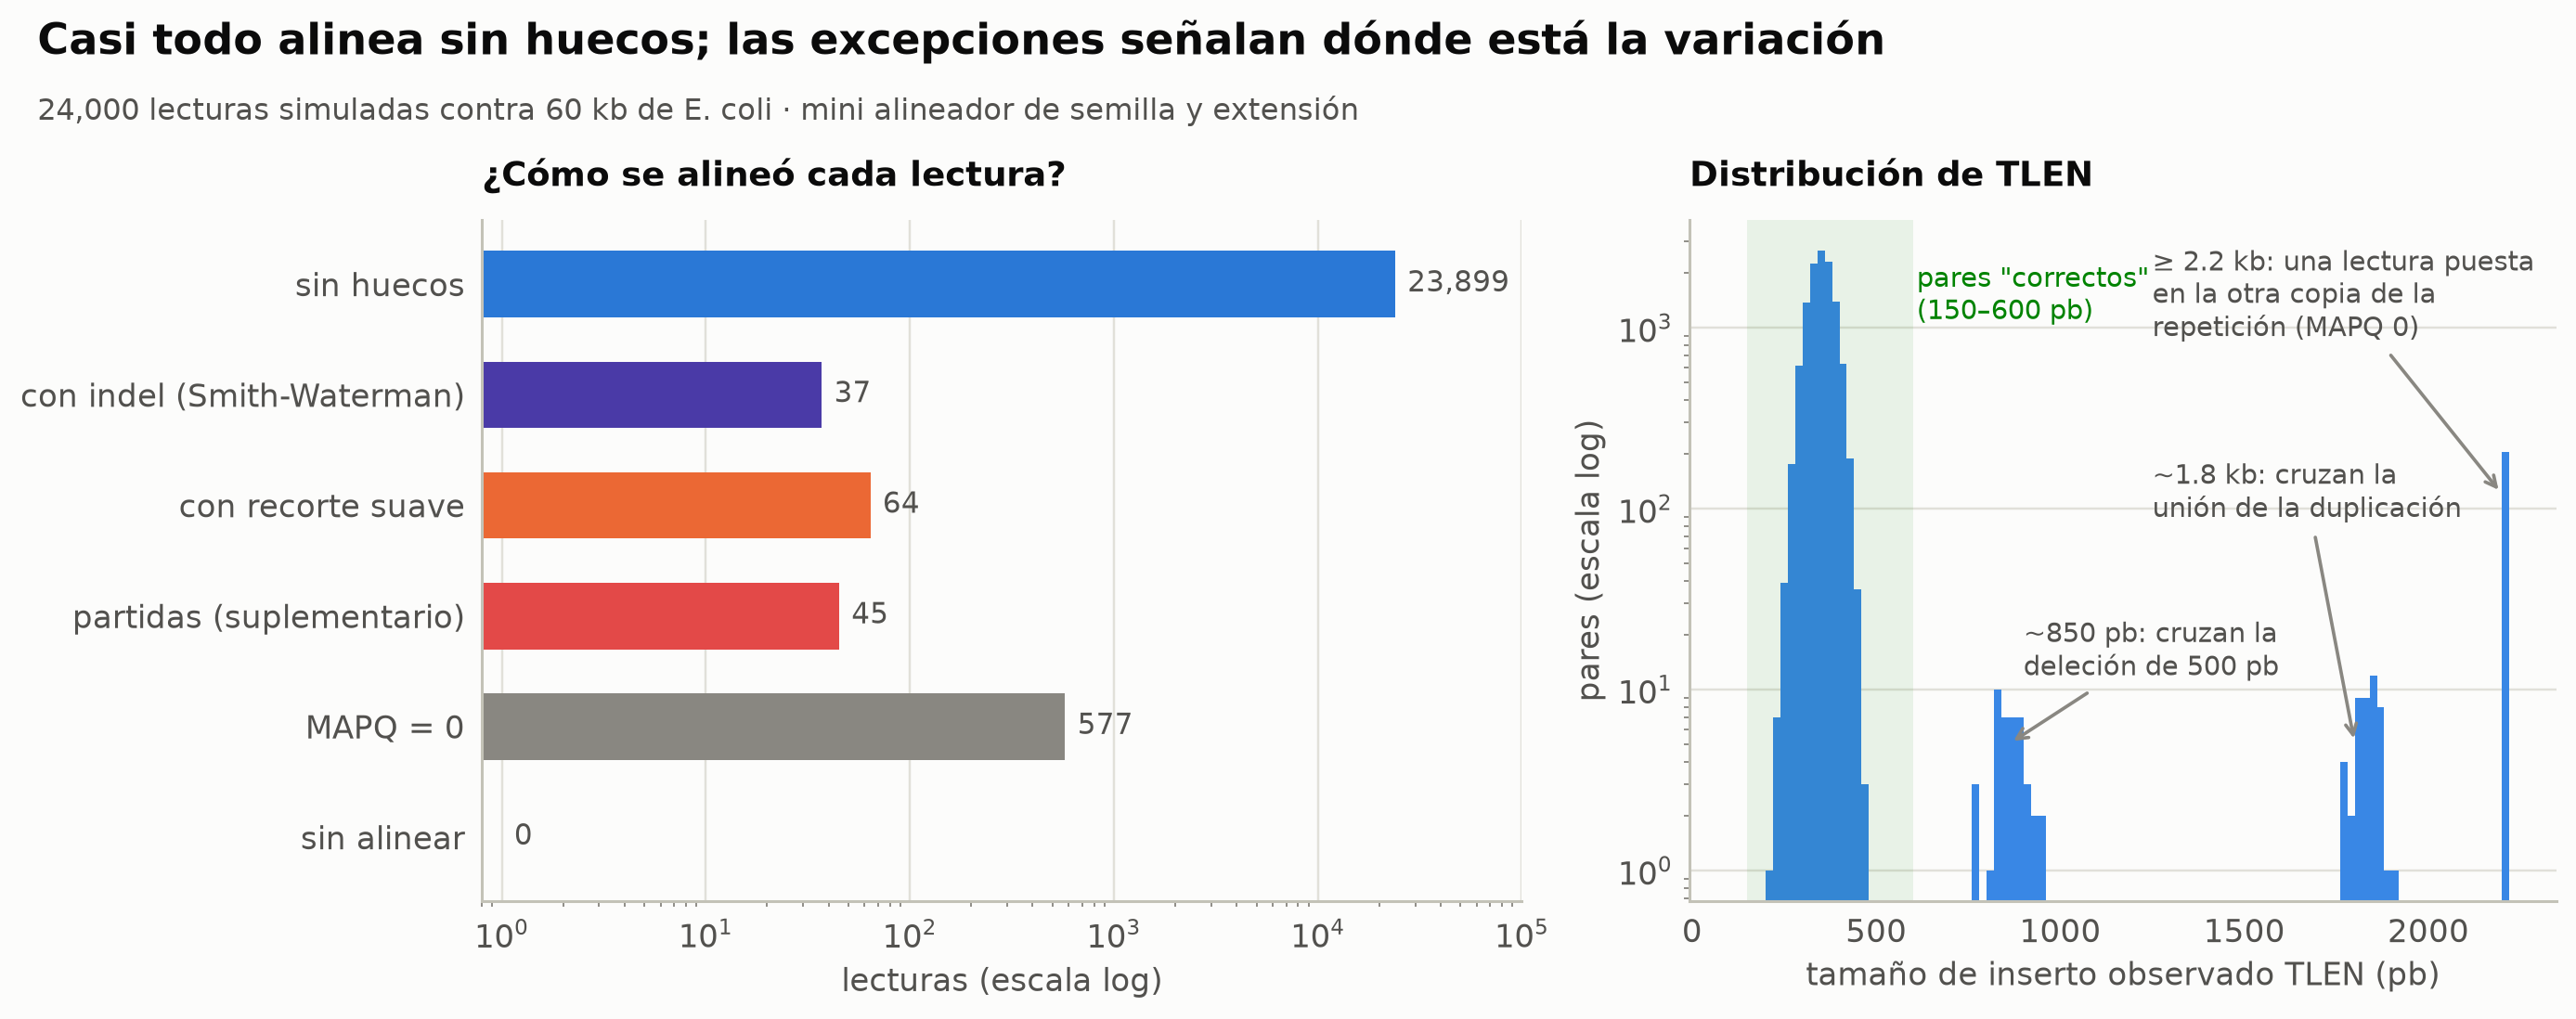

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw=dict(width_ratios=[1.2, 1]))
primary = aln[aln["mapped"] & ~aln["supp"]]
cats = {"sin huecos": path_counts["sin huecos"], "con indel (Smith-Waterman)": path_counts["con indel (Smith-Waterman)"],
        "con recorte suave": path_counts["con recorte suave"], "partidas (suplementario)": int(aln["supp"].sum()),
        "MAPQ = 0": int((primary["mapq"] == 0).sum()), "sin alinear": path_counts["sin alinear"]}
ax = axes[0]
y = np.arange(len(cats))[::-1]
ax.barh(y, list(cats.values()), color=[ec.BLUE, ec.VIOLET, ec.ORANGE, ec.RED, ec.MUTED, ec.INK_2], height=0.6)
ax.set_xscale("log"); ax.set_yticks(y, list(cats)); ax.set_xlim(0.8, 1e5)
for yi, v in zip(y, cats.values()):
    ax.text(max(v, 1) * 1.15, yi, f"{v:,}", va="center", fontsize=10, color=ec.INK_2)
ax.yaxis.grid(False); ax.xaxis.grid(True, color=ec.GRID); ax.set_xlabel("lecturas (escala log)")
ax.set_title("¿Cómo se alineó cada lectura?", loc="left", fontsize=12)
ax = axes[1]
tl = primary.loc[primary["tlen"] > 0, "tlen"]
ax.hist(tl.clip(upper=2200), bins=np.arange(100, 2250, 20), color=ec.SEQ_BLUE[6])
ax.set_yscale("log"); ax.set_xlabel("tamaño de inserto observado TLEN (pb)"); ax.set_ylabel("pares (escala log)")
ax.axvspan(150, 600, color=ec.GREEN, alpha=0.08)
ax.text(610, 1500, "pares \"correctos\"\n(150–600 pb)", ha="left", va="center", fontsize=9.5, color=ec.GREEN)
ax.annotate("≥ 2.2 kb: una lectura puesta\nen la otra copia de la\nrepetición (MAPQ 0)", (2200, 120), xytext=(1250, 900),
            fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="->", color=ec.MUTED, lw=1.2))
ax.annotate("~850 pb: cruzan la\ndeleción de 500 pb", (860, 5), xytext=(900, 12), fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="->", color=ec.MUTED, lw=1.2))
ax.annotate("~1.8 kb: cruzan la\nunión de la duplicación", (1800, 5), xytext=(1250, 90), fontsize=9.5,
            color=ec.INK_2, arrowprops=dict(arrowstyle="->", color=ec.MUTED, lw=1.2))
ax.set_title("Distribución de TLEN", loc="left", fontsize=12)
ec.fig_title(fig, "Casi todo alinea sin huecos; las excepciones señalan dónde está la variación",
             f"{2 * N_PAIRS:,} lecturas simuladas contra {REF_LEN // 1000} kb de E. coli · mini alineador de semilla y extensión")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, las "excepciones" suman apenas un par de cientos de lecturas entre 18 000,
> pero son las que llevan casi toda la información interesante: indels, puntos de ruptura y repeticiones. A la
> derecha, el tamaño de inserto forma una campana alrededor de 350 pb (los pares correctos, en verde) y hay tres
> grupos que se van lejos. Los de ~850 pb y ~1.8 kb no son ruido: los usaremos en la sección 8 para **medir** la
> deleción grande y **descubrir** la duplicación. La barra de la derecha (todo lo que supera 2.2 kb, unos 11.5 kb en
> realidad) son pares en los que una lectura cayó dentro de la repetición y el alineador, al no poder elegir, la puso
> **en la otra copia**: un par "anómalo" que no indica ninguna variante, sólo ambigüedad.

> 🤔 **Antes de seguir, prediga:** ¿qué valor de MAPQ tendrán las lecturas que caen **enteras** dentro de la
> repetición de 740 pb? ¿Y las que caen **a medias**, con una parte dentro y otra fuera?

### ¿Y con un alineador de verdad? (opcional)

Nuestro alineador es de juguete. Si en su entorno está **minimap2** (Li, 2018), la celda siguiente alinea las mismas
lecturas con su modo para lecturas cortas (`-ax sr`) y compara posiciones. En Colab se instala con `apt-get`; si no
está disponible, la celda sólo avisa y la clase continúa con nuestro BAM.

In [9]:
if shutil.which("minimap2") is None and IN_COLAB:
    !apt-get -qq install -y minimap2 > /dev/null
if shutil.which("minimap2") and pysam is not None:
    with open("r1.fq", "w") as f1, open("r2.fq", "w") as f2:
        for name, r1, q1, r2, q2 in pairs:
            f1.write(f"@{name}\n{r1}\n+\n{''.join(chr(int(x) + 33) for x in q1)}\n")
            f2.write(f"@{name}\n{r2}\n+\n{''.join(chr(int(x) + 33) for x in q2)}\n")
    with open("mm2.sam", "w") as out:
        subprocess.run(["minimap2", "-ax", "sr", "-t", "2", "ecoli_260kb.fa", "r1.fq", "r2.fq"],
                       stdout=out, stderr=subprocess.DEVNULL, check=True)
    ours = {(r.qname, r.read1): (r.pos, r.mapq) for r in aln[aln["mapped"] & ~aln["supp"]].itertuples()}
    same = diff = 0; mq0 = 0
    for a in pysam.AlignmentFile("mm2.sam"):
        if a.is_unmapped or a.is_secondary or a.is_supplementary:
            continue
        o = ours.get((a.query_name, a.is_read1))
        mq0 += a.mapping_quality == 0
        if o is not None:
            same += abs(o[0] - a.reference_start) <= 5
            diff += abs(o[0] - a.reference_start) > 5
    print(f"minimap2 coincide con nuestro alineador en {same:,} lecturas y difiere en {diff:,} "
          f"(casi todas dentro de la repetición, donde ambos eligen al azar) · MAPQ 0 en minimap2: {mq0:,}")
else:
    print("minimap2 no está disponible aquí: seguimos con el BAM de nuestro mini alineador.")

minimap2 coincide con nuestro alineador en 23,717 lecturas y difiere en 283 (casi todas dentro de la repetición, donde ambos eligen al azar) · MAPQ 0 en minimap2: 342


## 4. El pileup, columna por columna

### Ejemplo a mano

Tomemos una referencia de juguete de 13 pb (posiciones 101 a 113) y ocho lecturas ya alineadas. Nos interesa la
columna **105**, donde la referencia tiene una **T**. Para cada lectura anotamos qué "dice" en esa columna, con el
código que usa `samtools mpileup`:

| Símbolo | Significado |
|---|---|
| `.` / `,` | coincide con la referencia, en una lectura de hebra + / hebra − |
| `ACGT` / `acgt` | base distinta de la referencia (mayúscula: hebra +; minúscula: hebra −) |
| `^` + carácter | **aquí empieza** la lectura; el carácter codifica su MAPQ como ASCII $\text{MAPQ} + 33$ (`]` = 60) |
| `$` | **aquí termina** la lectura |
| `+2GG` | tras esta base, la lectura tiene una **inserción** de 2 bases, `GG` |
| `-1T` | tras esta base, a la lectura le **falta** 1 base de la referencia (una T) |
| `*` | esta posición está **borrada** en la lectura (es la base que faltaba) |

La línea completa de la columna 105 queda así (las lecturas se listan en el orden en que empiezan):

```
posición  ref  profundidad  bases                     calidades
105       T    8            .C.$c.+2GGC*^],           IIIIIIII
```

**Contemos a mano.** Hay 8 lecturas encima (la deleción `*` también cuenta en la profundidad de `mpileup`). Dicen
**T** (`.` o `,`): 4; dicen **C**: 3 (`C`, `c`, `C`); borrada: 1. La inserción `+2GG` no ocupa la columna 105: se
anota en la lectura que la lleva, que en la columna 105 sí coincide con la referencia. Así, la **frecuencia** de la
C es $3/8 = 0.375$ si contamos la deleción en el denominador, o $3/7 \approx 0.43$ si sólo contamos bases.

In [10]:
TOY_REF, TOY_START = "ACGTTAGCATGCA", 101
toy_reads = pd.DataFrame([                    # pos en base 0 dentro de la referencia de juguete
    dict(pos=0, strand="+", seq="ACGTTAG", cigar=[("M", 7)]),
    dict(pos=0, strand="+", seq="ACGTCA", cigar=[("M", 6)]),
    dict(pos=1, strand="+", seq="CGTT", cigar=[("M", 4)]),
    dict(pos=2, strand="-", seq="GTCAGCA", cigar=[("M", 7)]),
    dict(pos=2, strand="+", seq="GTTGGAGC", cigar=[("M", 3), ("I", 2), ("M", 3)]),
    dict(pos=3, strand="+", seq="TCAGC", cigar=[("M", 5)]),
    dict(pos=3, strand="-", seq="TAGCA", cigar=[("M", 1), ("D", 1), ("M", 4)]),
    dict(pos=4, strand="-", seq="TAGCAT", cigar=[("M", 6)]),
])
toy_reads["mapq"] = 60
toy_reads["end"] = [p + ref_span(c) for p, c in zip(toy_reads["pos"], toy_reads["cigar"])]

def column_code(r, p, refseq):
    """Símbolo de `samtools mpileup` que la lectura r aporta a la posición p (0-based), o None."""
    if not (r.pos <= p < r.end):
        return None
    fwd = r.strand == "+"
    code = f"^{chr(min(r.mapq, 93) + 33)}" if p == r.pos else ""
    i, j = 0, r.pos
    for k, (o, l) in enumerate(r.cigar):
        if o == "S":
            i += l
        elif o == "I":
            i += l
        elif o == "D":
            if j <= p < j + l:
                code += "*"
                break
            j += l
        elif o == "M":
            if j <= p < j + l:
                b = r.seq[i + p - j]
                code += ("." if fwd else ",") if b == refseq[p] else (b if fwd else b.lower())
                if p == j + l - 1 and k + 1 < len(r.cigar) and r.cigar[k + 1][0] in "ID":
                    no, nl = r.cigar[k + 1]
                    extra = r.seq[i + l:i + l + nl] if no == "I" else refseq[j + l:j + l + nl]
                    code += ("+" if no == "I" else "-") + str(nl) + (extra if fwd else extra.lower())
                break
            i += l; j += l
    return code + ("$" if p == r.end - 1 else "")

def mpileup_line(reads, p, refseq):
    """Línea de mpileup (sin calidades) para la posición p: (profundidad, cadena de bases)."""
    codes = [c for r in reads.sort_values("pos", kind="stable").itertuples()
             if (c := column_code(r, p, refseq)) is not None]
    return len(codes), "".join(codes)

print("posición  ref  prof.  bases")
for p in range(2, 7):
    d, s = mpileup_line(toy_reads, p, TOY_REF)
    print(f"{TOY_START + p:>8}  {TOY_REF[p]:>3}  {d:>5}  {s}")

posición  ref  prof.  bases
     103    G      5  ...^],^].
     104    T      7  ...,.^].^],-1t
     105    T      8  .C.$c.+2GGC*^],
     106    A      7  ..$,..,,
     107    G      6  .$,..,,


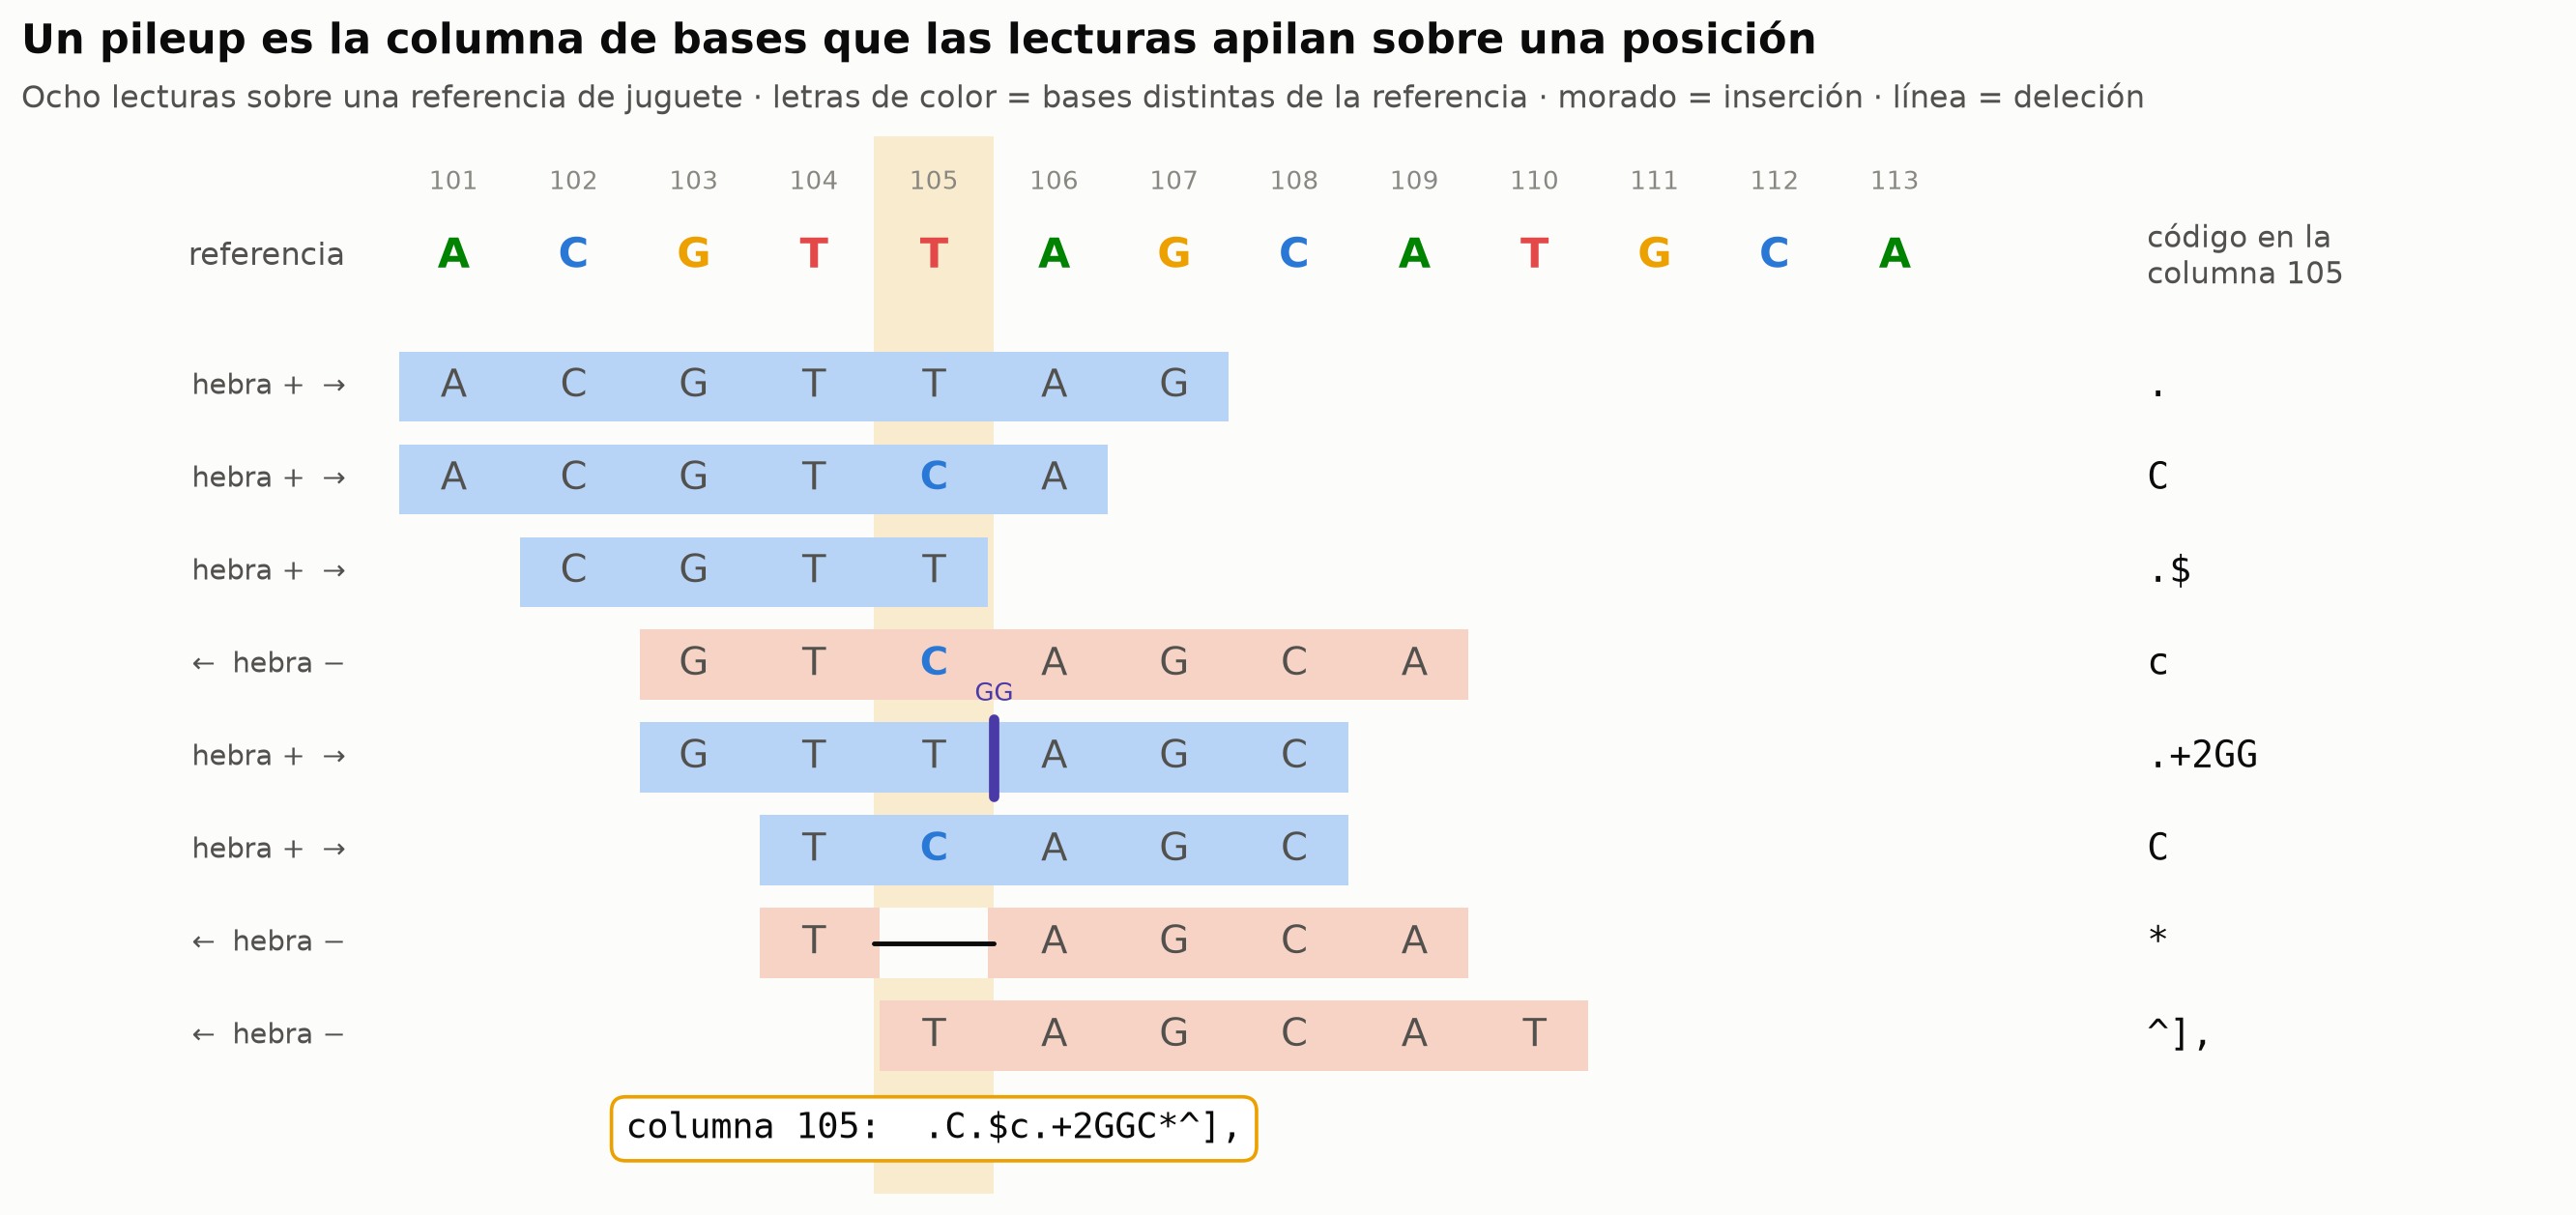

In [11]:
COL = 4
fig, ax = plt.subplots(figsize=(12, 5.6))
ax.axvspan(COL - 0.5, COL + 0.5, color=ec.YELLOW, alpha=0.18, lw=0)
for x, b in enumerate(TOY_REF):
    ax.text(x, -1.2, b, ha="center", va="center", fontsize=14, fontweight="bold", color=ec.NUC_COLORS[b])
    ax.text(x, -2.0, TOY_START + x, ha="center", va="center", fontsize=8.5, color=ec.MUTED)
ax.text(-0.9, -1.2, "referencia", ha="right", va="center", fontsize=10.5, color=ec.INK_2)
for row, r in enumerate(toy_reads.itertuples()):
    y = row + 0.2
    tone = ec.SEQ_BLUE[1] if r.strand == "+" else "#f6d3c4"
    ax.add_patch(Rectangle((r.pos - 0.45, y - 0.38), r.end - r.pos - 0.1, 0.76, fc=tone, lw=0))
    i, j = 0, r.pos
    for o, l in r.cigar:
        if o == "M":
            for t in range(l):
                b = r.seq[i + t]
                mism = b != TOY_REF[j + t]
                ax.text(j + t, y, b, ha="center", va="center", fontsize=13,
                        fontweight="bold" if mism else "normal",
                        color=ec.NUC_COLORS[b] if mism else ec.INK_2)
            i += l; j += l
        elif o == "I":
            ax.plot([j - 0.5, j - 0.5], [y - 0.42, y + 0.42], color=ec.VIOLET, lw=3.5)
            ax.text(j - 0.5, y - 0.55, r.seq[i:i + l], ha="center", va="bottom", fontsize=8.5, color=ec.VIOLET)
            i += l
        elif o == "D":
            ax.add_patch(Rectangle((j - 0.45, y - 0.38), l - 0.1, 0.76, fc=ec.SURFACE, lw=0))
            ax.plot([j - 0.5, j + l - 0.5], [y, y], color=ec.INK, lw=1.6)
            j += l
    ax.text(-0.9, y, "hebra +  →" if r.strand == "+" else "←  hebra −", ha="right", va="center", fontsize=9.5,
            color=ec.INK_2)
    ax.text(14.1, y, column_code(r, COL, TOY_REF), ha="left", va="center", fontsize=12.5, family="monospace",
            color=ec.INK)
ax.text(14.1, -1.2, "código en la\ncolumna 105", ha="left", va="center", fontsize=10, color=ec.INK_2)
d, s = mpileup_line(toy_reads, COL, TOY_REF)
ax.text(COL, len(toy_reads) + 0.2, f"columna 105:  {s}", ha="center", va="center", fontsize=12, family="monospace",
        color=ec.INK, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=ec.YELLOW, lw=1.2))
ax.set_xlim(-3.6, 17.5); ax.set_ylim(len(toy_reads) + 0.9, -2.5); ax.axis("off")
ec.title(ax, "Un pileup es la columna de bases que las lecturas apilan sobre una posición",
         "Ocho lecturas sobre una referencia de juguete · letras de color = bases distintas de la referencia · "
         "morado = inserción · línea = deleción")
plt.show()

> 🔎 **Qué observamos.** Cada fila es una lectura; la columna amarilla es la posición 105. A la derecha, el código
> que esa lectura aporta a la línea de `mpileup`. Leer esta línea de corrido (`.C.$c.+2GGC*^],`) parece críptico,
> pero con la tabla de símbolos se "ve" la columna entera: tres lecturas con C (una de ellas en hebra −), una que
> termina (`$`), una que empieza (`^]`), una con una inserción justo después y una con la base borrada.

✅ **Compruebe su comprensión.** Escriba a mano el código de la columna **104** (la G) y compruebe con la salida
de la celda anterior. (Pista: la lectura con la deleción aporta `,-1t` en la 104: coincide con la referencia en
hebra − y le falta la base siguiente, que en minúscula es `t`.)

### El pileup del experimento completo

Para todo el BAM guardamos el pileup como una **matriz de conteos**: una fila por posición, una columna por alelo
(A, C, G, T y deleción) y una "capa" por hebra. Cada lectura suma 1 en las celdas que cubre: recorremos su CIGAR y
en cada bloque `M` sumamos de golpe todas sus bases (NumPy lo hace sin bucle interno). Las inserciones, que no
ocupan columnas de la referencia, se guardan aparte, asociadas a la base anterior.

Seguimos las reglas de `samtools`: se descartan las lecturas sin alinear, secundarias, que fallan controles de
calidad o marcadas como duplicados; las suplementarias **sí** cuentan.

In [12]:
ALLELES = ["A", "C", "G", "T", "del"]
LUT = np.full(256, 0, dtype=np.int64)
for k, b in enumerate("ACGT"):
    LUT[ord(b)] = k

def build_pileup(reads, length=REF_LEN):
    """Conteos (2 hebras × posiciones × 5 alelos) e inserciones {pos_base_anterior: Counter}."""
    counts = np.zeros((2, length, 5), dtype=np.int32)
    ins = collections.defaultdict(collections.Counter)
    for r in reads.itertuples():
        s = 0 if r.strand == "+" else 1
        q = np.frombuffer(r.seq.encode(), np.uint8)
        i, j = 0, r.pos
        for o, l in r.cigar:
            if o == "M":
                counts[s, np.arange(j, j + l), LUT[q[i:i + l]]] += 1
                i += l; j += l
            elif o == "I":
                ins[j - 1][r.seq[i:i + l]] += 1; i += l
            elif o == "D":
                counts[s, j:j + l, 4] += 1; j += l
            elif o == "S":
                i += l
    return counts, ins

t0 = time.perf_counter()
mapped = aln[aln["mapped"]].copy()
counts_s, ins_at = build_pileup(mapped)
counts = counts_s.sum(0)                            # ambas hebras
depth = counts[:, :4].sum(1)                        # como `samtools depth`: sin contar deleciones
print(f"Pileup de {len(mapped):,} alineamientos en {time.perf_counter() - t0:.2f} s · "
      f"profundidad media {depth.mean():.1f}× · mediana {np.median(depth):.0f}×")

if pysam is not None:                               # verificación independiente con htslib
    with pysam.AlignmentFile(BAM) as bam:
        cc = np.array(bam.count_coverage(CONTIG, 0, REF_LEN, quality_threshold=0, read_callback="all")).T
    print("¿Coincide con pysam.count_coverage?", np.array_equal(cc, counts[:, :4]))
pd.DataFrame(counts[SNP1 - 2:SNP1 + 3], columns=ALLELES,
             index=pd.Index(range(SNP1 - 1, SNP1 + 4), name="posición (1-based)")).assign(ref=list(ref[SNP1 - 2:SNP1 + 3]))

Pileup de 24,045 alineamientos en 0.13 s · profundidad media 40.0× · mediana 39×
¿Coincide con pysam.count_coverage? True


,A,C,G,T,del,ref
posición (1-based),,,,,,
7999,0,0,35,0,0,G
8000,0,0,35,0,0,G
8001,35,0,0,0,0,G
8002,0,0,0,34,0,T
8003,0,34,0,0,0,C


Y ahora, la prueba de fuego: nuestra función `mpileup_line` frente a `samtools mpileup` (vía pysam) en las
posiciones de las variantes pequeñas. Para comparar manzanas con manzanas desactivamos los filtros que `mpileup`
aplica por defecto: `-B` (sin recalibrar calidades por alineamiento, BAQ), `-Q 0` y `-q 0` (sin umbral de calidad
de base ni de mapeo) y `-A` (incluir pares "anómalos").

In [13]:
def samtools_line(p):
    out = pysam.mpileup("-B", "-Q", "0", "-q", "0", "-A", "-d", "100000", "-f", "ecoli_260kb.fa",
                        "-r", f"{CONTIG}:{p + 1}-{p + 1}", BAM)
    return out.split("\t")

rows = []
for label, p in [("SNP 1", SNP1), ("SNP 2", SNP2), ("antes de la inserción", INS_POS), ("antes de la deleción", DEL3[0] - 1)]:
    d, s = mpileup_line(mapped, p, ref)
    row = dict(evento=label, posición=p + 1, ref=ref[p], profundidad=d, bases=s)
    if pysam is not None:
        f = samtools_line(p)
        row["¿igual a samtools?"] = (int(f[3]) == d) and (sorted(f[4]) == sorted(s))
    rows.append(row)
with pd.option_context("display.max_colwidth", 70):
    display(pd.DataFrame(rows))

,evento,posición,ref,profundidad,bases,¿igual a samtools?
0,SNP 1,8001,G,35,A$aAAAaAaaaAAAAaAaAaAaaaaAAAaaAaAAa^]A,True
1,SNP 2,8092,A,40,".g.gG...,gGg,.g,.,gg.ggg,.GGgGG.G,.G.G.,",True
2,antes de la inserción,8121,G,37,",.,,$,+4atta.,+4atta,+4atta,+4atta,..+4ATTA.+4ATTA,+4atta.+4ATTA.+...",True
3,antes de la deleción,8180,G,33,"..,$,$.-3TAT,-3tat,-3tat.-3TAT.-3TAT,-3tat.-3TAT.-3TAT.-3TAT.-3TAT...",True


> 🔎 **Qué observamos.** En el SNP 1 casi toda la columna es `A`/`a` (la base alternativa, en ambas hebras): una
> variante **homocigota**. En el SNP 2 la mitad de los símbolos son `.`/`,` y la otra mitad `T`/`t`: una
> **heterocigota**. Antes de la inserción aparecen símbolos `+4ATTA`/`+4atta` en aproximadamente la mitad de las
> lecturas, y antes de la deleción `-3TAT`/`-3tat` en casi todas (algunas lecturas que la tocan justo en su extremo
> la "resuelven" como desajustes o recortes, un detalle realista). Nuestra función produce los mismos símbolos que
> `samtools` (comparamos los caracteres sin importar el orden, porque el orden de las lecturas que empiezan en la
> misma posición puede diferir).

## 5. Apilar lecturas sin que se tapen: el algoritmo de empaquetado

Para dibujar las lecturas hay que decidir **en qué fila** va cada una. Una fila por lectura sería absurdo: a 40× una
ventana de 600 pb tiene casi 300 lecturas, y la pantalla se llenaría de filas casi vacías. IGV las **empaqueta**:
coloca varias lecturas en la misma fila siempre que no se toquen, como quien ordena libros de distintos anchos en
estantes, llenando primero el estante de arriba.

El algoritmo es **voraz** (*greedy*) y cabe en tres líneas:

1. Ordenar las lecturas por su posición de inicio.
2. Para cada lectura, recorrer las filas de arriba abajo y ponerla en la **primera fila cuyo último ocupante
   terminó antes** de que ella empiece (más un pequeño margen, para que se distingan).
3. Si ninguna fila está libre, abrir una fila nueva debajo.

Basta recordar, para cada fila, **dónde termina** su última lectura (un arreglo `row_end`).

### Ejemplo a mano

Seis lecturas (inicio, fin), ya ordenadas por inicio, con margen 0:

| Lectura | Intervalo | `row_end` antes | ¿Dónde va? | `row_end` después |
|---|---|---|---|---|
| a | [0, 40) | [ ] | no hay filas: fila 0 | [40] |
| b | [10, 50) | [40] | fila 0 ocupada (40 > 10): fila 1 | [40, 50] |
| c | [20, 60) | [40, 50] | ocupadas: fila 2 | [40, 50, 60] |
| d | [45, 85) | [40, 50, 60] | fila 0 libre (40 ≤ 45) | [85, 50, 60] |
| e | [55, 95) | [85, 50, 60] | fila 0 no; fila 1 sí (50 ≤ 55) | [85, 95, 60] |
| f | [90, 130) | [85, 95, 60] | fila 0 libre (85 ≤ 90) | [130, 95, 60] |

Resultado: **3 filas**. Y no se puede hacer con menos: entre las posiciones 20 y 40 hay **tres lecturas a la vez**
(a, b y c), que necesariamente van en filas distintas.

### ¿Por qué el voraz es óptimo?

Sea $D_{\max}$ la profundidad máxima de la ventana (el máximo número de lecturas que se solapan en algún punto).
Ningún dibujo puede usar menos de $D_{\max}$ filas. Y el voraz nunca usa más: sólo abre la fila número $r+1$ cuando
las $r$ filas existentes están **todas ocupadas** en el punto donde empieza la lectura nueva, es decir, cuando en ese
punto ya hay $r$ lecturas más la nueva. Por tanto:

$$
\boxed{\;\text{filas del empaquetado voraz} \;=\; D_{\max} \;=\; \max_{x}\ \#\{\text{lecturas que cubren } x\}\;}
$$

| Símbolo | Significado |
|---|---|
| $D_{\max}$ | profundidad máxima en la ventana (contando el margen entre lecturas como parte de cada una) |
| `row_end[r]` | posición donde termina la última lectura de la fila $r$ |

Es el clásico problema de **coloreo de un grafo de intervalos**, que tiene solución exacta y rápida. Con un montículo
(*heap*) de finales, el costo es $O(n \log D_{\max})$; la versión sencilla, que recorre las filas, cuesta
$O(n \cdot D_{\max})$, de sobra para una ventana de visualización.

In [14]:
def pack_rows(starts, ends, gap=0):
    """Empaquetado voraz: fila de cada intervalo [start, end) en la primera fila libre."""
    starts, ends = np.asarray(starts), np.asarray(ends)
    rows = np.full(len(starts), -1)
    row_end = []
    for i in np.lexsort((ends, starts)):             # ordenar por inicio
        for r, e in enumerate(row_end):
            if e + gap <= starts[i]:
                rows[i], row_end[r] = r, ends[i]
                break
        else:
            rows[i] = len(row_end)
            row_end.append(ends[i])
    return rows

def max_depth(starts, ends, gap=0):
    """Máximo número de intervalos [start, end + gap) que se solapan."""
    ev = sorted([(s, 1) for s in starts] + [(e + gap, -1) for e in ends], key=lambda t: (t[0], t[1]))
    return max(np.cumsum([d for _, d in ev]))

hand = dict(a=(0, 40), b=(10, 50), c=(20, 60), d=(45, 85), e=(55, 95), f=(90, 130))
hand_rows = pack_rows([v[0] for v in hand.values()], [v[1] for v in hand.values()])
print("filas:", dict(zip(hand, hand_rows)), "· D_max =", max_depth([v[0] for v in hand.values()], [v[1] for v in hand.values()]))

filas: {'a': np.int64(0), 'b': np.int64(1), 'c': np.int64(2), 'd': np.int64(0), 'e': np.int64(1), 'f': np.int64(0)} · D_max = 3


Veamos el algoritmo en acción con 16 lecturas de longitudes distintas. En cada paso aparece arriba la lectura nueva
(en naranja) y una línea vertical marca dónde empieza; a la derecha, el arreglo `row_end` con cada fila en rojo si
está ocupada en ese punto o en verde si es la primera libre.

> 🤔 **Antes de ejecutar, prediga:** ¿cuántas filas hará falta abrir? Mire la línea de profundidad del final y
> busque su máximo.

![Empaquetado voraz: cada lectura nueva va a la primera fila cuyo último ocupante ya terminó; el número de filas final coincide con la profundidad máxima](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.3_empaquetado.gif)

*Empaquetado voraz: cada lectura nueva va a la primera fila cuyo último ocupante ya terminó; el número de filas final coincide con la profundidad máxima*

In [15]:
rng_toy = np.random.default_rng(7)
N_TOY = 16
toy_s = np.sort(rng_toy.integers(0, 260, N_TOY))
toy_e = toy_s + rng_toy.integers(35, 95, N_TOY)
GAP = 4
order_t = np.argsort(toy_s, kind="stable")
toy_rows = pack_rows(toy_s, toy_e, gap=GAP)
n_rows_t = toy_rows.max() + 1
depth_t = np.zeros(toy_e.max() + GAP + 1, int)
for s, e in zip(toy_s, toy_e):
    depth_t[s:e + GAP] += 1

fig = plt.figure(figsize=(12, 6.2))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.87))
gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1], hspace=0.05)
ax, axd = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
X_MAX = 475
ax.set_xlim(-5, X_MAX); ax.set_ylim(n_rows_t + 0.2, -2.3); ax.axis("off")
axd.set_xlim(-5, X_MAX); axd.set_ylim(0, depth_t.max() + 1.5)
axd.set_xticks(range(0, 360, 50)); axd.set_ylabel("profundidad"); axd.set_xlabel("posición (pb)")
axd.spines["bottom"].set_bounds(0, 360)
ax.text(-3, -1.5, "lectura nueva", fontsize=10, color=ec.INK_2, va="center")
for r in range(n_rows_t):
    ax.text(-3, r, f"fila {r}", fontsize=9.5, color=ec.MUTED, va="center", ha="right")
fig.text(0.01, 0.975, "El empaquetado voraz coloca cada lectura en la primera fila libre",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.93, f"{N_TOY} lecturas ordenadas por inicio · margen mínimo de {GAP} pb entre lecturas de una fila · "
         "abajo: profundidad (contando el margen)", fontsize=10.5, color=ec.INK_2, va="top")
placed = []
dyn = []

def update(f):
    global dyn
    for a in dyn:
        a.remove()
    dyn = []
    k, phase = divmod(f, 2)
    if k >= N_TOY:
        k, phase = N_TOY - 1, 1
    i = order_t[k]
    # filas ocupadas hasta ahora (antes de colocar i)
    row_end = {}
    for j in order_t[:k]:
        row_end[toy_rows[j]] = max(row_end.get(toy_rows[j], -1), toy_e[j])
    for j in order_t[:k + (phase == 1)]:
        dyn.append(ax.add_patch(Rectangle((toy_s[j], toy_rows[j] - 0.35), toy_e[j] - toy_s[j], 0.7,
                                          fc=ec.ORANGE if (j == i and phase == 1) else ec.SEQ_BLUE[3], lw=0)))
    if phase == 0:
        dyn.append(ax.add_patch(Rectangle((toy_s[i], -1.85), toy_e[i] - toy_s[i], 0.7, fc=ec.ORANGE, lw=0)))
    dyn.append(ax.axvline(toy_s[i], color=ec.INK, lw=1, ls=":"))
    dyn.append(axd.axvline(toy_s[i], color=ec.INK, lw=1, ls=":"))
    for r in range(n_rows_t):
        if r in row_end:
            free = row_end[r] + GAP <= toy_s[i]
            first_free = free and all(row_end[q] + GAP > toy_s[i] for q in range(r))
            col = ec.GREEN if (first_free and r == toy_rows[i]) else (ec.RED if not free else ec.MUTED)
            txt = f"fila {r}: ocupada hasta {row_end[r]}" + ("  ✗" if not free else ("  ✓" if col == ec.GREEN else ""))
        elif r == toy_rows[i]:
            col, txt = ec.GREEN, f"fila {r}: nueva  ✓"
        else:
            continue
        dyn.append(ax.text(370, r, txt, fontsize=9.5, color=col, va="center",
                           fontweight="bold" if col != ec.MUTED else "normal"))
    dyn.append(ax.text(370, -1.5, f"lectura {k + 1}/{N_TOY}: [{toy_s[i]}, {toy_e[i]})", fontsize=10,
                       color=ec.INK, va="center"))
    d = np.zeros_like(depth_t)
    for j in order_t[:k + 1]:
        d[toy_s[j]:toy_e[j] + GAP] += 1
    dyn.append(axd.fill_between(np.arange(len(d)), d, step="post", color=ec.SEQ_BLUE[5], lw=0))
    if f >= 2 * N_TOY - 1:
        xm = int(np.argmax(depth_t))
        dyn.append(axd.annotate(f"D_max = {depth_t.max()} = filas usadas", (xm, depth_t.max()), xytext=(10, 6),
                                textcoords="offset points", fontsize=10.5, color=ec.INK, fontweight="bold"))
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=2 * N_TOY + 4, interval=450, name="7.3_empaquetado")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Mientras las lecturas no se solapan, todas caen en la fila 0. Cada vez que una lectura
> empieza donde todas las filas existentes siguen ocupadas (todas en rojo), se abre una fila nueva. Al final, el
> número de filas coincide con el máximo de la curva de profundidad, tal como garantiza el argumento anterior.

Con las lecturas reales el ahorro es enorme. Comparemos una fila por lectura con el empaquetado, en 600 pb alrededor
de los SNPs:

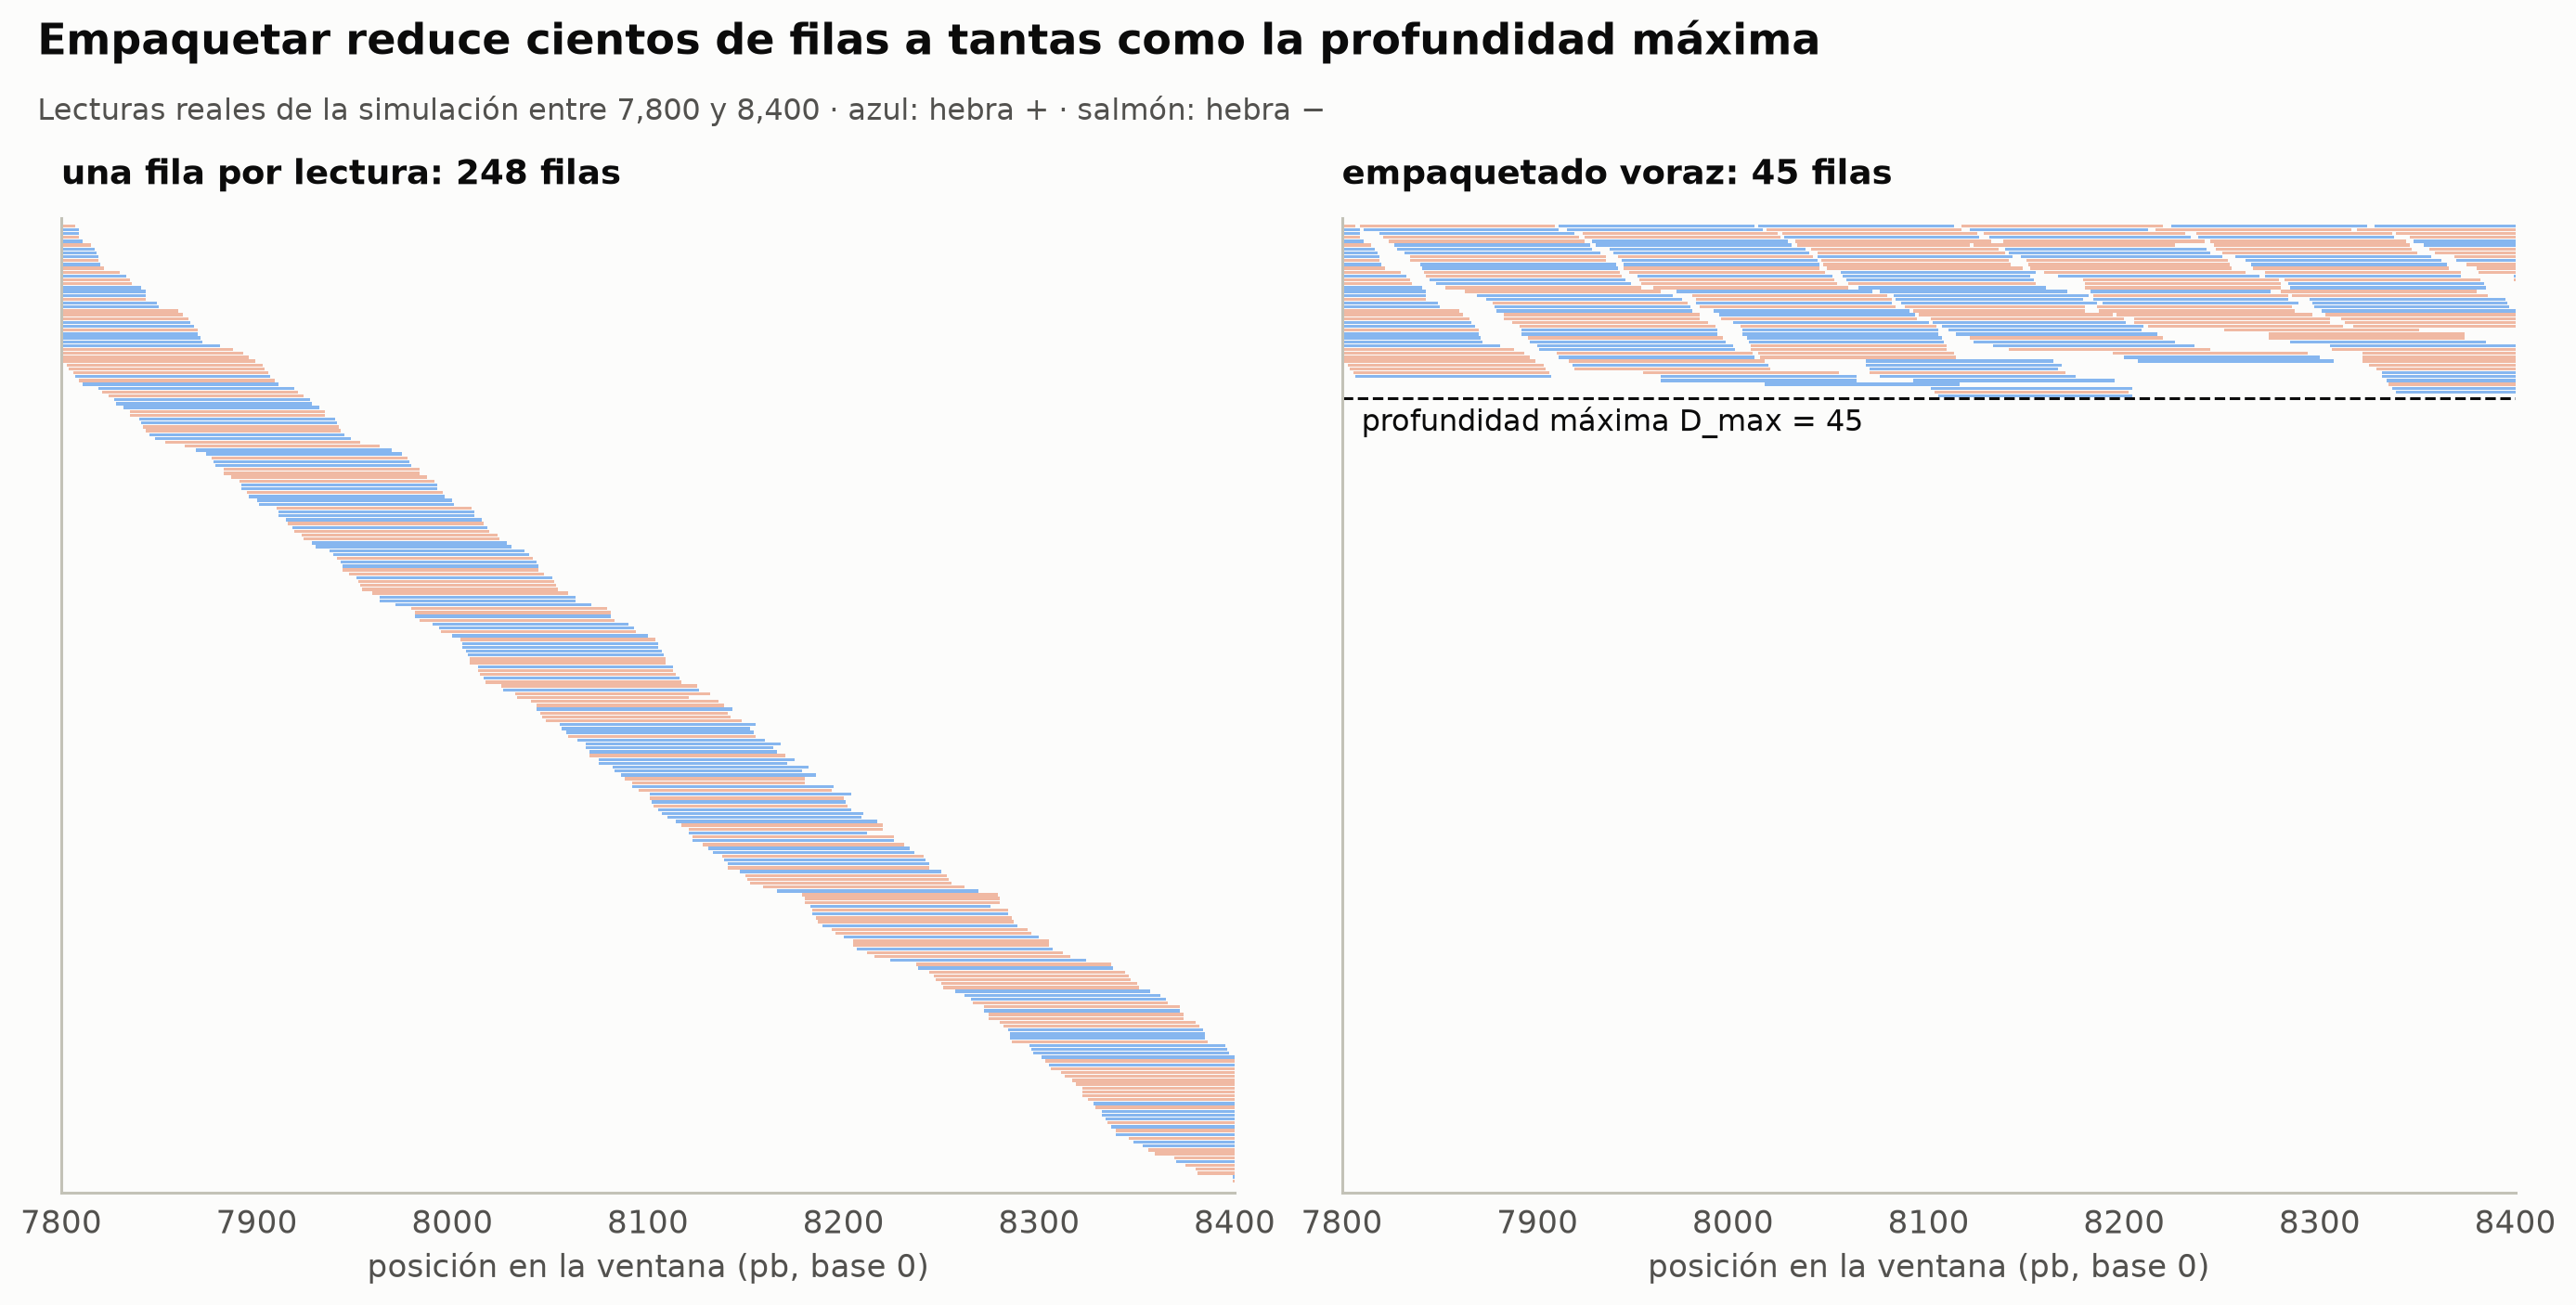

In [16]:
W0, W1 = 7_800, 8_400
win = mapped[(mapped["pos"] < W1) & (mapped["end"] > W0)].sort_values("pos")
rows_w = pack_rows(win["pos"], win["end"], gap=2)
dmax_w = max_depth(win["pos"].to_numpy(), win["end"].to_numpy(), gap=2)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)
for ax, rows, lab in [(axes[0], np.arange(len(win)), f"una fila por lectura: {len(win)} filas"),
                      (axes[1], rows_w, f"empaquetado voraz: {rows_w.max() + 1} filas")]:
    for (s, e, st), r in zip(win[["pos", "end", "strand"]].itertuples(index=False), rows):
        ax.add_patch(Rectangle((s, r - 0.4), e - s, 0.8, fc=ec.SEQ_BLUE[3] if st == "+" else "#f0b9a3", lw=0))
    ax.set_xlim(W0, W1); ax.set_ylim(len(win) + 2, -2)
    ax.set_title(lab, loc="left", fontsize=12); ax.set_xlabel("posición en la ventana (pb, base 0)")
    ax.grid(False); ax.set_yticks([])
axes[1].axhline(dmax_w - 0.5, color=ec.INK, lw=1, ls="--")
axes[1].text(W0 + 10, dmax_w + 8, f"profundidad máxima D_max = {dmax_w}", fontsize=10.5, color=ec.INK)
ec.fig_title(fig, "Empaquetar reduce cientos de filas a tantas como la profundidad máxima",
             f"Lecturas reales de la simulación entre {W0:,} y {W1:,} · azul: hebra + · salmón: hebra −")
plt.show()

> 🔎 **Qué observamos.** Las mismas lecturas caben en una fracción de la altura. El número de filas es exactamente
> $D_{\max}$ (con el margen de 2 pb incluido). Por eso, en IGV, la altura de la pila de lecturas "es" la cobertura
> local: cuando ve una pila que se estira hacia abajo, está viendo profundidad alta, y cuando se vacía, un hueco.
> Cuando la profundidad es de cientos o miles (paneles dirigidos, virus), IGV **submuestrea** (*downsampling*) y
> dibuja sólo una parte: la pista de cobertura, en cambio, siempre cuenta todo.

## 6. Una vista estilo IGV hecha a mano

Ya tenemos las piezas: la matriz de conteos del pileup (para la **pista de cobertura**), las filas del empaquetado
(para **apilar**) y el CIGAR de cada lectura (para dibujar lo que la separa de la referencia). Estas son las
convenciones visuales que imitaremos de IGV:

| Elemento | Cómo se dibuja | Qué significa |
|---|---|---|
| Pista de cobertura | barras grises; **barra de colores** si un alelo no referencia supera el 20 % | profundidad y posibles variantes |
| Lectura | rectángulo con **punta de flecha** hacia su dirección; tono azul (hebra +) o salmón (hebra −) | orientación |
| Base distinta de la referencia | cuadrito con el **color del nucleótido** (y la letra si hay espacio) | desajuste |
| Inserción | barra **morada** entre dos bases | bases de más en la lectura |
| Deleción | **línea negra** que atraviesa el hueco | bases que faltan en la lectura |
| Recorte suave | tic **rojo** en el extremo de la lectura | parte de la lectura que no alinea aquí |
| MAPQ = 0 | lectura **transparente**, sólo con contorno | posición ambigua (repetición) |
| Par anómalo | color del par: rojo (inserto grande), aqua (orientación RF), amarillo (mate lejano) | posible variante estructural |

Sólo se dibujan las bases **distintas** de la referencia: el ojo encuentra las variantes como columnas de color en
un mar gris. Es la misma idea que en IGV.

In [17]:
FWD_TONE, REV_TONE = "#bcd5f5", "#f5cbb9"
PAIR_COLORS = {"inserto grande": ec.RED, "orientación RF": ec.AQUA, "mate lejano": ec.YELLOW, "inserto pequeño": ec.BLUE}

def pair_class(r):
    """Clasifica el par como lo haría IGV al 'colorear por tamaño de inserto y orientación'."""
    if r.mpos < 0 or r.proper:
        return "normal"
    if abs(r.mpos - r.pos) > 5_000:
        return "mate lejano"
    fr = (r.pos <= r.mpos) if r.strand == "+" else (r.mpos <= r.pos)
    if r.strand == r.mstrand:
        return "misma hebra"
    if not fr:
        return "orientación RF"
    return "inserto grande" if abs(r.tlen) > 600 else ("inserto pequeño" if abs(r.tlen) < 150 else "normal")

mapped["pair"] = [pair_class(r) for r in mapped.itertuples()]

def draw_reference(ax, start, end):
    w = end - start
    if w > 400:                                        # demasiadas bases: una barra gris, como IGV alejado
        ax.add_patch(Rectangle((start, 0.25), w, 0.5, fc="#d9d8d2", lw=0))
        ax.text(start + w / 2, 0.5, "referencia (acerque el zoom para ver las bases)", ha="center", va="center",
                fontsize=8.5, color=ec.INK_2)
    for p in (range(start, end) if w <= 400 else []):
        b = ref[p]
        ax.add_patch(Rectangle((p, 0), 1, 1, fc=ec.NUC_COLORS[b], lw=0, alpha=0.9))
        if w <= 130:
            ax.text(p + 0.5, 0.5, b, ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    ax.set_xlim(start, end); ax.set_ylim(0, 1); ax.axis("off")

def draw_coverage(ax, start, end, af_min=0.2):
    x = np.arange(start, end)
    c = counts[start:end]
    d = c[:, :4].sum(1)
    ax.fill_between(np.r_[x, end], np.r_[d, d[-1]], step="post", color="#bdbcb4", lw=0)
    ref_idx = np.array(["ACGT".index(b) for b in ref[start:end]])
    alt_frac = 1 - c[np.arange(len(x)), ref_idx] / np.maximum(d, 1)
    for k in np.flatnonzero((alt_frac >= af_min) & (d >= 5)):
        bottom = 0
        for a in "ACGT":                               # barra apilada por alelo, como IGV
            n = c[k, "ACGT".index(a)]
            if n:
                ax.add_patch(Rectangle((x[k], bottom), 1, n, fc=ec.NUC_COLORS[a], lw=0))
                bottom += n
    ax.set_xlim(start, end); ax.set_ylim(0, max(d.max(), 1) * 1.55)
    ax.set_ylabel("cobertura", rotation=0, ha="right", va="center"); ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)

def draw_reads(ax, start, end, color_pairs=False, max_rows=45, gap=None):
    w = end - start
    gap = max(2, w // 250) if gap is None else gap
    sel = mapped[(mapped["pos"] < end) & (mapped["end"] > start)].sort_values(["pos", "end"])
    rows = pack_rows(sel["pos"], sel["end"], gap=gap)
    tip = max(0.8, w * 0.006)
    letters = w <= 130
    hidden = int((rows >= max_rows).sum())
    for r, row in zip(sel.itertuples(), rows):
        if row >= max_rows:
            continue
        kind = r.pair if color_pairs else "normal"
        fc = PAIR_COLORS.get(kind, FWD_TONE if r.strand == "+" else REV_TONE)
        faint = r.mapq == 0
        style = dict(fc=fc, alpha=0.22 if faint else (0.75 if kind in PAIR_COLORS else 1),
                     ec=ec.INK_2 if faint else "none", lw=0.5 if faint else 0)
        y0, h = row - 0.4, 0.8
        i, j = 0, r.pos
        for k, (o, l) in enumerate(r.cigar):
            if o == "M":
                ax.add_patch(Rectangle((j, y0), l, h, **style))
                q = np.frombuffer(r.seq[i:i + l].encode(), np.uint8)
                for t in np.flatnonzero(q != ref_bytes[j:j + l]):
                    b = r.seq[i + t]
                    if start <= j + t < end:
                        ax.add_patch(Rectangle((j + t, y0), 1, h, fc=ec.NUC_COLORS[b], lw=0,
                                               alpha=0.35 if faint else 1))
                        if letters:
                            ax.text(j + t + 0.5, row, b, ha="center", va="center", fontsize=6.5, color="white",
                                    fontweight="bold")
                i += l; j += l
            elif o == "D":
                ax.plot([j, j + l], [row, row], color=ec.INK, lw=1.0)
                j += l
            elif o == "I":
                ax.add_patch(Rectangle((j - max(0.3, w * 0.0015), y0 - 0.05), 2 * max(0.3, w * 0.0015), h + 0.1,
                                       fc=ec.VIOLET, lw=0))
                i += l
            elif o in "SH":
                ax.plot([j, j], [y0 - 0.05, y0 + h + 0.05], color=ec.RED, lw=1.6)
                i += l if o == "S" else 0
        if r.strand == "+":
            poly = [(r.end, y0), (r.end + tip, row), (r.end, y0 + h)]
        else:
            poly = [(r.pos, y0), (r.pos - tip, row), (r.pos, y0 + h)]
        ax.add_patch(Polygon(poly, closed=True, **style))
    n_shown = min(rows.max() + 1, max_rows) if len(rows) else 1
    ax.set_xlim(start, end); ax.set_ylim(n_shown + 0.5, -0.8); ax.set_yticks([]); ax.grid(False)
    ax.spines["left"].set_visible(False)
    return n_shown, hidden

def igv_view(start, end, main, sub, marks=(), color_pairs=False, max_rows=45, height=None):
    n_est = min(max_rows, max_depth(*[mapped.loc[(mapped["pos"] < end) & (mapped["end"] > start), c].to_numpy()
                                      for c in ("pos", "end")], gap=2) + 1)
    height = height or 2.6 + 0.13 * n_est
    fig = plt.figure(figsize=(12.5, height))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.3, 0.22, max(2.5, 0.13 * n_est)], hspace=0.04)
    ax_c, ax_r, ax_a = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    draw_coverage(ax_c, start, end)
    draw_reference(ax_r, start, end)
    _, hidden = draw_reads(ax_a, start, end, color_pairs=color_pairs, max_rows=max_rows)
    ax_a.set_xlabel("posición en la ventana (1-based)"
                    + (f"   ·   {hidden} lecturas más no caben en {max_rows} filas" if hidden else ""))
    ax_a.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v) + 1:,}"))
    ytop = ax_c.get_ylim()[1] / 1.55 * 1.2
    for p, lab in marks:
        ax_c.annotate(lab, (p + 0.5, ytop), xytext=(0, 6), textcoords="offset points",
                      ha="center", va="bottom", fontsize=9.5, color=ec.INK, fontweight="bold")
        ax_c.plot([p + 0.5], [ytop], marker="v", color=ec.INK, ms=6)
    handles = [Rectangle((0, 0), 1, 1, fc=FWD_TONE), Rectangle((0, 0), 1, 1, fc=REV_TONE),
               Rectangle((0, 0), 1, 1, fc=FWD_TONE, alpha=0.25, ec=ec.INK_2, lw=0.5),
               Rectangle((0, 0), 1, 1, fc=ec.VIOLET), plt.Line2D([], [], color=ec.INK, lw=1),
               plt.Line2D([], [], color=ec.RED, lw=1.6)]
    labels = ["hebra +", "hebra −", "MAPQ 0", "inserción", "deleción", "recorte"]
    if color_pairs:
        handles += [Rectangle((0, 0), 1, 1, fc=c, alpha=0.75) for c in PAIR_COLORS.values()]
        labels += [f"par: {k}" for k in PAIR_COLORS]
    fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.01, -0.005), ncol=min(len(labels), 6 if not color_pairs else 5),
               fontsize=9, handlelength=1.4, frameon=False)
    bottom = 0.06 if not color_pairs else 0.09
    fig.get_layout_engine().set(rect=(0, bottom, 1, 1 - bottom))
    ec.fig_title(fig, main, sub)
    return fig

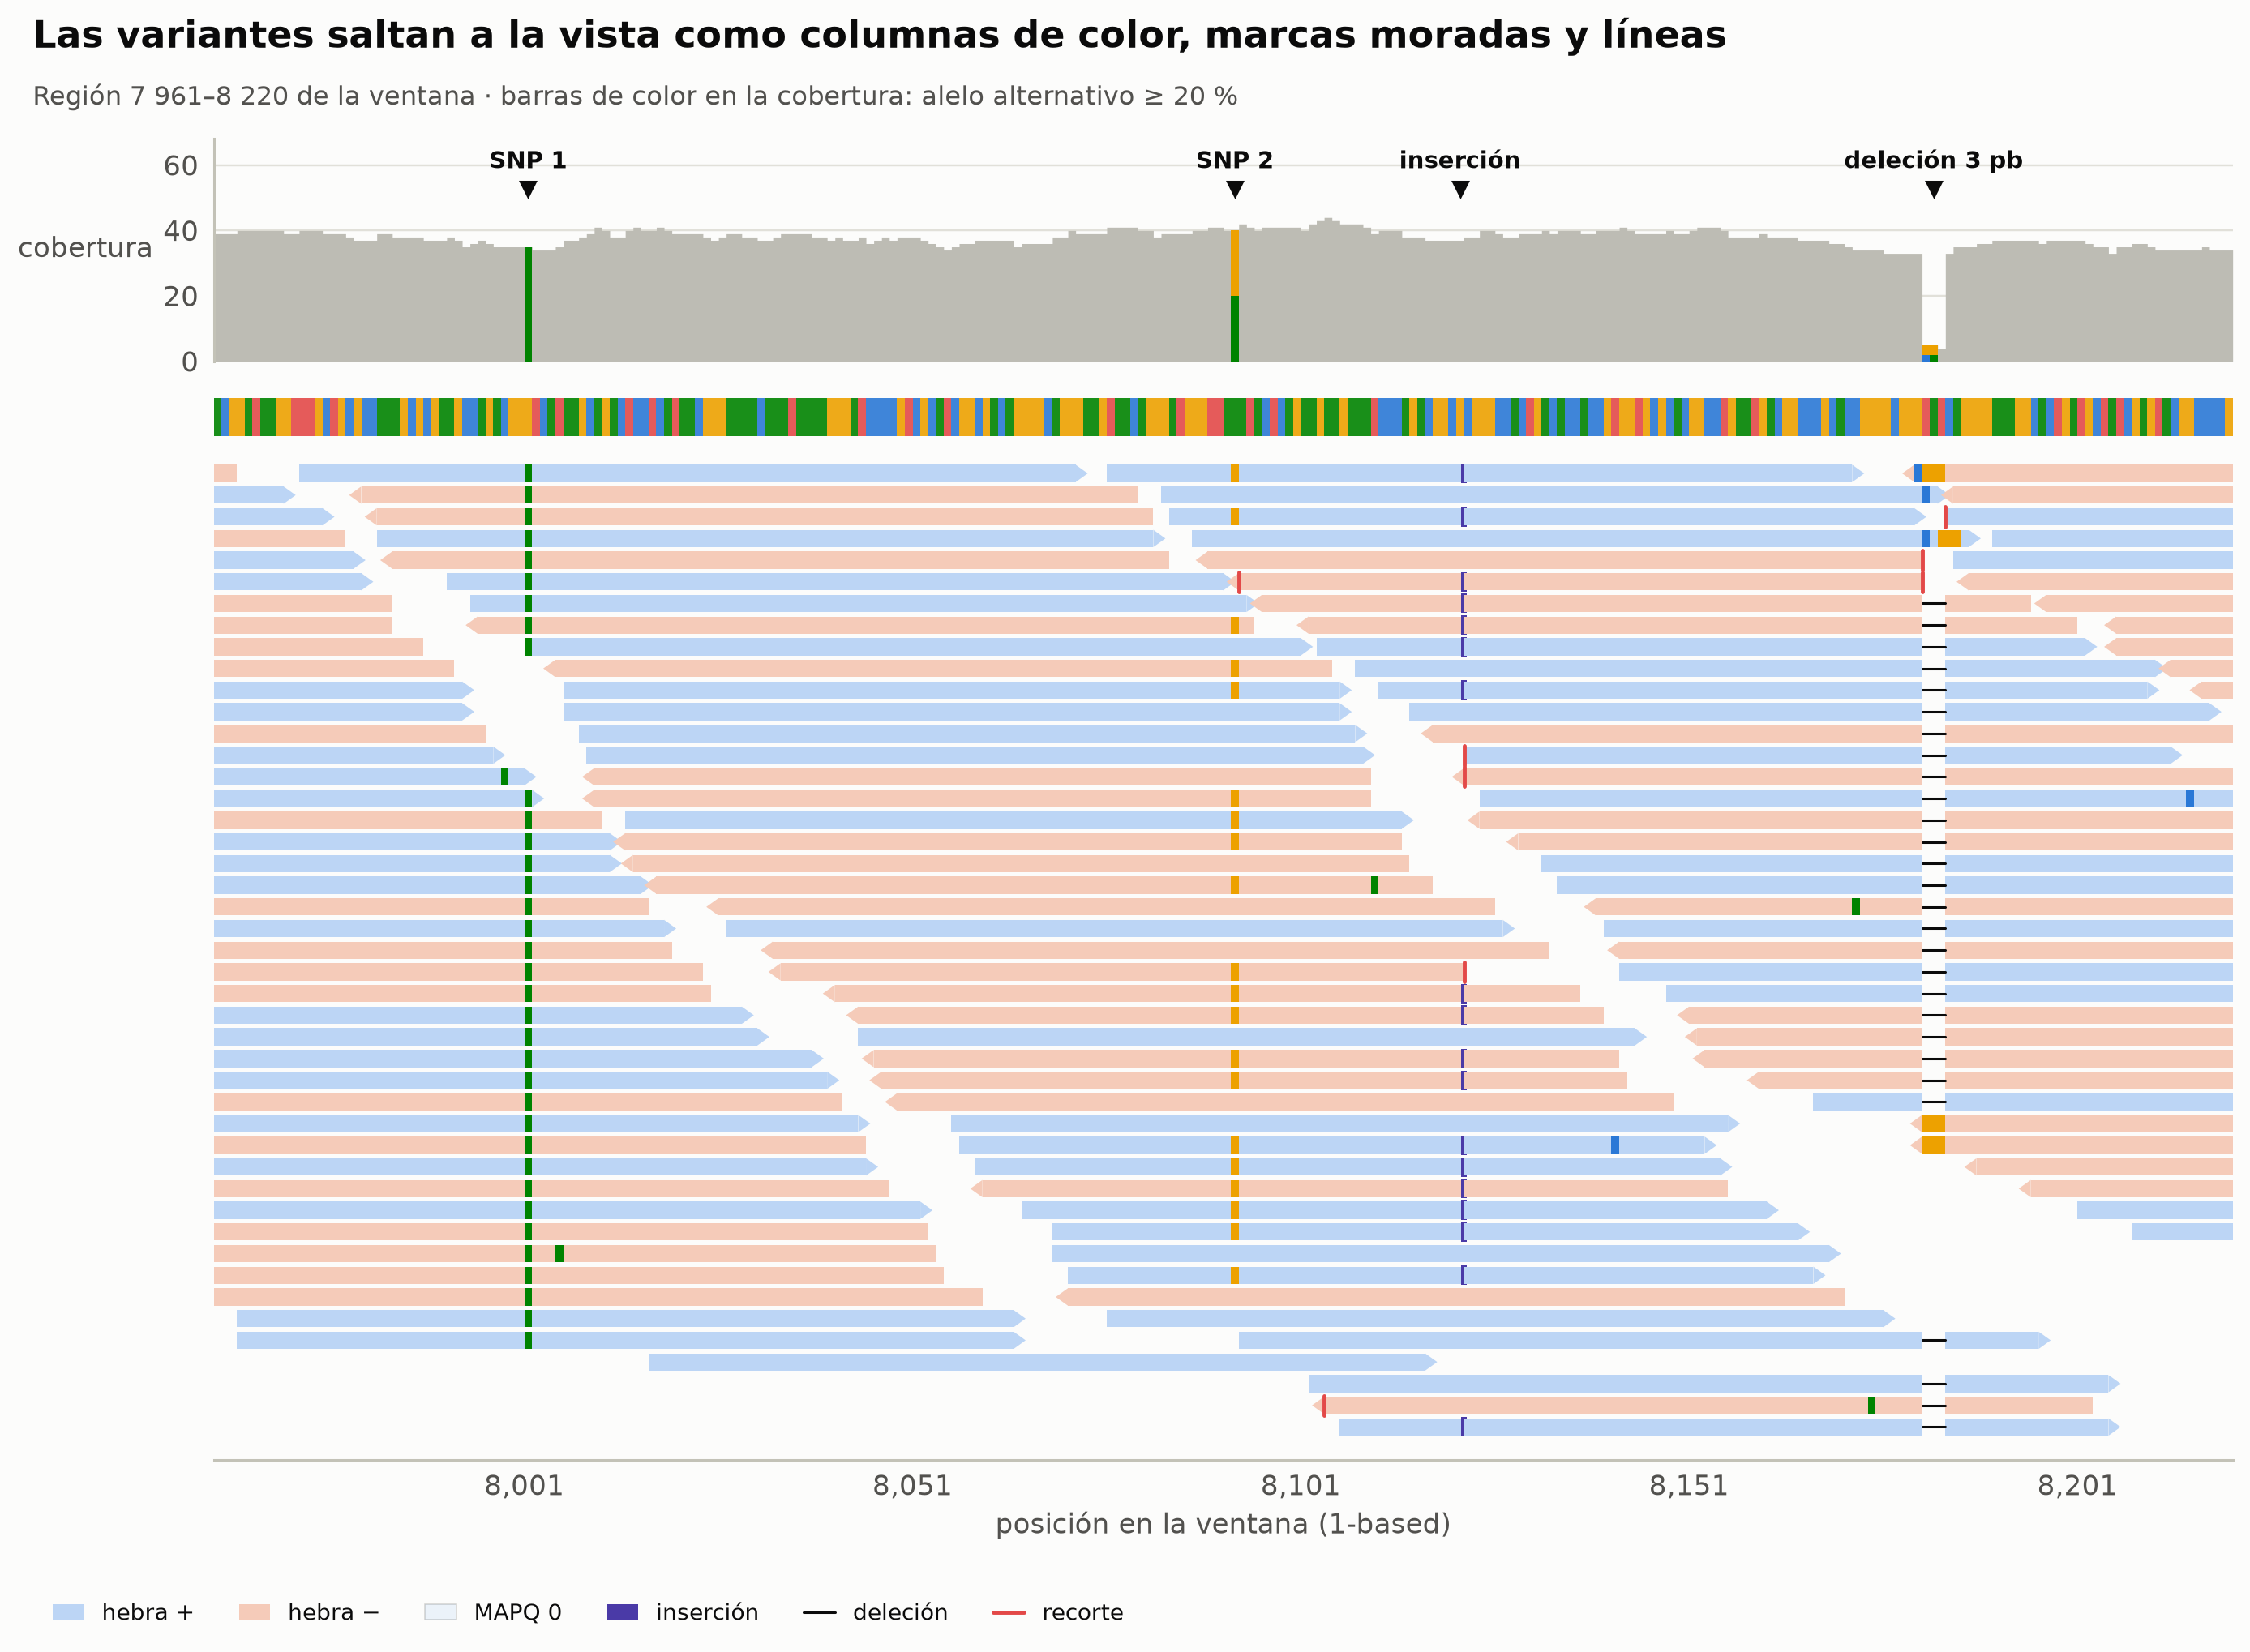

In [18]:
fig = igv_view(7_960, 8_220,
               "Las variantes saltan a la vista como columnas de color, marcas moradas y líneas",
               "Región 7 961–8 220 de la ventana · barras de color en la cobertura: alelo alternativo ≥ 20 %",
               marks=[(SNP1, "SNP 1"), (SNP2, "SNP 2"), (INS_POS, "inserción"), (DEL3[0] + 1, "deleción 3 pb")])
plt.show()

> 🔎 **Qué observamos.** Cuatro columnas destacan del fondo gris. En el **SNP 1** todas las lecturas llevan el
> cuadrito verde de la A y la pista de cobertura se vuelve toda verde: homocigota. En el **SNP 2** sólo la mitad de
> las lecturas tiene el cuadrito amarillo de la G, y la barra de cobertura sale mitad verde (A, la referencia) y mitad amarilla:
> heterocigota. La **inserción** aparece como barras moradas en la mitad de las lecturas, y la **deleción** como una
> línea negra que atraviesa todas; fíjese en que la cobertura **cae casi a cero** en esas 3 posiciones, porque una
> base borrada no cuenta en la profundidad (la deleción es homocigota: ninguna lectura tiene esas bases). Los cuadritos sueltos, dispersos al azar, son **errores de secuenciación**: nunca forman columna.
> Algunas lecturas que tocan la deleción en su extremo muestran un **tic rojo** (recorte) en lugar de la línea: al
> alineador le "salió más barato" recortar que abrir un hueco.

Acerquémonos a 90 pb para leer las letras, como haría en IGV con varios clics de zoom:

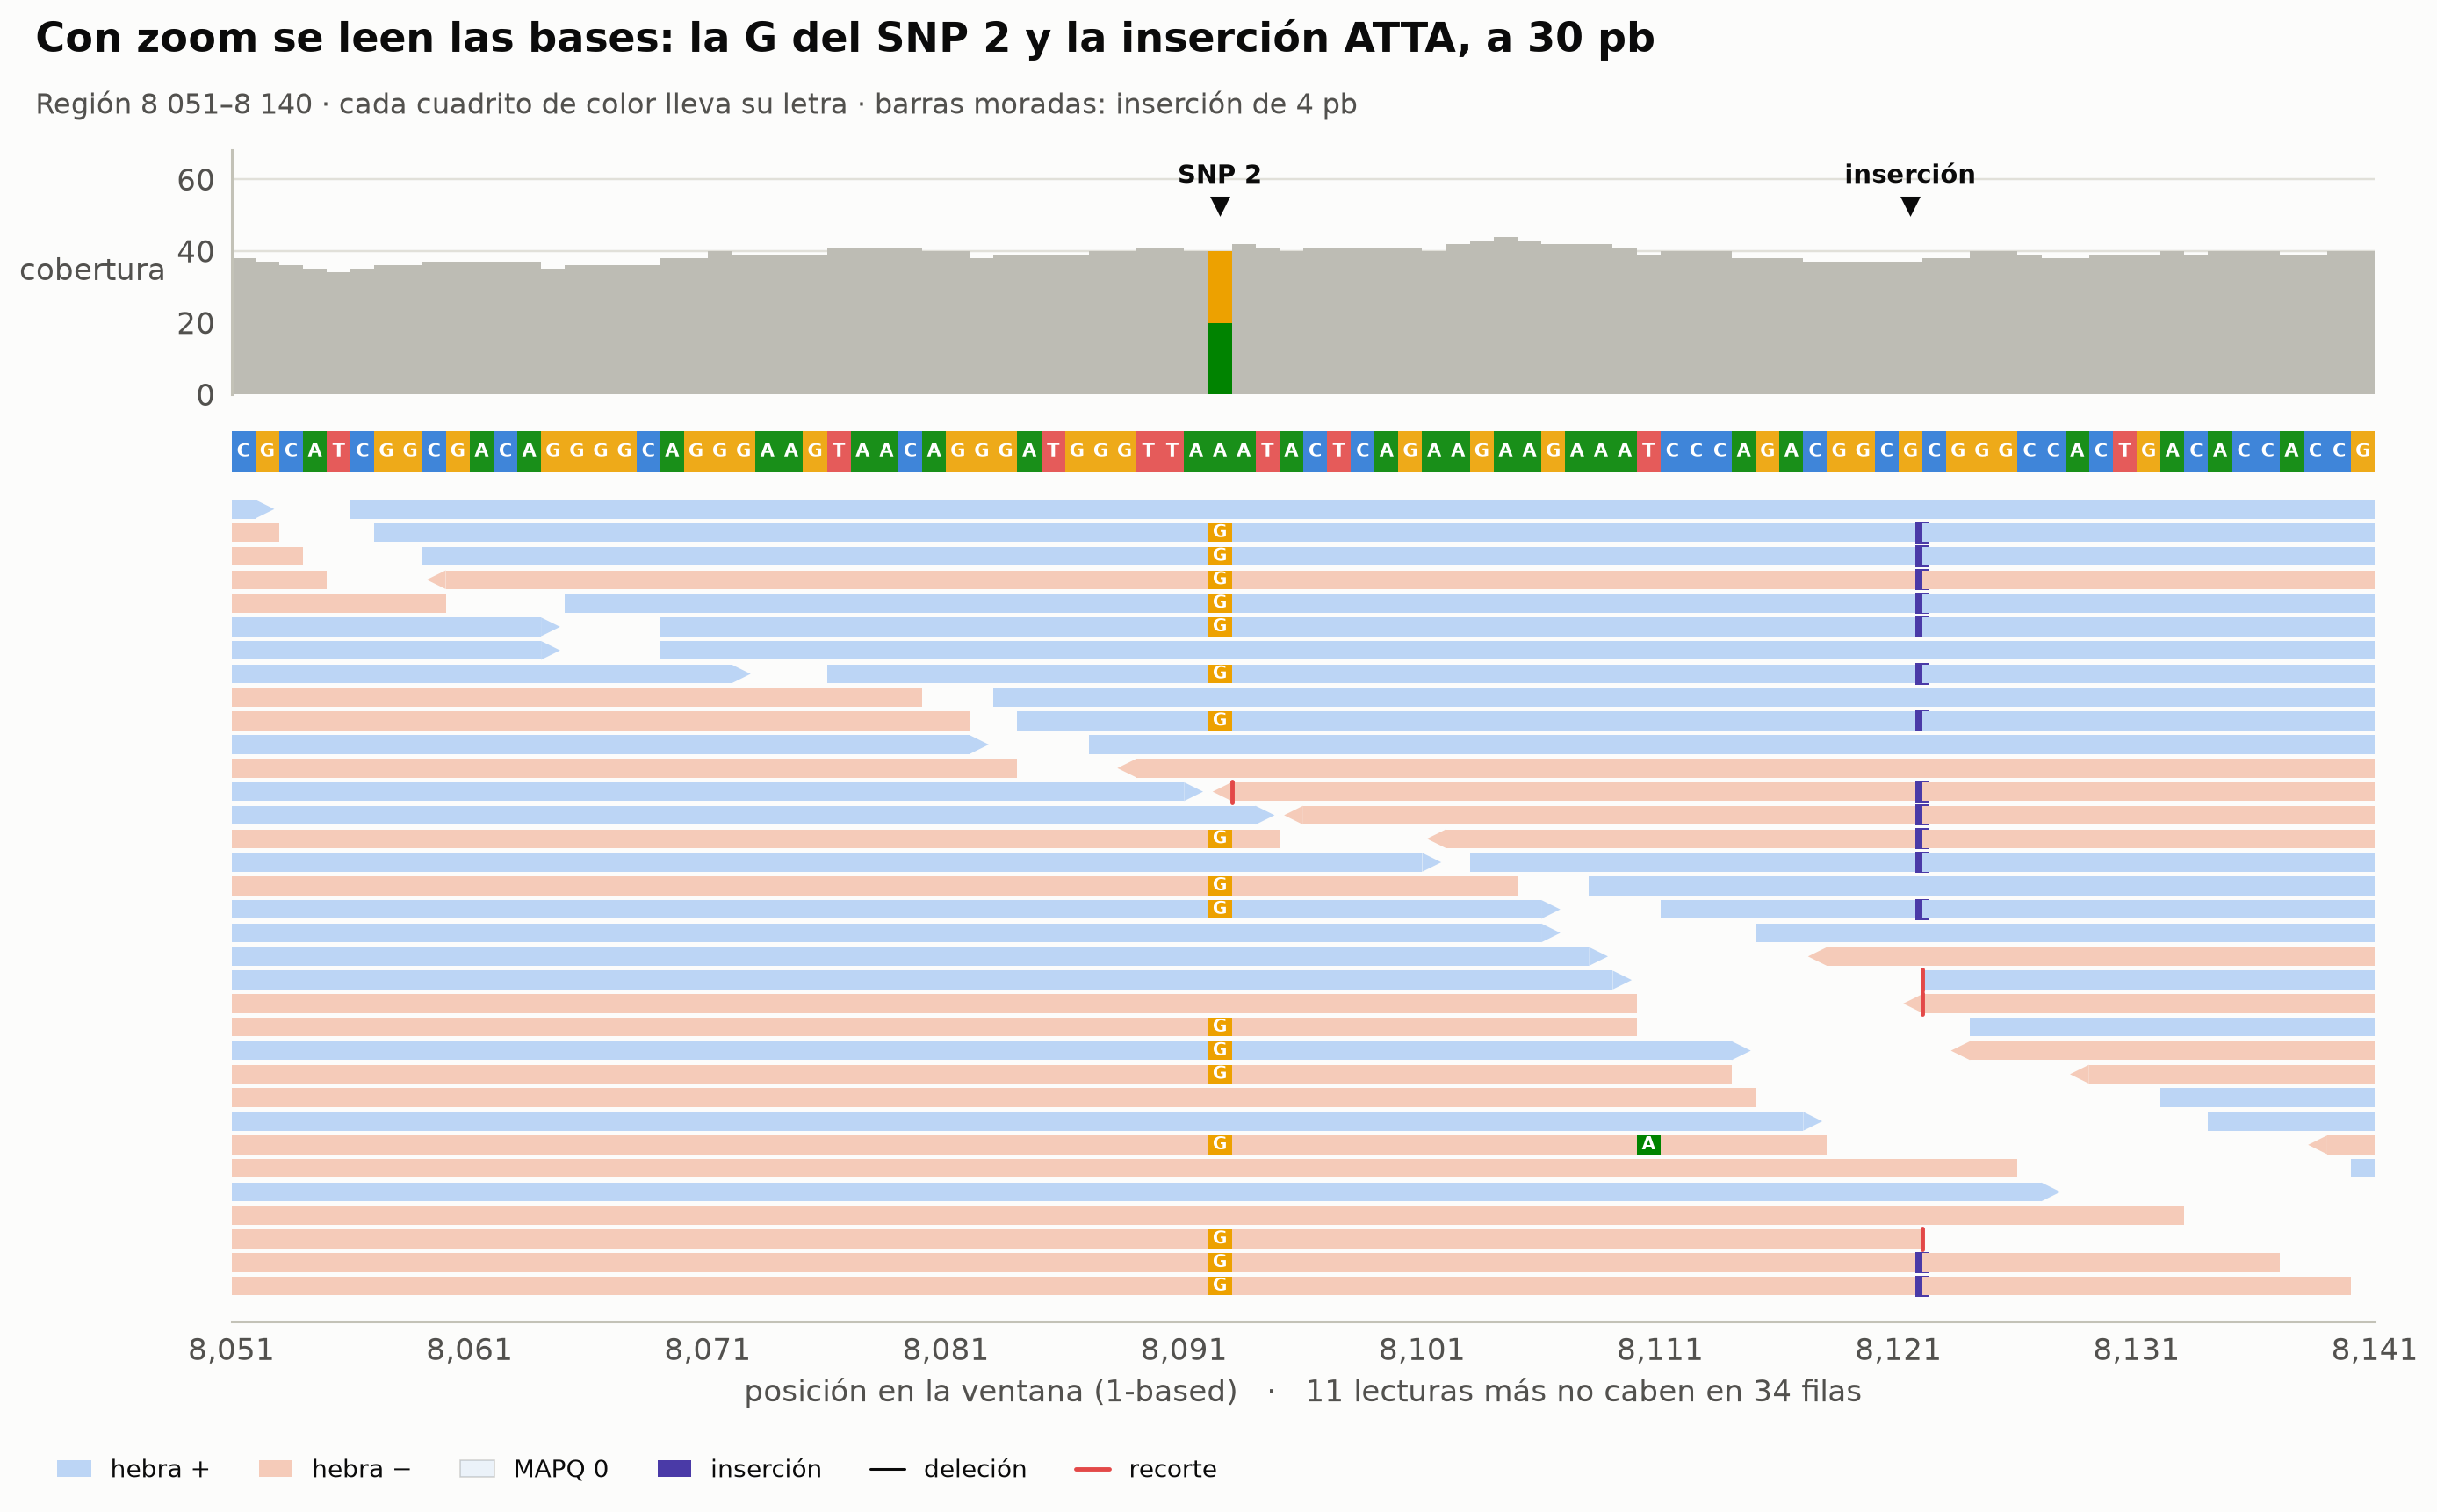

In [19]:
fig = igv_view(8_050, 8_140, "Con zoom se leen las bases: la G del SNP 2 y la inserción ATTA, a 30 pb",
               "Región 8 051–8 140 · cada cuadrito de color lleva su letra · barras moradas: inserción de 4 pb",
               marks=[(SNP2, "SNP 2"), (INS_POS, "inserción")], max_rows=34)
plt.show()

> 🔎 **Qué observamos.** Las letras permiten comprobar el cambio exacto (A→G) y ver que los desajustes sueltos
> (la `A` o la `C` aisladas) no se repiten en ninguna otra lectura. ¿Están el SNP 2 y la inserción en el **mismo
> haplotipo**? Sólo lo pueden decir las lecturas que cubren **ambas** posiciones: la mayoría termina antes de la
> inserción. Contemos las que sí llegan, y usemos además el **mate** de cada par, que amplía el alcance a ~350 pb.

In [20]:
def allele_at(r, p):
    """Qué muestra el alineamiento r en la posición p: una base, 'del', o None si no la cubre."""
    i, j = 0, r.pos
    for o, l in r.cigar:
        if o == "M":
            if j <= p < j + l:
                return r.seq[i + p - j]
            i += l; j += l
        elif o == "D":
            if j <= p < j + l:
                return "del"
            j += l
        elif o in "SI":
            i += l
    return None

def has_insertion(r, p):
    """¿Lleva el alineamiento r una inserción justo después de la base p? (None si no cubre p y p+1)."""
    if not (r.pos <= p and r.end > p + 1):
        return None
    j = r.pos
    for o, l in r.cigar:
        if o == "I" and j == p + 1:
            return True
        if o in "MD":
            j += l
    return False

frag = collections.defaultdict(dict)          # por par (fragmento): alelo en SNP 2 y presencia de la inserción
for r in mapped[(mapped["pos"] <= INS_POS + 1) & (mapped["end"] > SNP2)].itertuples():
    a, h = allele_at(r, SNP2), has_insertion(r, INS_POS)
    if a in (ref[SNP2], ALT2): frag[r.qname]["snp2"] = a
    if h is not None: frag[r.qname]["ins"] = "con inserción" if h else "sin inserción"
phase = pd.DataFrame([v for v in frag.values() if len(v) == 2])
pd.crosstab(phase["snp2"].map({ALT2: f"SNP 2 = {ALT2} (alt.)", ref[SNP2]: f"SNP 2 = {ref[SNP2]} (ref.)"}), phase["ins"],
            rownames=["alelo en 8 092"], colnames=["fragmentos (lectura o su mate)"])

fragmentos (lectura o su mate),con inserción,sin inserción
alelo en 8 092,,
SNP 2 = A (ref.),0,12
SNP 2 = G (alt.),12,0


> 🔎 **Qué observamos.** Los fragmentos se reparten en la diagonal: los que llevan la G llevan la inserción y los que
> llevan la A no. Ambas variantes están en el **mismo haplotipo** (el A de nuestra simulación): están **en fase**
> (*in cis*). Esta lectura directa de la fase sólo es posible cuando una lectura o un par cubre las dos variantes;
> con fragmentos de ~350 pb, dos variantes a 30 pb están al alcance, a 5 kb ya no (para eso se usan lecturas largas).

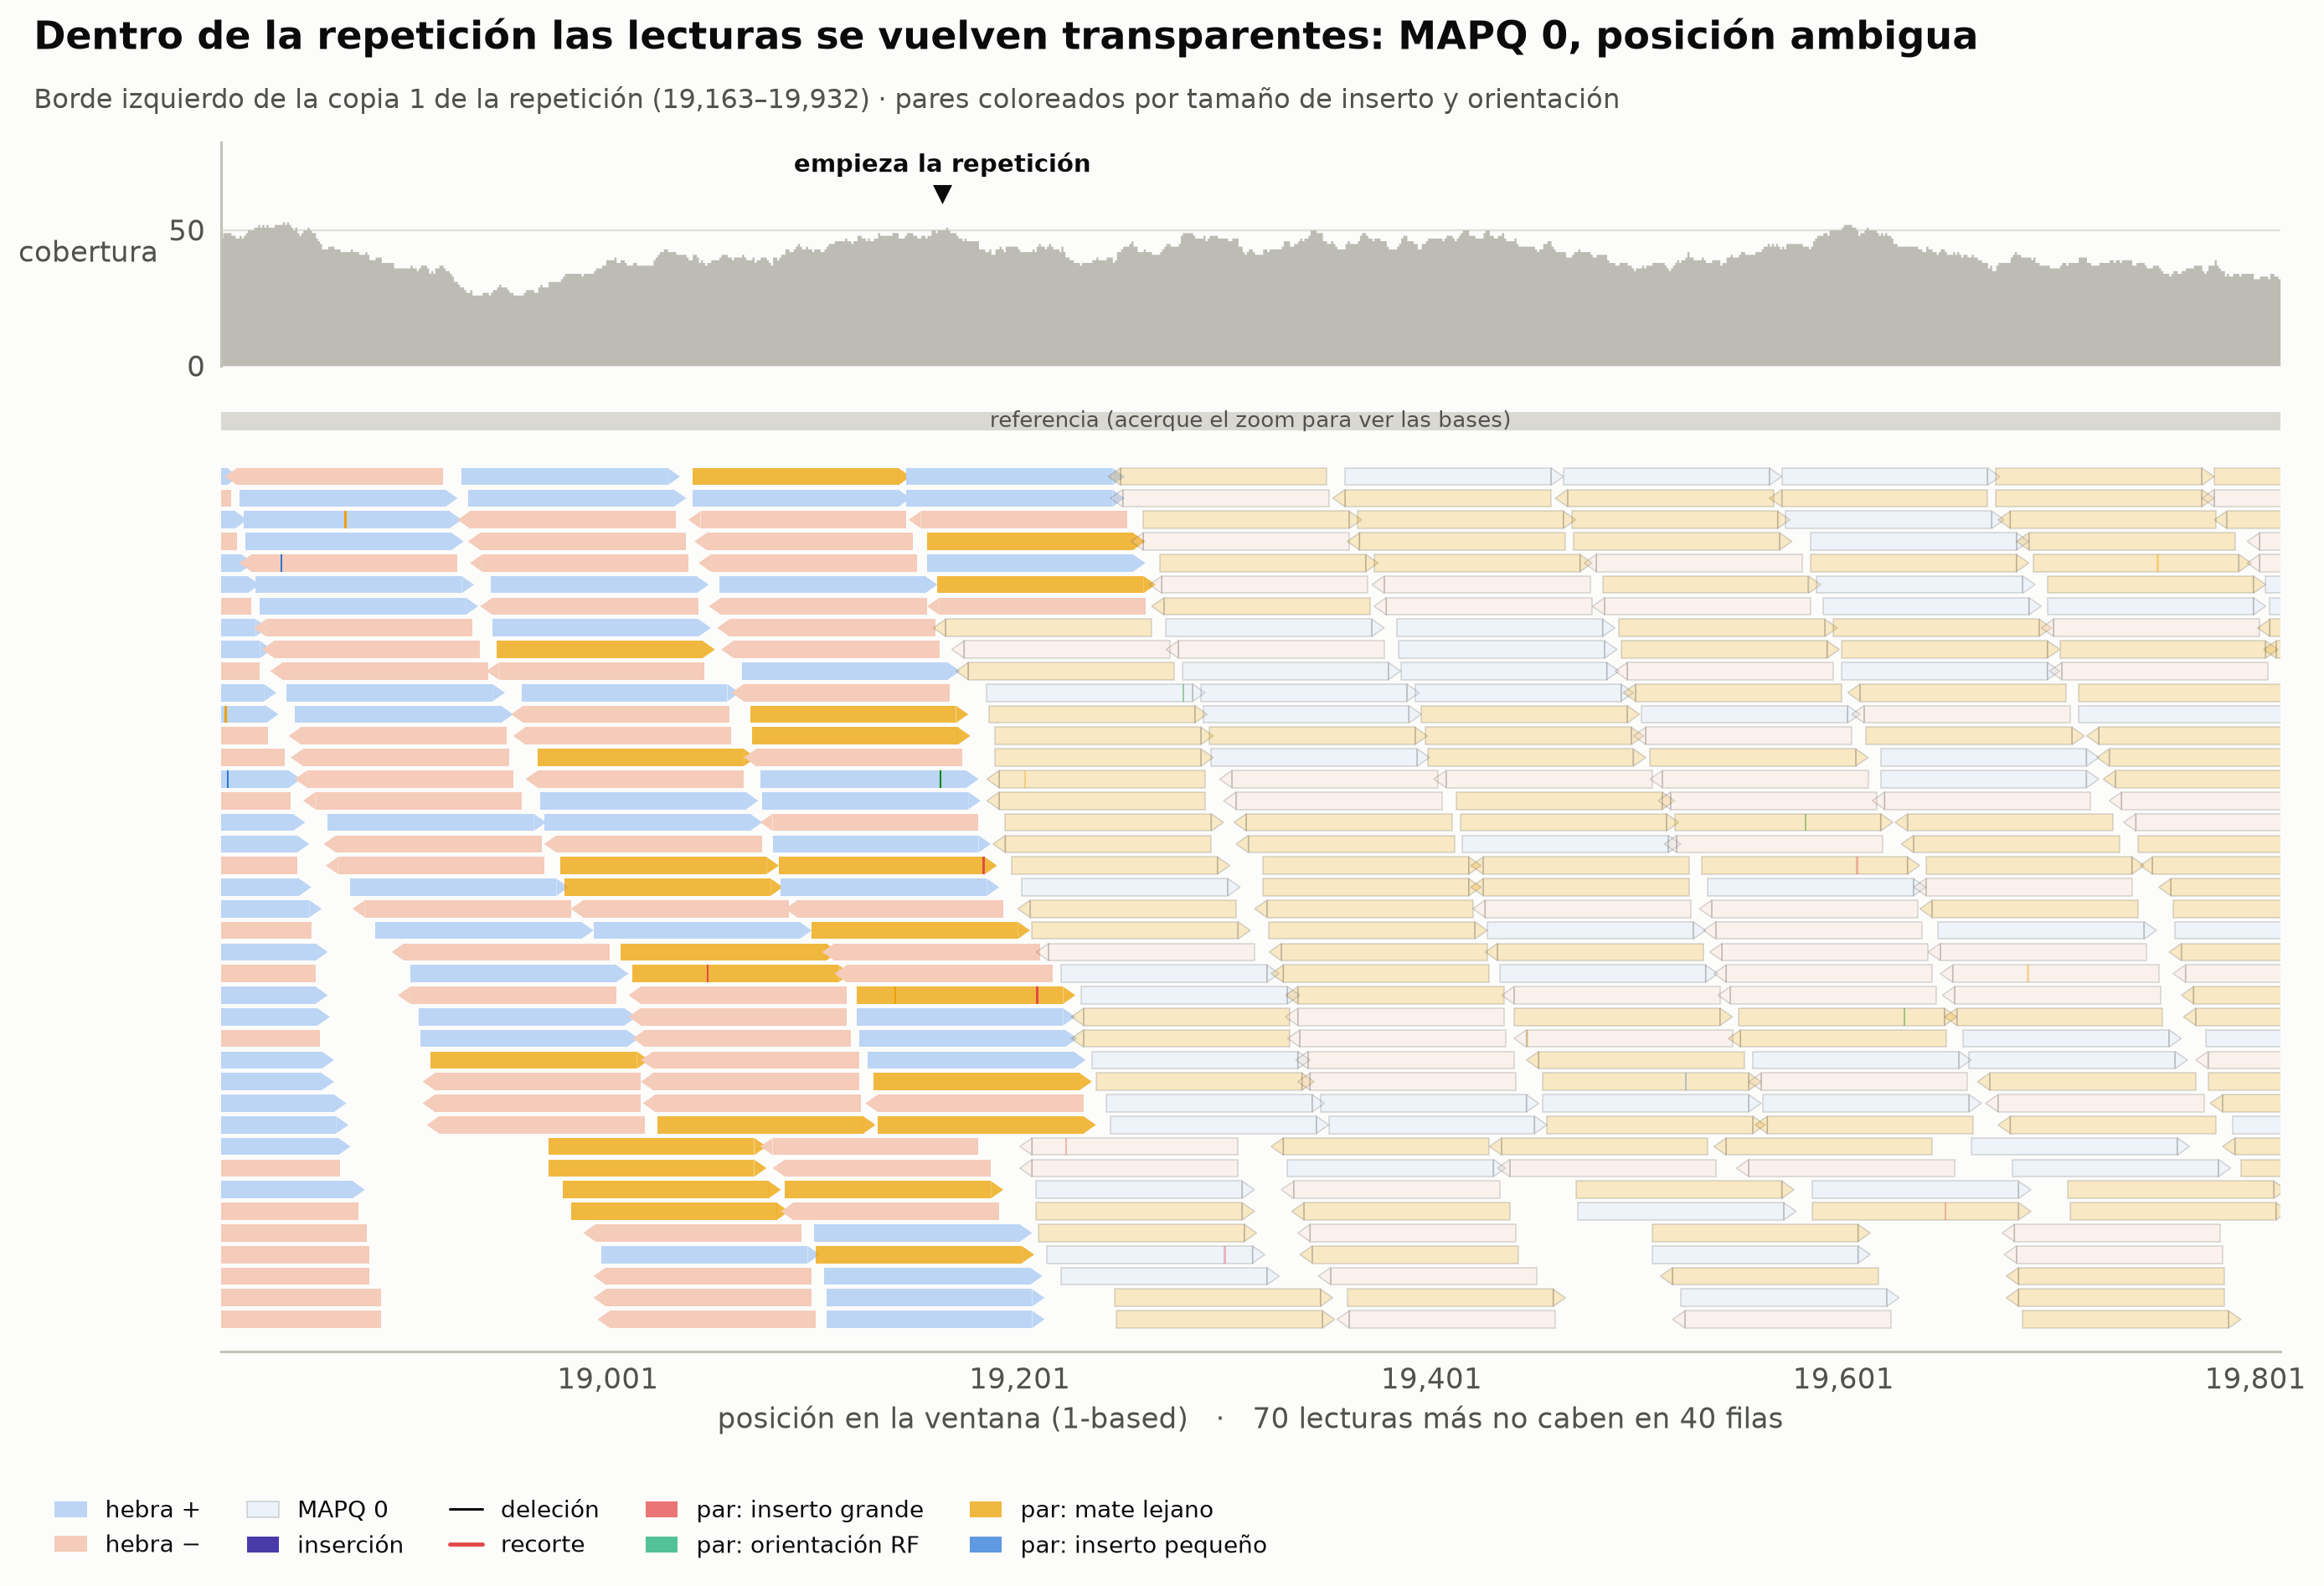

In [21]:
R0, R1 = REPEAT[0]
fig = igv_view(R0 - 350, R0 + 650,
               "Dentro de la repetición las lecturas se vuelven transparentes: MAPQ 0, posición ambigua",
               f"Borde izquierdo de la copia 1 de la repetición ({R0 + 1:,}–{R1:,}) · pares coloreados por tamaño de "
               "inserto y orientación", color_pairs=True, max_rows=40, marks=[(R0, "empieza la repetición")])
plt.show()

> 🔎 **Qué observamos.** A la izquierda del borde las lecturas son sólidas (MAPQ 60). A partir del borde aparecen
> lecturas **transparentes**: caen enteras en la repetición y el alineador las colocó aquí o en la otra copia a
> cara o cruz. Las amarillas son lecturas cuyo **mate** quedó en la otra copia, a ~11.5 kb. La pista de cobertura
> sigue siendo razonable (la mitad de las lecturas de cada copia "se van" a la otra y viceversa), pero **cualquier
> diferencia** entre las dos copias quedaría mezclada: por eso los programas de llamado de variantes descartan, por
> defecto, lecturas con MAPQ bajo.

### 🎛️ Un navegador interactivo

La misma vista en Plotly: arrastre para hacer zoom, doble clic para volver, y pase el ratón por cualquier lectura
para ver su nombre, MAPQ, CIGAR, hebra y tamaño de inserto; o por la pista de cobertura para ver los conteos de cada
alelo. Cada lectura es una barra horizontal (`go.Bar` con `base` = inicio), lo que permite dibujar cientos con un
solo *trace*.

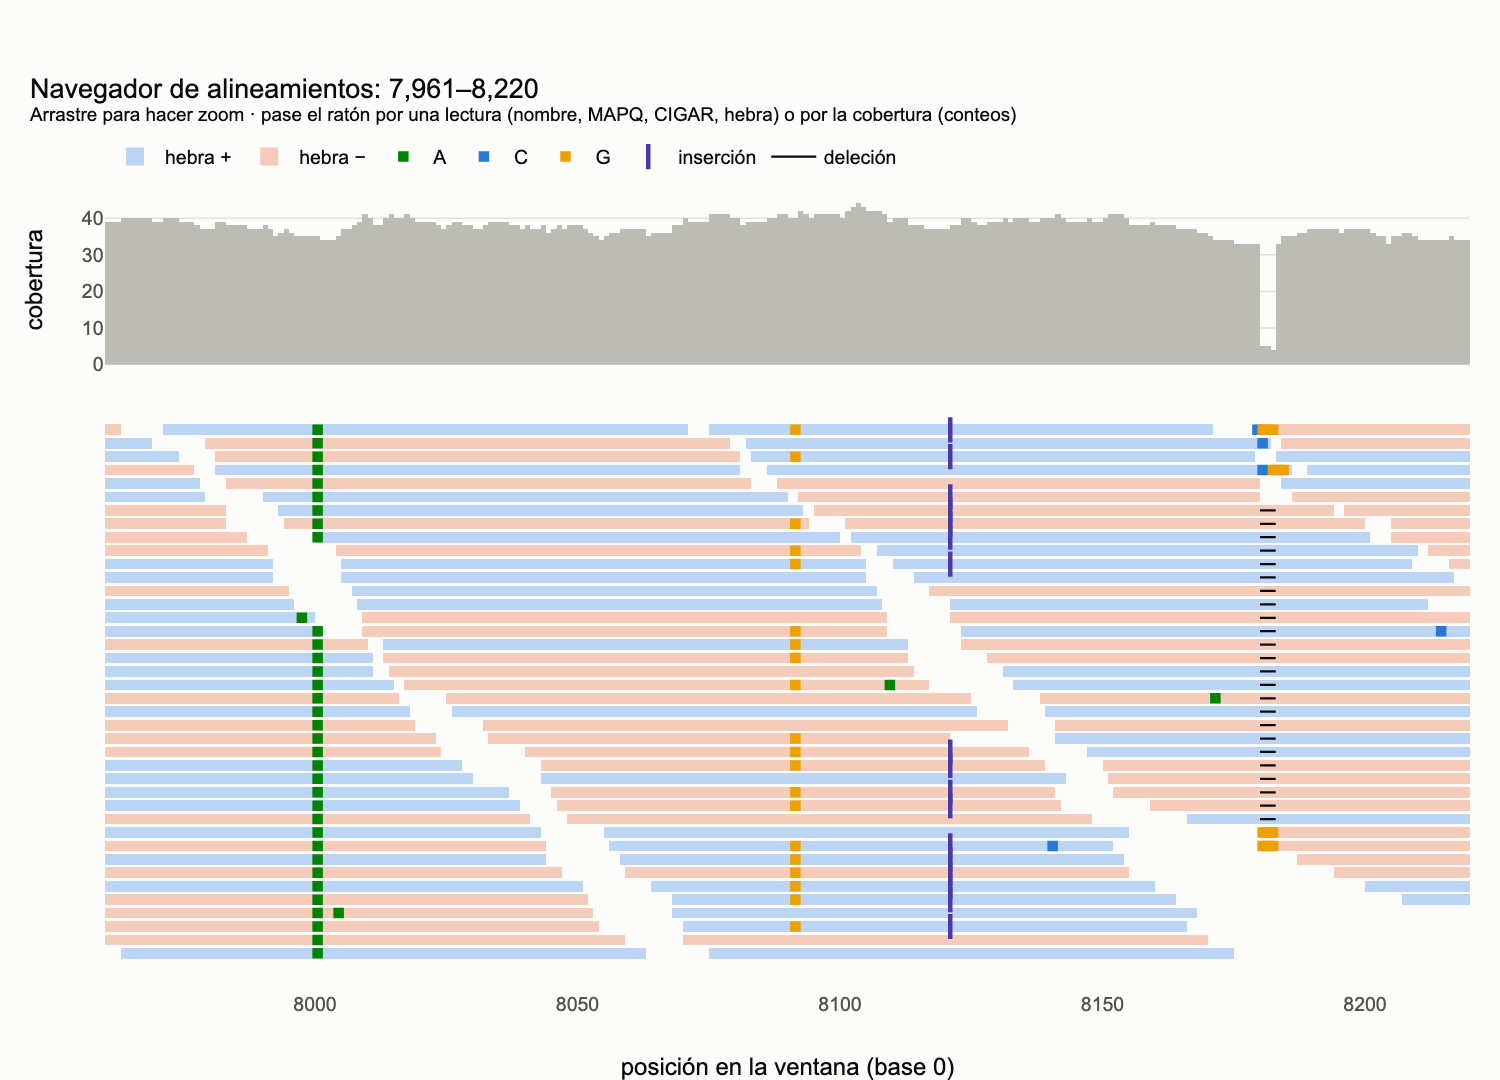

In [22]:
def plotly_browser(start, end, max_rows=40):
    sel = mapped[(mapped["pos"] < end) & (mapped["end"] > start)].sort_values(["pos", "end"]).copy()
    sel["row"] = pack_rows(sel["pos"], sel["end"], gap=2)
    sel = sel[sel["row"] < max_rows]
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.22, 0.78], vertical_spacing=0.03)
    x = np.arange(start, end)
    c = counts[start:end]
    hover_c = [f"posición {p + 1:,} · ref {ref[p]}<br>profundidad {c[k, :4].sum()}<br>"
               + " · ".join(f"{a}: {c[k, n]}" for n, a in enumerate(ALLELES)) for k, p in enumerate(x)]
    fig.add_trace(go.Bar(x=x + 0.5, y=c[:, :4].sum(1), width=1, marker_color="#bdbcb4", name="cobertura",
                         hovertext=hover_c, hoverinfo="text", showlegend=False), row=1, col=1)
    groups = [("hebra +", (sel["strand"] == "+") & (sel["mapq"] > 0), FWD_TONE, 1),
              ("hebra −", (sel["strand"] == "-") & (sel["mapq"] > 0), REV_TONE, 1),
              ("MAPQ 0", sel["mapq"] == 0, "#c9c8c2", 0.45)]
    for lab, m, col, op in groups:
        g = sel[m]
        hov = [f"<b>{r.qname}</b> ({'R1' if r.read1 else 'R2'}{', suplementaria' if r.supp else ''})<br>"
               f"{r.pos + 1:,}–{r.end:,} · hebra {r.strand}<br>MAPQ {r.mapq} · CIGAR {r.cigar_s} · NM {r.nm}<br>"
               f"TLEN {r.tlen} · mate en {r.mpos + 1:,}" for r in g.itertuples()]
        fig.add_trace(go.Bar(y=g["row"], x=g["end"] - g["pos"], base=g["pos"], orientation="h", width=0.8,
                             marker=dict(color=col, opacity=op), name=lab, hovertext=hov, hoverinfo="text"),
                      row=2, col=1)
    mm = collections.defaultdict(lambda: ([], [], []))
    ins_x, ins_y, ins_t, del_x, del_y = [], [], [], [], []
    for r in sel.itertuples():
        i, j = 0, r.pos
        for o, l in r.cigar:
            if o == "M":
                for t in range(l):
                    if r.seq[i + t] != ref[j + t] and start <= j + t < end:
                        b = r.seq[i + t]
                        mm[b][0].append(j + t + 0.5); mm[b][1].append(r.row)
                        mm[b][2].append(f"{j + t + 1:,}: {ref[j + t]}→{b} · BQ {r.qual[i + t]} · {r.qname}")
                i += l; j += l
            elif o == "I":
                ins_x.append(j); ins_y.append(r.row); ins_t.append(f"inserción {r.seq[i:i + l]} tras {j:,}"); i += l
            elif o == "D":
                del_x += [j, j + l, None]; del_y += [r.row, r.row, None]; j += l
            elif o == "S":
                i += l
    for b in "ACGT":
        xs, ys, ts = mm[b]
        fig.add_trace(go.Scatter(x=xs, y=ys, mode="markers", name=b, text=ts, hoverinfo="text",
                                 marker=dict(symbol="square", size=7, color=ec.NUC_COLORS[b])), row=2, col=1)
    fig.add_trace(go.Scatter(x=ins_x, y=ins_y, mode="markers", name="inserción", text=ins_t, hoverinfo="text",
                             marker=dict(symbol="line-ns", size=12, line=dict(width=3, color=ec.VIOLET))), row=2, col=1)
    fig.add_trace(go.Scatter(x=del_x, y=del_y, mode="lines", name="deleción", line=dict(color=ec.INK, width=1.5),
                             hoverinfo="skip"), row=2, col=1)
    fig.update_yaxes(autorange="reversed", showticklabels=False, showgrid=False, row=2, col=1)
    fig.update_yaxes(title_text="cobertura", row=1, col=1)
    fig.update_xaxes(title_text="posición en la ventana (base 0)", range=[start, end], row=2, col=1)
    fig.update_layout(barmode="overlay", height=720, bargap=0,
                      title=f"Navegador de alineamientos: {start + 1:,}–{end:,}<br><sup>Arrastre para hacer zoom · "
                            "pase el ratón por una lectura (nombre, MAPQ, CIGAR, hebra) o por la cobertura (conteos)</sup>",
                      legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=70, r=20, b=60))
    return fig

plotly_browser(7_960, 8_220).show()

> 🔎 **Qué observamos.** El navegador reproduce la figura estática, pero ahora cada objeto "habla": al pasar sobre
> una lectura con la barra morada, el CIGAR dice `…4I…`; sobre la columna del SNP 2, la cobertura informa algo como
> `A: 12 · G: 12`. Haga zoom en la deleción de 3 pb y compare el CIGAR de una lectura con la línea negra (`…3D…`)
> con el de una lectura recortada en ese punto (`…S`).

## 7. Frecuencia alélica por posición

### De conteos a frecuencias

El pileup nos da, para cada posición $x$, cuántas lecturas muestran cada alelo. La **frecuencia alélica** (VAF,
*variant allele fraction*) del alelo $a$ es simplemente su proporción:

$$
\text{AF}_a(x) \;=\; \frac{n_a(x)}{\sum_{b \in \{A,C,G,T,\text{del}\}} n_b(x)}
$$

| Símbolo | Significado |
|---|---|
| $n_a(x)$ | lecturas que muestran el alelo $a$ en la posición $x$ |
| $\sum_b n_b(x)$ | profundidad de la columna (aquí incluimos las deleciones, como `mpileup`) |
| $\text{AF}_a(x)$ | frecuencia del alelo $a$; para "el" alelo alternativo usamos el alelo no referencia más frecuente |

En un organismo diploide esperamos tres niveles: $\text{AF} \approx 0$ (la muestra coincide con la referencia),
$\approx 0.5$ (heterocigoto) y $\approx 1$ (homocigoto). En una muestra mezclada (un tumor con células normales, una
población de bacterias o de virus) puede aparecer cualquier valor intermedio.

### ¿Cuánto se aleja 0.5 de 0.5 por azar?

Con profundidad $D$, el número de lecturas alternativas en un heterocigoto sigue una **binomial**
$k \sim \text{Bin}(D, 0.5)$: a 20× no esperamos exactamente 10, sino algo entre 6 y 14 el 95 % de las veces. En una
posición sin variante, en cambio, las lecturas alternativas sólo vienen de errores, con probabilidad por base
$\varepsilon$ del orden de $10^{-3}$–$10^{-2}$:

$$
P(k \mid D, p) = \binom{D}{k}\, p^{k} (1-p)^{D-k},
\qquad
p = \begin{cases} \varepsilon & \text{sin variante} \\ 0.5 & \text{heterocigoto} \\ 1 - \varepsilon & \text{homocigoto} \end{cases}
$$

**Ejemplo a mano.** En el SNP 2 contamos, digamos, $k = 10$ G de $D = 20$ lecturas. Bajo "heterocigoto",
$P = \binom{20}{10} 0.5^{20} = 184\,756 / 1\,048\,576 \approx 0.18$. Bajo "error" con $\varepsilon = 0.01$,
$P = \binom{20}{10}\, 0.01^{10}\, 0.99^{10} \approx 184\,756 \times 10^{-20} \times 0.90 \approx 1.7 \times 10^{-15}$.
El cociente de verosimilitudes es de $10^{14}$ a favor de la variante. Así razonan, en esencia, los llamadores de
variantes (Módulo 9); nosotros usaremos la frecuencia para **mirar**.

In [23]:
tot = counts.sum(1)                                  # profundidad con deleciones (como mpileup)
ref_idx = np.array(["ACGT".index(b) for b in ref])
nonref = counts.copy()
nonref[np.arange(REF_LEN), ref_idx] = -1             # excluir el alelo de referencia
alt_idx = nonref.argmax(1)
alt_n = counts[np.arange(REF_LEN), alt_idx]
af = np.where(tot > 0, alt_n / np.maximum(tot, 1), np.nan)
alt_allele = np.array(ALLELES)[alt_idx]

cand = np.flatnonzero((af >= 0.1) & (alt_n >= 3))
cand_df = pd.DataFrame({"posición": cand + 1, "ref": [ref[p] for p in cand], "alt": alt_allele[cand],
                        "n_alt": alt_n[cand], "profundidad": tot[cand], "AF": af[cand].round(3)})
ins_cand = [(p, c.most_common(1)[0]) for p, c in ins_at.items() if sum(c.values()) >= 3]
print(f"Posiciones con AF ≥ 0.1 y ≥ 3 lecturas alternativas: {len(cand)} · inserciones con ≥ 3 lecturas: "
      + ", ".join(f"tras {p + 1:,} ({s}: {n} lecturas)" for p, (s, n) in ins_cand))
print(f"Fuera de ellas, la AF mediana de las posiciones con algún error es "
      f"{np.nanmedian(af[(alt_n > 0) & (af < 0.1)]):.3f} (≈ 1 lectura de {np.median(tot):.0f})")
cand_df

Posiciones con AF ≥ 0.1 y ≥ 3 lecturas alternativas: 6 · inserciones con ≥ 3 lecturas: tras 8,121 (ATTA: 18 lecturas)
Fuera de ellas, la AF mediana de las posiciones con algún error es 0.024 (≈ 1 lectura de 39)


,posición,ref,alt,n_alt,profundidad,AF
0,8001,G,A,35,35,1.000
1,8092,A,G,20,40,0.500
2,8181,T,del,28,33,0.848
3,8182,A,del,28,33,0.848
4,8183,T,del,28,32,0.875
5,15001,G,T,6,29,0.207


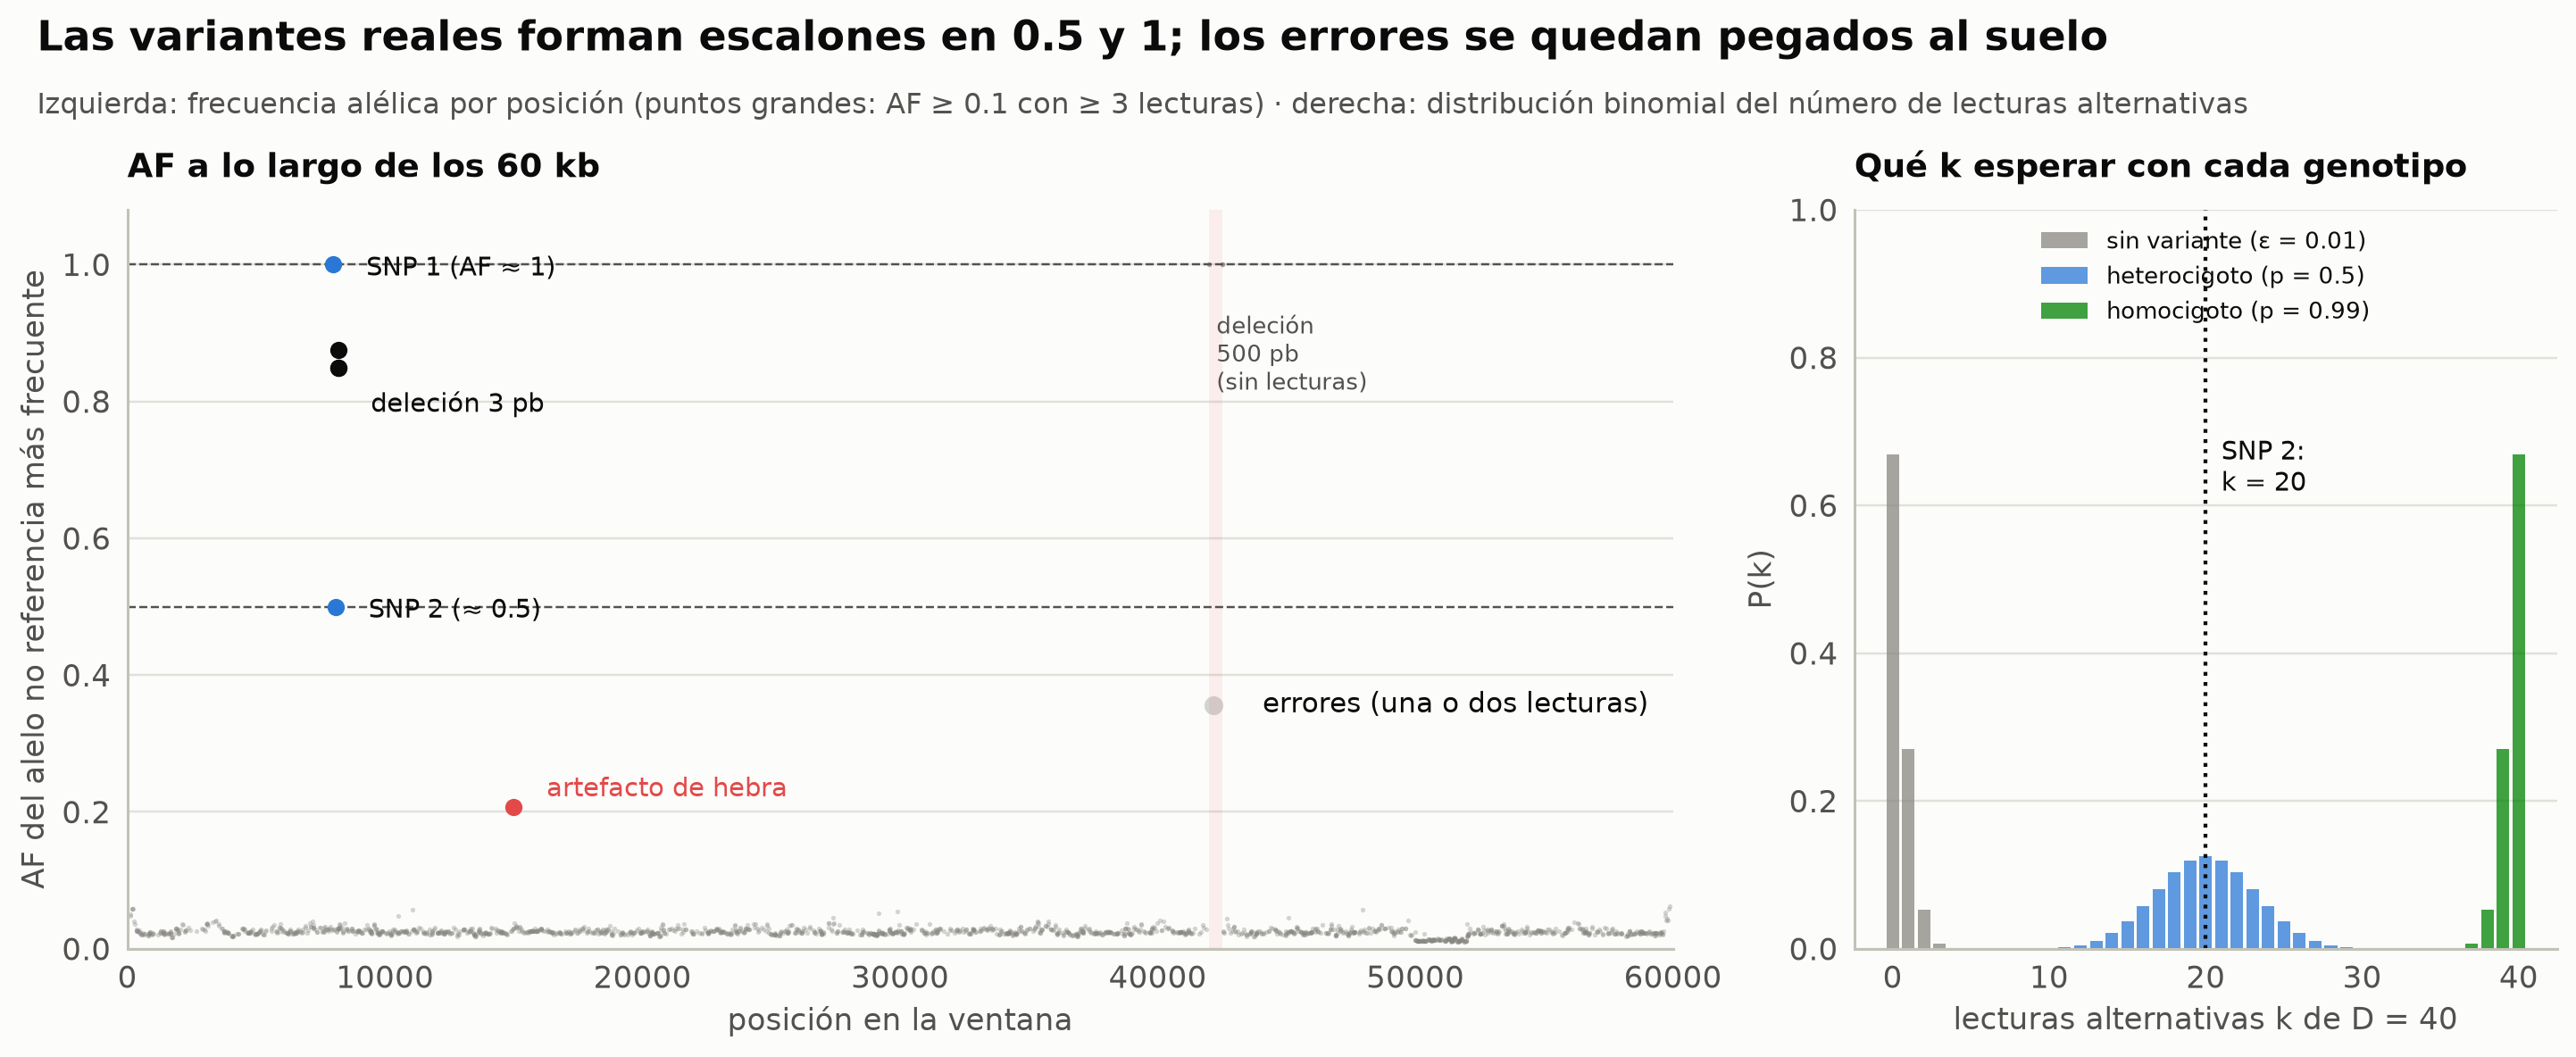

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[2.2, 1]))
ax = axes[0]
x = np.arange(REF_LEN)
bg = (alt_n > 0) & ~np.isin(x, cand)
ax.scatter(x[bg] + 1, af[bg], s=3, color=ec.MUTED, alpha=0.35, lw=0, label="errores (una o dos lecturas)")
cols = {"SNP": ec.BLUE, "del": ec.INK, "art": ec.RED}
labels = {SNP1: "SNP 1", SNP2: "SNP 2", ART_POS: "artefacto"}
for p in cand:
    kind = "del" if alt_allele[p] == "del" else ("art" if p == ART_POS else "SNP")
    ax.scatter(p + 1, af[p], s=40, color=cols[kind], zorder=3)
ax.annotate("SNP 1 (AF ≈ 1)", (SNP1 + 1, af[SNP1]), xytext=(12, -4), textcoords="offset points", fontsize=9.5)
ax.annotate("SNP 2 (≈ 0.5)", (SNP2 + 1, af[SNP2]), xytext=(12, -4), textcoords="offset points", fontsize=9.5)
ax.annotate("deleción 3 pb", (DEL3[0] + 1, af[DEL3[0]]), xytext=(12, -16), textcoords="offset points", fontsize=9.5)
ax.annotate("artefacto de hebra", (ART_POS + 1, af[ART_POS]), xytext=(12, 4), textcoords="offset points",
            fontsize=9.5, color=ec.RED)
for p in cand:
    if p not in (SNP1, SNP2, ART_POS) and alt_allele[p] != "del":
        ax.annotate(f"{p + 1:,}", (p + 1, af[p]), xytext=(6, 6), textcoords="offset points", fontsize=8.5,
                    color=ec.INK_2)
ax.axhline(0.5, color=ec.INK_2, lw=0.8, ls="--"); ax.axhline(1.0, color=ec.INK_2, lw=0.8, ls="--")
ax.axvspan(BIGDEL[0], BIGDEL[1], color=ec.RED, alpha=0.08, lw=0)
ax.text(BIGDEL[0], 0.93, " deleción\n 500 pb\n (sin lecturas)", fontsize=8.5, color=ec.INK_2, va="top")
ax.set_ylim(0, 1.08); ax.set_xlim(0, REF_LEN)
ax.set_xlabel("posición en la ventana"); ax.set_ylabel("AF del alelo no referencia más frecuente")
ax.legend(loc="center right", bbox_to_anchor=(1, 0.33), markerscale=4)
ax.set_title("AF a lo largo de los 60 kb", loc="left", fontsize=12)
ax = axes[1]
D = int(tot[SNP2])
k = np.arange(D + 1)
for p_, lab, col in [(0.01, "sin variante (ε = 0.01)", ec.MUTED), (0.5, "heterocigoto (p = 0.5)", ec.BLUE),
                     (0.99, "homocigoto (p = 0.99)", ec.GREEN)]:
    ax.bar(k, binom.pmf(k, D, p_), color=col, alpha=0.75, width=0.8, label=lab)
ax.axvline(alt_n[SNP2], color=ec.INK, lw=1.4, ls=":")
ax.text(alt_n[SNP2] + 1, 0.62, f"SNP 2:\nk = {alt_n[SNP2]}", fontsize=9.5)
ax.set_xlabel(f"lecturas alternativas k de D = {D}"); ax.set_ylabel("P(k)"); ax.set_ylim(0, 1)
ax.legend(loc="upper center", fontsize=8.5)
ax.set_title("Qué k esperar con cada genotipo", loc="left", fontsize=12)
ec.fig_title(fig, "Las variantes reales forman escalones en 0.5 y 1; los errores se quedan pegados al suelo",
             "Izquierda: frecuencia alélica por posición (puntos grandes: AF ≥ 0.1 con ≥ 3 lecturas) · "
             "derecha: distribución binomial del número de lecturas alternativas")
plt.show()

> 🔎 **Qué observamos.** Casi todas las posiciones con alguna lectura discordante quedan en AF ≈ 0.03–0.07: una o dos
> lecturas de treinta, errores de secuenciación dispersos. Destacan el SNP 1 en 1, el SNP 2 cerca de 0.5 y las tres
> posiciones de la deleción de 3 pb (alelo "del") en ~0.9. Y aparece un punto rojo en ~0.2: el **artefacto**. Si nos
> guiáramos sólo por la AF, podría pasar por una variante subclonal o una mezcla. La sección siguiente muestra cómo
> desenmascararlo. A la derecha, la distribución binomial explica por qué el SNP 2 no sale exactamente en 0.5: con
> $D \approx 20$ la dispersión natural es grande, y aun así la probabilidad de explicarlo por errores es nula.

### 🎬 El pileup en movimiento

La animación recorre, columna a columna, 80 pb que contienen los dos SNPs. Arriba, las lecturas y el cursor; abajo a
la izquierda, los conteos de la columna actual; abajo a la derecha, la curva de AF que se va construyendo.

![Recorrido del pileup: en cada columna se cuentan A, C, G, T y deleciones; la AF salta a 1 en el SNP 1 y a ~0.5 en el SNP 2](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.3_columna_pileup.gif)

*Recorrido del pileup: en cada columna se cuentan A, C, G, T y deleciones; la AF salta a 1 en el SNP 1 y a ~0.5 en el SNP 2*

In [25]:
S0, S1 = 7_985, 8_105
positions = np.arange(S0, S1, 3)
fig = plt.figure(figsize=(12, 7.2))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], width_ratios=[1, 2.2], hspace=0.12)
ax_r = fig.add_subplot(gs[0, :]); ax_b = fig.add_subplot(gs[1, 0]); ax_f = fig.add_subplot(gs[1, 1])
draw_reads(ax_r, S0, S1, max_rows=26)
ax_r.set_xticks([])
cursor = ax_r.axvspan(S0, S0 + 1, color=ec.YELLOW, alpha=0.35, lw=0)
bars = ax_b.bar(range(5), [0] * 5, color=[ec.NUC_COLORS[a] for a in "ACGT"] + [ec.INK], width=0.7)
ax_b.set_xticks(range(5), ALLELES); ax_b.set_ylim(0, tot[S0:S1].max() + 4); ax_b.set_ylabel("lecturas")
count_txt = [ax_b.text(i, 0, "", ha="center", va="bottom", fontsize=9, color=ec.INK_2) for i in range(5)]
ax_f.set_xlim(S0, S1); ax_f.set_ylim(-0.03, 1.1); ax_f.set_ylabel("AF no referencia")
ax_f.set_xlabel("posición (base 0)")
ax_f.axhline(0.5, color=ec.MUTED, lw=0.8, ls="--")
af_line, = ax_f.plot([], [], color=ec.BLUE, lw=1.8, drawstyle="steps-mid")
info = fig.text(0.01, 0.905, "", fontsize=11, color=ec.INK, va="top", family="monospace")
fig.text(0.01, 0.985, "Recorrer el pileup columna a columna convierte las lecturas en una curva de frecuencias",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.945, f"Posiciones {S0 + 1:,}–{S1:,} de la ventana · SNP 1 en {SNP1 + 1:,} (homocigoto) y SNP 2 en "
         f"{SNP2 + 1:,} (heterocigoto)", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    p = positions[f]
    cursor.set_x(p)
    c = counts[p]
    for i, b in enumerate(bars):
        b.set_height(c[i]); count_txt[i].set_position((i, c[i] + 0.3)); count_txt[i].set_text(str(c[i]) if c[i] else "")
    xs = np.arange(S0, p + 1)
    af_line.set_data(xs, np.nan_to_num(af[S0:p + 1]))
    info.set_text(f"posición {p + 1:,} · ref {ref[p]} · profundidad {tot[p]:>2} · alt {alt_allele[p]:>3}: "
                  f"{alt_n[p]:>2} lecturas · AF = {af[p]:.2f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(positions), interval=220, name="7.3_columna_pileup")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En casi todas las columnas la barra de la base de referencia se lleva todo y la AF queda
> en 0 (o da un saltito de una lectura, un error). En la columna del SNP 1 la barra verde de la A se lleva **todas**
> las lecturas y la AF salta a 1; en el SNP 2 la profundidad se reparte entre C y T y la AF queda cerca de 0.5.

### 🎛️ Frecuencia alélica interactiva

Pase el ratón por cualquier punto para ver los conteos completos de la columna (A, C, G, T, deleción) y por las
cruces moradas para ver las inserciones. Haga zoom en la región 7 950–8 250 para ver juntos los dos SNPs, la
inserción y la deleción corta.

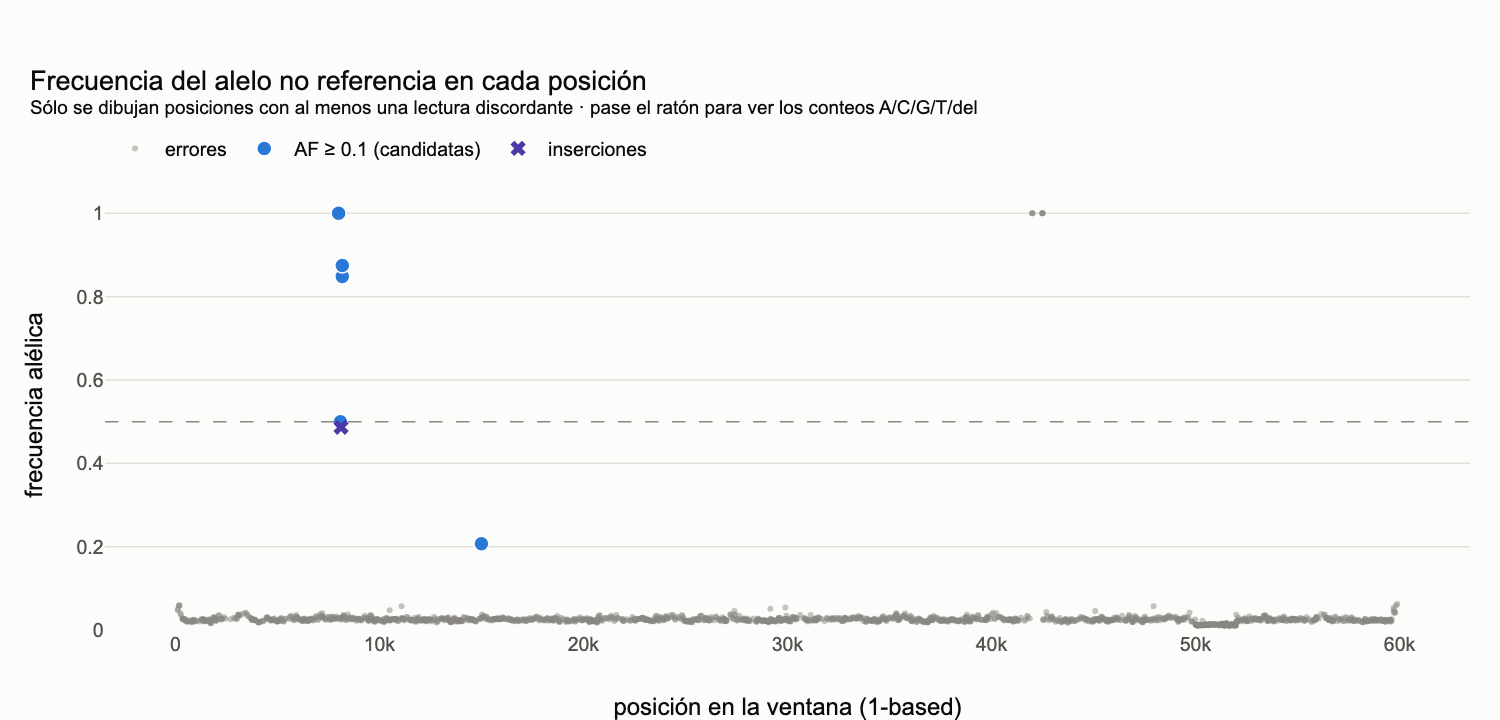

In [26]:
show_pos = np.flatnonzero(alt_n > 0)
hover = [f"<b>posición {p + 1:,}</b> · ref {ref[p]}<br>profundidad {tot[p]}<br>"
         + " · ".join(f"{a}: {counts[p, i]}" for i, a in enumerate(ALLELES))
         + f"<br>AF({alt_allele[p]}) = {af[p]:.3f}" for p in show_pos]
is_c = np.isin(show_pos, cand)
fig = go.Figure()
fig.add_trace(go.Scatter(x=show_pos[~is_c] + 1, y=af[show_pos[~is_c]], mode="markers", name="errores",
                         marker=dict(size=4, color=ec.MUTED, opacity=0.5),
                         hovertext=[h for h, c in zip(hover, is_c) if not c], hoverinfo="text"))
fig.add_trace(go.Scatter(x=show_pos[is_c] + 1, y=af[show_pos[is_c]], mode="markers", name="AF ≥ 0.1 (candidatas)",
                         marker=dict(size=10, color=ec.BLUE, line=dict(width=1, color="white")),
                         hovertext=[h for h, c in zip(hover, is_c) if c], hoverinfo="text"))
ip = np.array(sorted(ins_at))
ins_af = np.array([sum(ins_at[p].values()) / max(tot[p], 1) for p in ip])
fig.add_trace(go.Scatter(x=ip + 1.5, y=ins_af, mode="markers", name="inserciones",
                         marker=dict(symbol="x", size=9, color=ec.VIOLET),
                         hovertext=[f"inserción tras {p + 1:,}<br>" + ", ".join(f"{s}: {n}" for s, n in ins_at[p].items())
                                    + f"<br>de {tot[p]} lecturas" for p in ip], hoverinfo="text"))
fig.add_hline(y=0.5, line=dict(color=ec.MUTED, dash="dash", width=1))
fig.update_layout(height=480, xaxis_title="posición en la ventana (1-based)", yaxis_title="frecuencia alélica",
                  yaxis_range=[0, 1.08],
                  title="Frecuencia del alelo no referencia en cada posición<br><sup>Sólo se dibujan posiciones con "
                        "al menos una lectura discordante · pase el ratón para ver los conteos A/C/G/T/del</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=20, b=60))
fig.show()

### La trampa del sesgo de hebra

Una variante verdadera está en la molécula de ADN, así que la leen **las dos hebras**: los fragmentos de la hebra +
y los de la hebra − deberían mostrarla en proporciones parecidas. Además, debe aparecer en **cualquier ciclo** de la
lectura, no sólo en los últimos (que son los de peor calidad). Un error sistemático de la química o de la
preparación de la biblioteca suele violar una de las dos cosas, o ambas.

Para cada candidata construimos la tabla de contingencia $2 \times 2$ (hebra × alelo) y aplicamos la **prueba exacta
de Fisher**, que responde: si el alelo fuera independiente de la hebra, ¿qué tan raro sería un reparto tan desigual?

| | referencia | alternativo |
|---|---|---|
| hebra + | $a$ | $b$ |
| hebra − | $c$ | $d$ |

$$
P(\text{tabla}) = \frac{\binom{a+b}{a}\binom{c+d}{c}}{\binom{n}{a+c}},
\qquad n = a + b + c + d
$$

y el valor $p$ suma las probabilidades de todas las tablas con los mismos totales que sean tan o más extremas que
la observada. **Ejemplo a mano:** si en una posición hay $b = 0$ alternativas en la hebra + frente a $d = 6$ en la
hebra −, con $a = 14$ y $c = 8$, la probabilidad de que las seis alternativas caigan **todas** en la hebra − por azar
es $\binom{14}{0}\binom{14}{6} / \binom{28}{6} = 3\,003 / 376\,740 \approx 0.008$. La prueba **bilateral** suma
también la tabla igual de extrema en el otro sentido (las seis en la hebra +): $p \approx 0.016$. Sospechoso.

In [27]:
def evidence(p, kind="snv"):
    """Una fila por lectura primaria que cubre p: alelo, hebra, calidad de base, ciclo, MAPQ y NM."""
    rows = []
    for r in mapped[(mapped["pos"] <= p) & (mapped["end"] > p) & ~mapped["supp"]].itertuples():
        if kind == "ins":
            h = has_insertion(r, p)
            if h is None:
                continue
            allele, qpos = ("ins" if h else "ref"), None
        else:
            allele = allele_at(r, p)
            if allele is None:
                continue
            allele = "ref" if allele == ref[p] else allele
            qpos = None
        i, j = 0, r.pos                         # índice de la base dentro de la lectura (para ciclo y calidad)
        for o, l in r.cigar:
            if o == "M" and j <= p < j + l:
                qpos = i + p - j; break
            if o in "MS" or o == "I": i += l
            if o in "MD": j += l
            if o == "D" and j > p: qpos = i; break
        qpos = min(qpos if qpos is not None else i, len(r.seq) - 1)
        cycle = qpos if r.strand == "+" else len(r.seq) - 1 - qpos
        rows.append(dict(allele=allele, strand=r.strand, bq=int(r.qual[qpos]), cycle=cycle, mapq=r.mapq, nm=r.nm))
    return pd.DataFrame(rows)

def strand_table(ev, alt):
    t = pd.crosstab(ev["strand"], ev["allele"] == alt).reindex(index=["+", "-"], columns=[False, True], fill_value=0)
    t.columns = ["ref", "alt"]
    return t

ev_snp2, ev_art = evidence(SNP2), evidence(ART_POS)
for lab, ev, alt in [("SNP 2", ev_snp2, ALT2), ("artefacto", ev_art, ART_ALT)]:
    t = strand_table(ev, alt)
    p = fisher_exact(t.values)[1]
    print(f"{lab}: +: {t.loc['+', 'ref']} ref / {t.loc['+', 'alt']} alt · −: {t.loc['-', 'ref']} ref / "
          f"{t.loc['-', 'alt']} alt · Fisher p = {p:.2g} · ciclo mediano del alt = "
          f"{ev.loc[ev['allele'] == alt, 'cycle'].median():.0f}")
print("Ejemplo a mano: p =", round(fisher_exact([[14, 0], [8, 6]])[1], 4))

SNP 2: +: 13 ref / 9 alt · −: 7 ref / 11 alt · Fisher p = 0.34 · ciclo mediano del alt = 30
artefacto: +: 14 ref / 0 alt · −: 9 ref / 6 alt · Fisher p = 0.017 · ciclo mediano del alt = 70
Ejemplo a mano: p = 0.0159


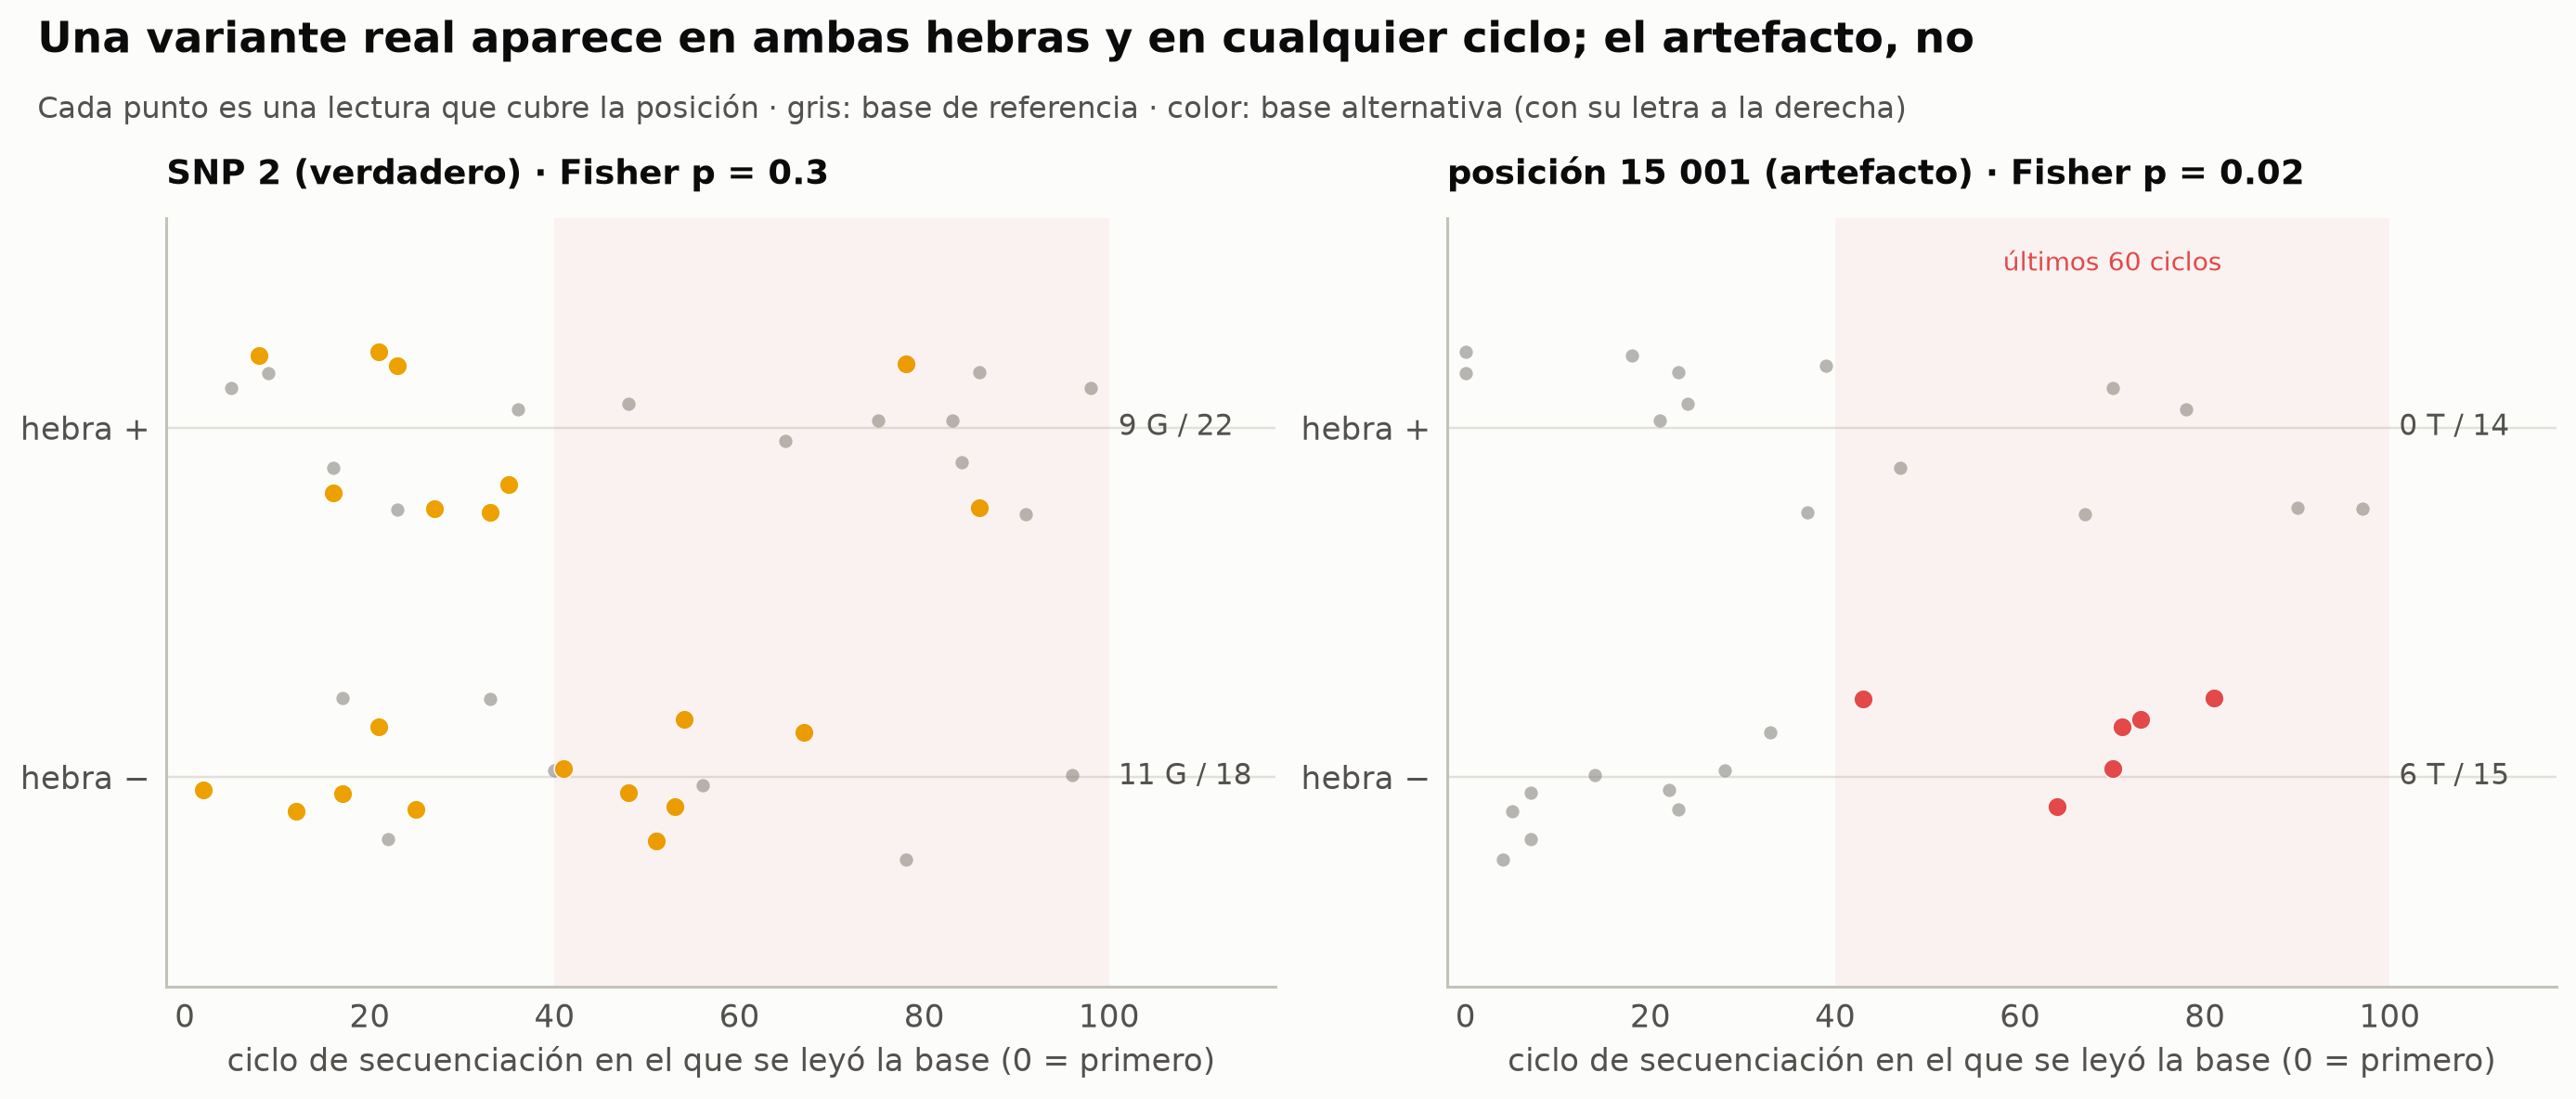

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (lab, ev, alt) in zip(axes, [("SNP 2 (verdadero)", ev_snp2, ALT2), ("posición 15 001 (artefacto)", ev_art, ART_ALT)]):
    for k, (st, ybase) in enumerate([("+", 1), ("-", 0)]):
        e = ev[ev["strand"] == st]
        is_alt = (e["allele"] == alt).to_numpy()
        jitter = np.random.default_rng(k).uniform(-0.25, 0.25, len(e))
        ax.scatter(e["cycle"][~is_alt], ybase + jitter[~is_alt], s=22, color=ec.MUTED, alpha=0.6, lw=0)
        ax.scatter(e["cycle"][is_alt], ybase + jitter[is_alt], s=46, color=ec.NUC_COLORS[alt], lw=0.5,
                   edgecolor="white")
        ax.text(101, ybase, f"{is_alt.sum()} {alt} / {len(e)}", va="center", fontsize=10, color=ec.INK_2)
    ax.set_yticks([0, 1], ["hebra −", "hebra +"]); ax.set_xlim(-2, 118); ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel("ciclo de secuenciación en el que se leyó la base (0 = primero)")
    t = strand_table(ev, alt)
    ax.set_title(f"{lab} · Fisher p = {fisher_exact(t.values)[1]:.1g}", loc="left", fontsize=12)
    ax.axvspan(40, 100, color=ec.RED, alpha=0.05, lw=0)
axes[1].text(70, 1.45, "últimos 60 ciclos", ha="center", fontsize=9, color=ec.RED)
ec.fig_title(fig, "Una variante real aparece en ambas hebras y en cualquier ciclo; el artefacto, no",
             "Cada punto es una lectura que cubre la posición · gris: base de referencia · color: base alternativa (con su letra a la derecha)")
plt.show()

> 🔎 **Qué observamos.** En el SNP 2 las G aparecen en ambas hebras y repartidas por todos los ciclos: justo lo que se
> espera de algo que está en la molécula. En la posición 15 001 **todas** las T están en lecturas de la hebra − y
> **todas** a partir del ciclo 40. Con tan pocas lecturas la prueba de Fisher sólo llega a $p \approx 0.02$, pero
> las dos señales juntas (hebra y ciclo) son inequívocas. Es la firma de un error
> sistemático (en datos reales, el daño oxidativo que convierte G en 8-oxoguanina produce precisamente falsos G→T en
> una sola orientación de lectura; Costello et al., 2013). En IGV se ve de inmediato coloreando las lecturas por
> hebra: todas las bases discordantes caen en un solo color.

✅ **Compruebe su comprensión.** Un colega le muestra una variante con AF = 0.35 y 40 lecturas, 14 alternativas: 13
en la hebra + y 1 en la hebra −, con 20 lecturas en cada hebra. ¿Qué haría antes de creerle? (Respuesta: calcular
Fisher — $p \approx 10^{-4}$ — y mirar en IGV si las alternativas se concentran en los extremos de las lecturas, si
tienen baja calidad de base o de mapeo, o si provienen de pocos fragmentos duplicados. Hay que desconfiar.)

## 8. Variación estructural: cobertura, pares discordantes y lecturas partidas

Una **variante estructural** (SV) cambia un tramo grande del genoma: deleciones, duplicaciones, inversiones,
translocaciones de cientos o miles de bases. Una lectura de 100 pb no puede "contener" una deleción de 500 pb, así que
la SV no aparece como una columna de color: se reconoce por **huellas indirectas** en los alineamientos. Hay tres
señales clásicas, y conviene que coincidan al menos dos:

| Señal | Deleción | Duplicación en tándem |
|---|---|---|
| **Profundidad** (*read depth*) | cae (a 0 si es homocigota, a la mitad si heterocigota) | sube (×2 si hay dos copias en cada haplotipo) |
| **Pares de lecturas** (*read pairs*) | orientación normal (FR) pero **inserto demasiado grande** | orientación **hacia afuera** (RF) |
| **Lecturas partidas** (*split reads*) | recortes que se acumulan **exactamente** en los dos bordes | recortes en los dos bordes de la copia |

¿Por qué "hacia afuera"? En la muestra, la duplicación en tándem crea una **unión nueva** donde el final de la copia 1
se pega al principio de la copia 2:

```
muestra:     ...[==== copia 1 ====][==== copia 2 ====]...
                               R1 →|← R2                    (un par normal que cruza la unión)
referencia:  ...[==== región (una sola copia) ====]...
                 ← R2 (va al principio)      R1 → (va al final)
```

Al proyectar ese par sobre la referencia, R1 cae cerca del **final** de la región y R2 cerca del **principio**: la
lectura en hebra + queda a la **derecha** de la lectura en hebra −. Es la orientación **RF**, imposible en un par
normal. IGV la colorea de verde azulado; nosotros, de aqua.

### Ejemplo a mano

**Tamaño de una deleción.** Un fragmento de $I$ pb que cruza una deleción de $W$ pb se alinea como si midiera
$I + W$, porque en la referencia sus extremos están separados también por las bases borradas:

$$
\text{TLEN}_{\text{obs}} = I + W
\qquad\Longrightarrow\qquad
\hat{W} = \overline{\text{TLEN}}_{\text{discordantes}} - \overline{\text{TLEN}}_{\text{normales}}
$$

Si los pares normales promedian 350 pb y los que cruzan la deleción 850 pb, $\hat W = 500$ pb. (Usamos $W$, como el
libro, para el tamaño de la región afectada; en la sección 11 será también la ventana en la que contamos lecturas.)

**Número de copias.** Si la profundidad típica es $\bar c = 40$ y dentro de la región $W$ la profundidad media vale
$\bar c_W = 80$, en un genoma diploide:

$$
\text{CN} = 2 \cdot \frac{\bar c_W}{\bar c} = 2 \cdot \frac{80}{40} = 4 \text{ copias (dos por haplotipo)}
$$

| Símbolo | Significado |
|---|---|
| $I$ | tamaño real del fragmento de ADN |
| $W$ | longitud de la deleción (o de la región que se examina) |
| $\bar c$, $\bar c_W$ | cobertura media del genoma y profundidad media en la región $W$ |
| CN | número de copias (*copy number*) |

In [29]:
BIN = 200
cov_bin = depth.reshape(-1, BIN).mean(1)
bin_x = np.arange(len(cov_bin)) * BIN + BIN / 2
c_bar = np.median(depth)                          # cobertura típica c̄ (mediana, robusta a las SV)

clips = collections.Counter()                     # posición del borde recortado (≥ 10 bases)
for r in mapped.itertuples():
    if r.cigar[0][0] in "SH" and r.cigar[0][1] >= 10:
        clips[r.pos] += 1
    if r.cigar[-1][0] in "SH" and r.cigar[-1][1] >= 10:
        clips[r.end] += 1
clip_x = np.array(sorted(clips)); clip_n = np.array([clips[p] for p in clip_x])

prim = mapped[~mapped["supp"]]
pairs_df = prim[(prim["pos"] < prim["mpos"]) | ((prim["pos"] == prim["mpos"]) & prim["read1"])]   # una fila por par
disc = pairs_df[pairs_df["pair"].isin(PAIR_COLORS)]
mq0_bin = prim.assign(b=prim["pos"] // BIN).groupby("b")["mapq"].apply(lambda m: np.mean(m == 0)).reindex(
    range(len(cov_bin)), fill_value=0)
print("Pares discordantes por tipo:", disc["pair"].value_counts().to_dict())

Pares discordantes por tipo: {'mate lejano': 205, 'orientación RF': 46, 'inserto grande': 42}


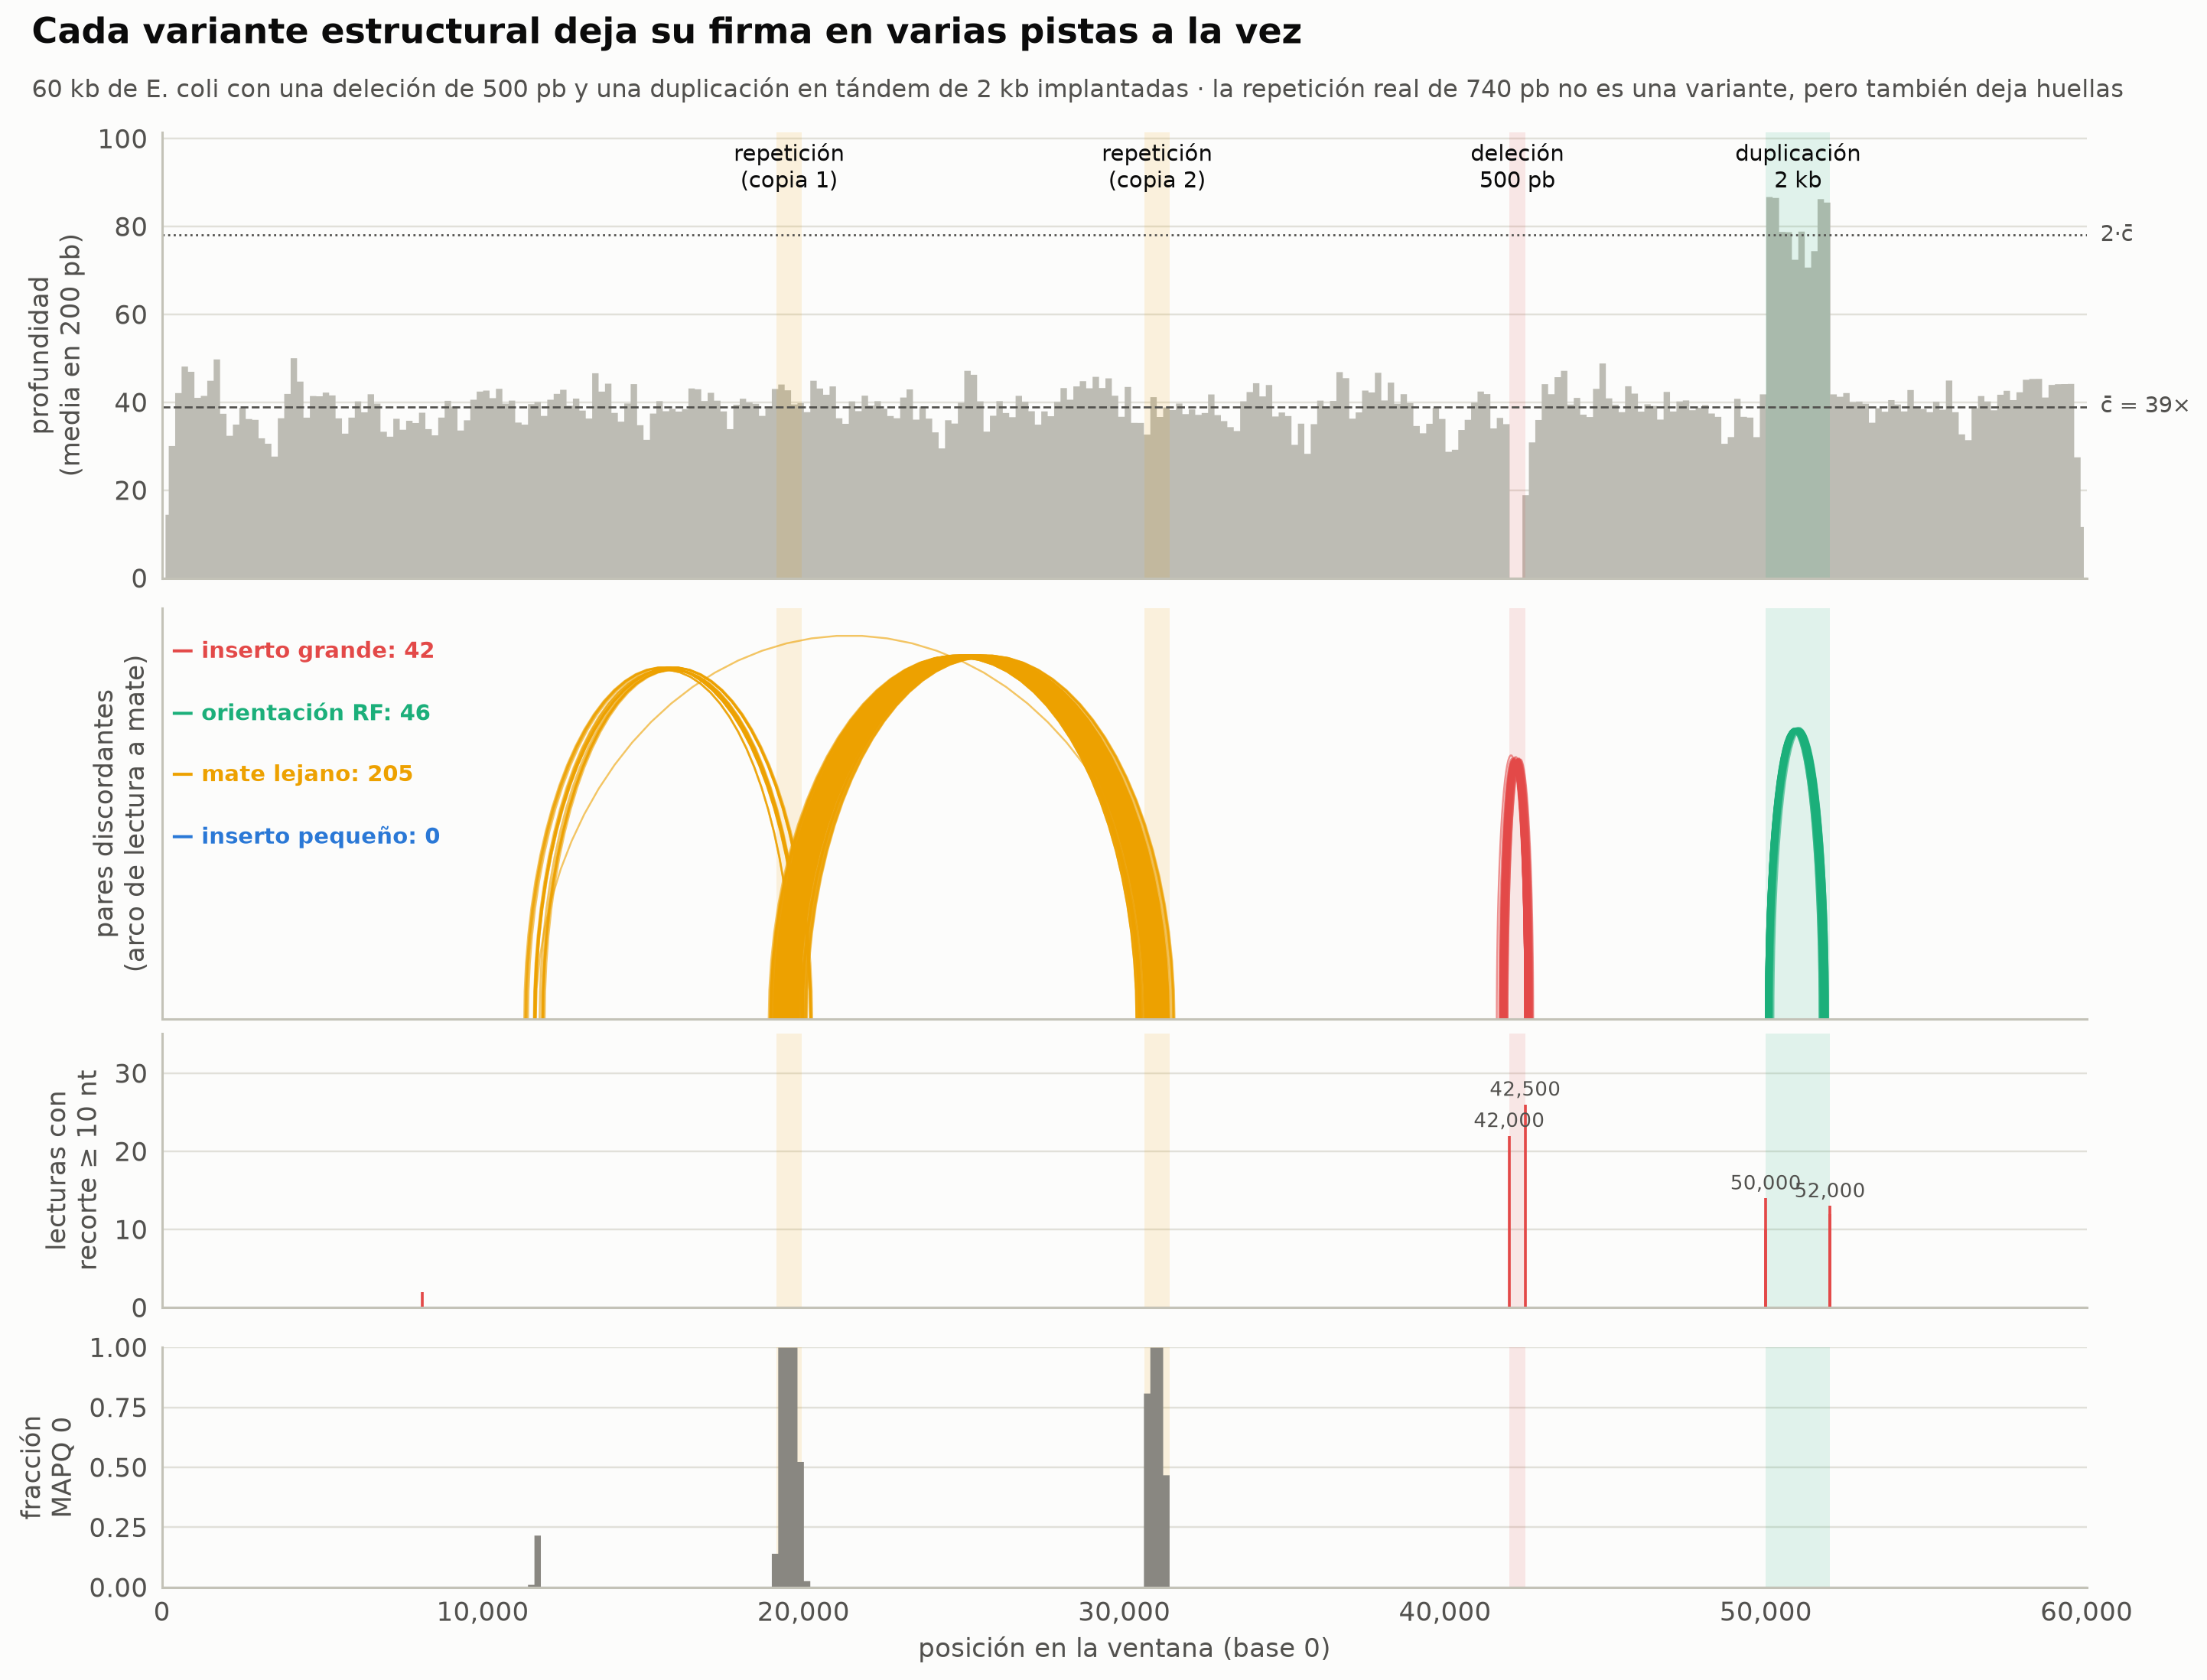

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(13, 9.2), sharex=True, gridspec_kw=dict(height_ratios=[1.3, 1.2, 0.8, 0.7]))
ax = axes[0]
ax.fill_between(bin_x, cov_bin, step="mid", color="#bdbcb4", lw=0)
ax.axhline(c_bar, color=ec.INK_2, lw=0.9, ls="--"); ax.axhline(2 * c_bar, color=ec.INK_2, lw=0.9, ls=":")
ax.text(REF_LEN, c_bar, f"  c̄ = {c_bar:.0f}×", va="center", fontsize=9.5, color=ec.INK_2)
ax.text(REF_LEN, 2 * c_bar, "  2·c̄", va="center", fontsize=9.5, color=ec.INK_2)
ax.set_ylabel("profundidad\n(media en 200 pb)"); ax.set_ylim(0, 2.6 * c_bar)
events = [(BIGDEL, "deleción\n500 pb", ec.RED), (DUP, "duplicación\n2 kb", ec.AQUA), (REPEAT[0], "repetición\n(copia 1)", ec.YELLOW),
          (REPEAT[1], "repetición\n(copia 2)", ec.YELLOW)]
for (a, b), lab, col in events:
    for axx in axes:
        axx.axvspan(a, b, color=col, alpha=0.12, lw=0)
    ax.text((a + b) / 2, 2.55 * c_bar, lab, ha="center", va="top", fontsize=9.5, color=ec.INK)
ax = axes[1]
for r in disc.itertuples():
    a, b = sorted((r.pos, r.mpos))
    t = np.linspace(0, np.pi, 40)
    ax.plot(a + (b - a) * (1 - np.cos(t)) / 2, np.sin(t) * np.log10(b - a + 10), color=PAIR_COLORS[r.pair], lw=0.8,
            alpha=0.6)
ax.set_ylabel("pares discordantes\n(arco de lectura a mate)"); ax.set_ylim(0, 4.6); ax.set_yticks([])
for k, (lab, col) in enumerate(PAIR_COLORS.items()):
    n = int((disc["pair"] == lab).sum())
    ax.text(0.005, 0.92 - 0.15 * k, f"— {lab}: {n}", transform=ax.transAxes, color=col, fontsize=9.5,
            fontweight="bold", va="top")
ax = axes[2]
ax.vlines(clip_x, 0, clip_n, color=ec.RED, lw=1.2)
ax.set_ylabel("lecturas con\nrecorte ≥ 10 nt")
labeled = []                                   # una etiqueta por borde (picos a < 100 pb se agrupan)
for p in sorted([x for x in clip_x if clips[x] >= 5], key=lambda x: -clips[x]):
    if all(abs(p - q) > 100 for q in labeled):
        labeled.append(p)
        ax.text(p, clips[p] + 0.5, f"{p:,}", ha="center", va="bottom", fontsize=8.5, color=ec.INK_2)
ax.set_ylim(0, clip_n.max() * 1.35)
ax = axes[3]
ax.fill_between(bin_x, mq0_bin.to_numpy(), step="mid", color=ec.MUTED, lw=0)
ax.set_ylabel("fracción\nMAPQ 0"); ax.set_ylim(0, 1)
ax.set_xlim(0, REF_LEN); ax.set_xlabel("posición en la ventana (base 0)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ec.fig_title(fig, "Cada variante estructural deja su firma en varias pistas a la vez",
             "60 kb de E. coli con una deleción de 500 pb y una duplicación en tándem de 2 kb implantadas · "
             "la repetición real de 740 pb no es una variante, pero también deja huellas")
plt.show()

> 🔎 **Qué observamos.** Las cuatro pistas cuentan la misma historia desde ángulos distintos:
>
> * **Deleción (rojo):** la profundidad cae a 0; los arcos rojos saltan por encima del hueco (pares con inserto
>   grande); y dos picos de recortes marcan **al par de bases** los bordes, 42 000 y 42 500.
> * **Duplicación (aqua):** la profundidad se **duplica** entre 50 000 y 52 000; los arcos aqua conectan el final de
>   la región con su principio (orientación RF), y los recortes se acumulan en ambos bordes.
> * **Repetición (amarillo):** la profundidad apenas cambia, pero la fracción de MAPQ 0 se dispara y aparecen arcos
>   amarillos de ~11.5 kb entre las dos copias (y algunos más desde otra repetición corta, hacia la posición
>   11 700). No es una variante: es **ambigüedad de mapeo**. Una SV "detectada"
>   sólo con pares que caen en repeticiones es una de las fuentes más comunes de falsos positivos.

Ahora medimos, con las fórmulas del ejemplo a mano:

In [31]:
normal = pairs_df.loc[pairs_df["proper"], "tlen"].abs()
del_pairs = disc[disc["pair"] == "inserto grande"]
def near(lo, hi, min_gap=50):
    """Puntos de ruptura: en cada grupo de recortes cercanos, la posición más votada."""
    pts = [p for p in clip_x if lo <= p <= hi and clips[p] >= 3]
    groups, out = [], []
    for p in pts:
        if groups and p - groups[-1][-1] <= min_gap:
            groups[-1].append(p)
        else:
            groups.append([p])
    return [max(g, key=lambda q: clips[q]) for g in groups]
del_bp, dup_bp = near(41_500, 43_000), near(49_500, 52_500)
cn_dup = 2 * depth[DUP[0]:DUP[1]].mean() / c_bar
est = pd.DataFrame([
    ("deleción", "TLEN discordantes − TLEN normales", f"{del_pairs['tlen'].abs().mean() - normal.mean():.0f} pb",
     f"{BIGDEL[1] - BIGDEL[0]} pb"),
    ("deleción", "bordes por recortes", " y ".join(f"{p:,}" for p in del_bp) + f" → {del_bp[-1] - del_bp[0]} pb",
     f"{BIGDEL[0]:,} y {BIGDEL[1]:,}"),
    ("deleción", "profundidad dentro", f"{depth[BIGDEL[0]:BIGDEL[1]].mean():.2f}×", "0× (homocigota)"),
    ("duplicación", "bordes por recortes", " y ".join(f"{p:,}" for p in dup_bp) + f" → {dup_bp[-1] - dup_bp[0]:,} pb",
     f"{DUP[0]:,} y {DUP[1]:,}"),
    ("duplicación", "número de copias 2·c̄_W/c̄", f"{cn_dup:.2f}", "4 (2 por haplotipo)"),
], columns=["evento", "señal", "estimación", "verdad implantada"])
print(f"Pares normales: TLEN = {normal.mean():.0f} ± {normal.std():.0f} pb · pares que cruzan la deleción: "
      f"{len(del_pairs)}, TLEN = {del_pairs['tlen'].abs().mean():.0f} pb")
est

Pares normales: TLEN = 350 ± 34 pb · pares que cruzan la deleción: 42, TLEN = 860 pb


,evento,señal,estimación,verdad implantada
0,deleción,TLEN discordantes − TLEN normales,510 pb,500 pb
1,deleción,bordes por recortes,"42,000 y 42,500 → 500 pb","42,000 y 42,500"
2,deleción,profundidad dentro,0.03×,0× (homocigota)
3,duplicación,bordes por recortes,"50,000 y 52,000 → 2,000 pb","50,000 y 52,000"
4,duplicación,número de copias 2·c̄_W/c̄,4.10,4 (2 por haplotipo)


> 🔎 **Qué observamos.** Los recortes dan los puntos de ruptura **exactos**; el tamaño de inserto da una
> estimación del tamaño con un error de unas decenas de pb (la dispersión de los insertos, dividida por la raíz del
> número de pares); la profundidad da el número de copias. Así combinan las señales programas como DELLY, LUMPY o
> Manta. Veamos las dos SV con nuestra vista estilo IGV, **coloreando los pares** por tamaño de inserto y orientación:

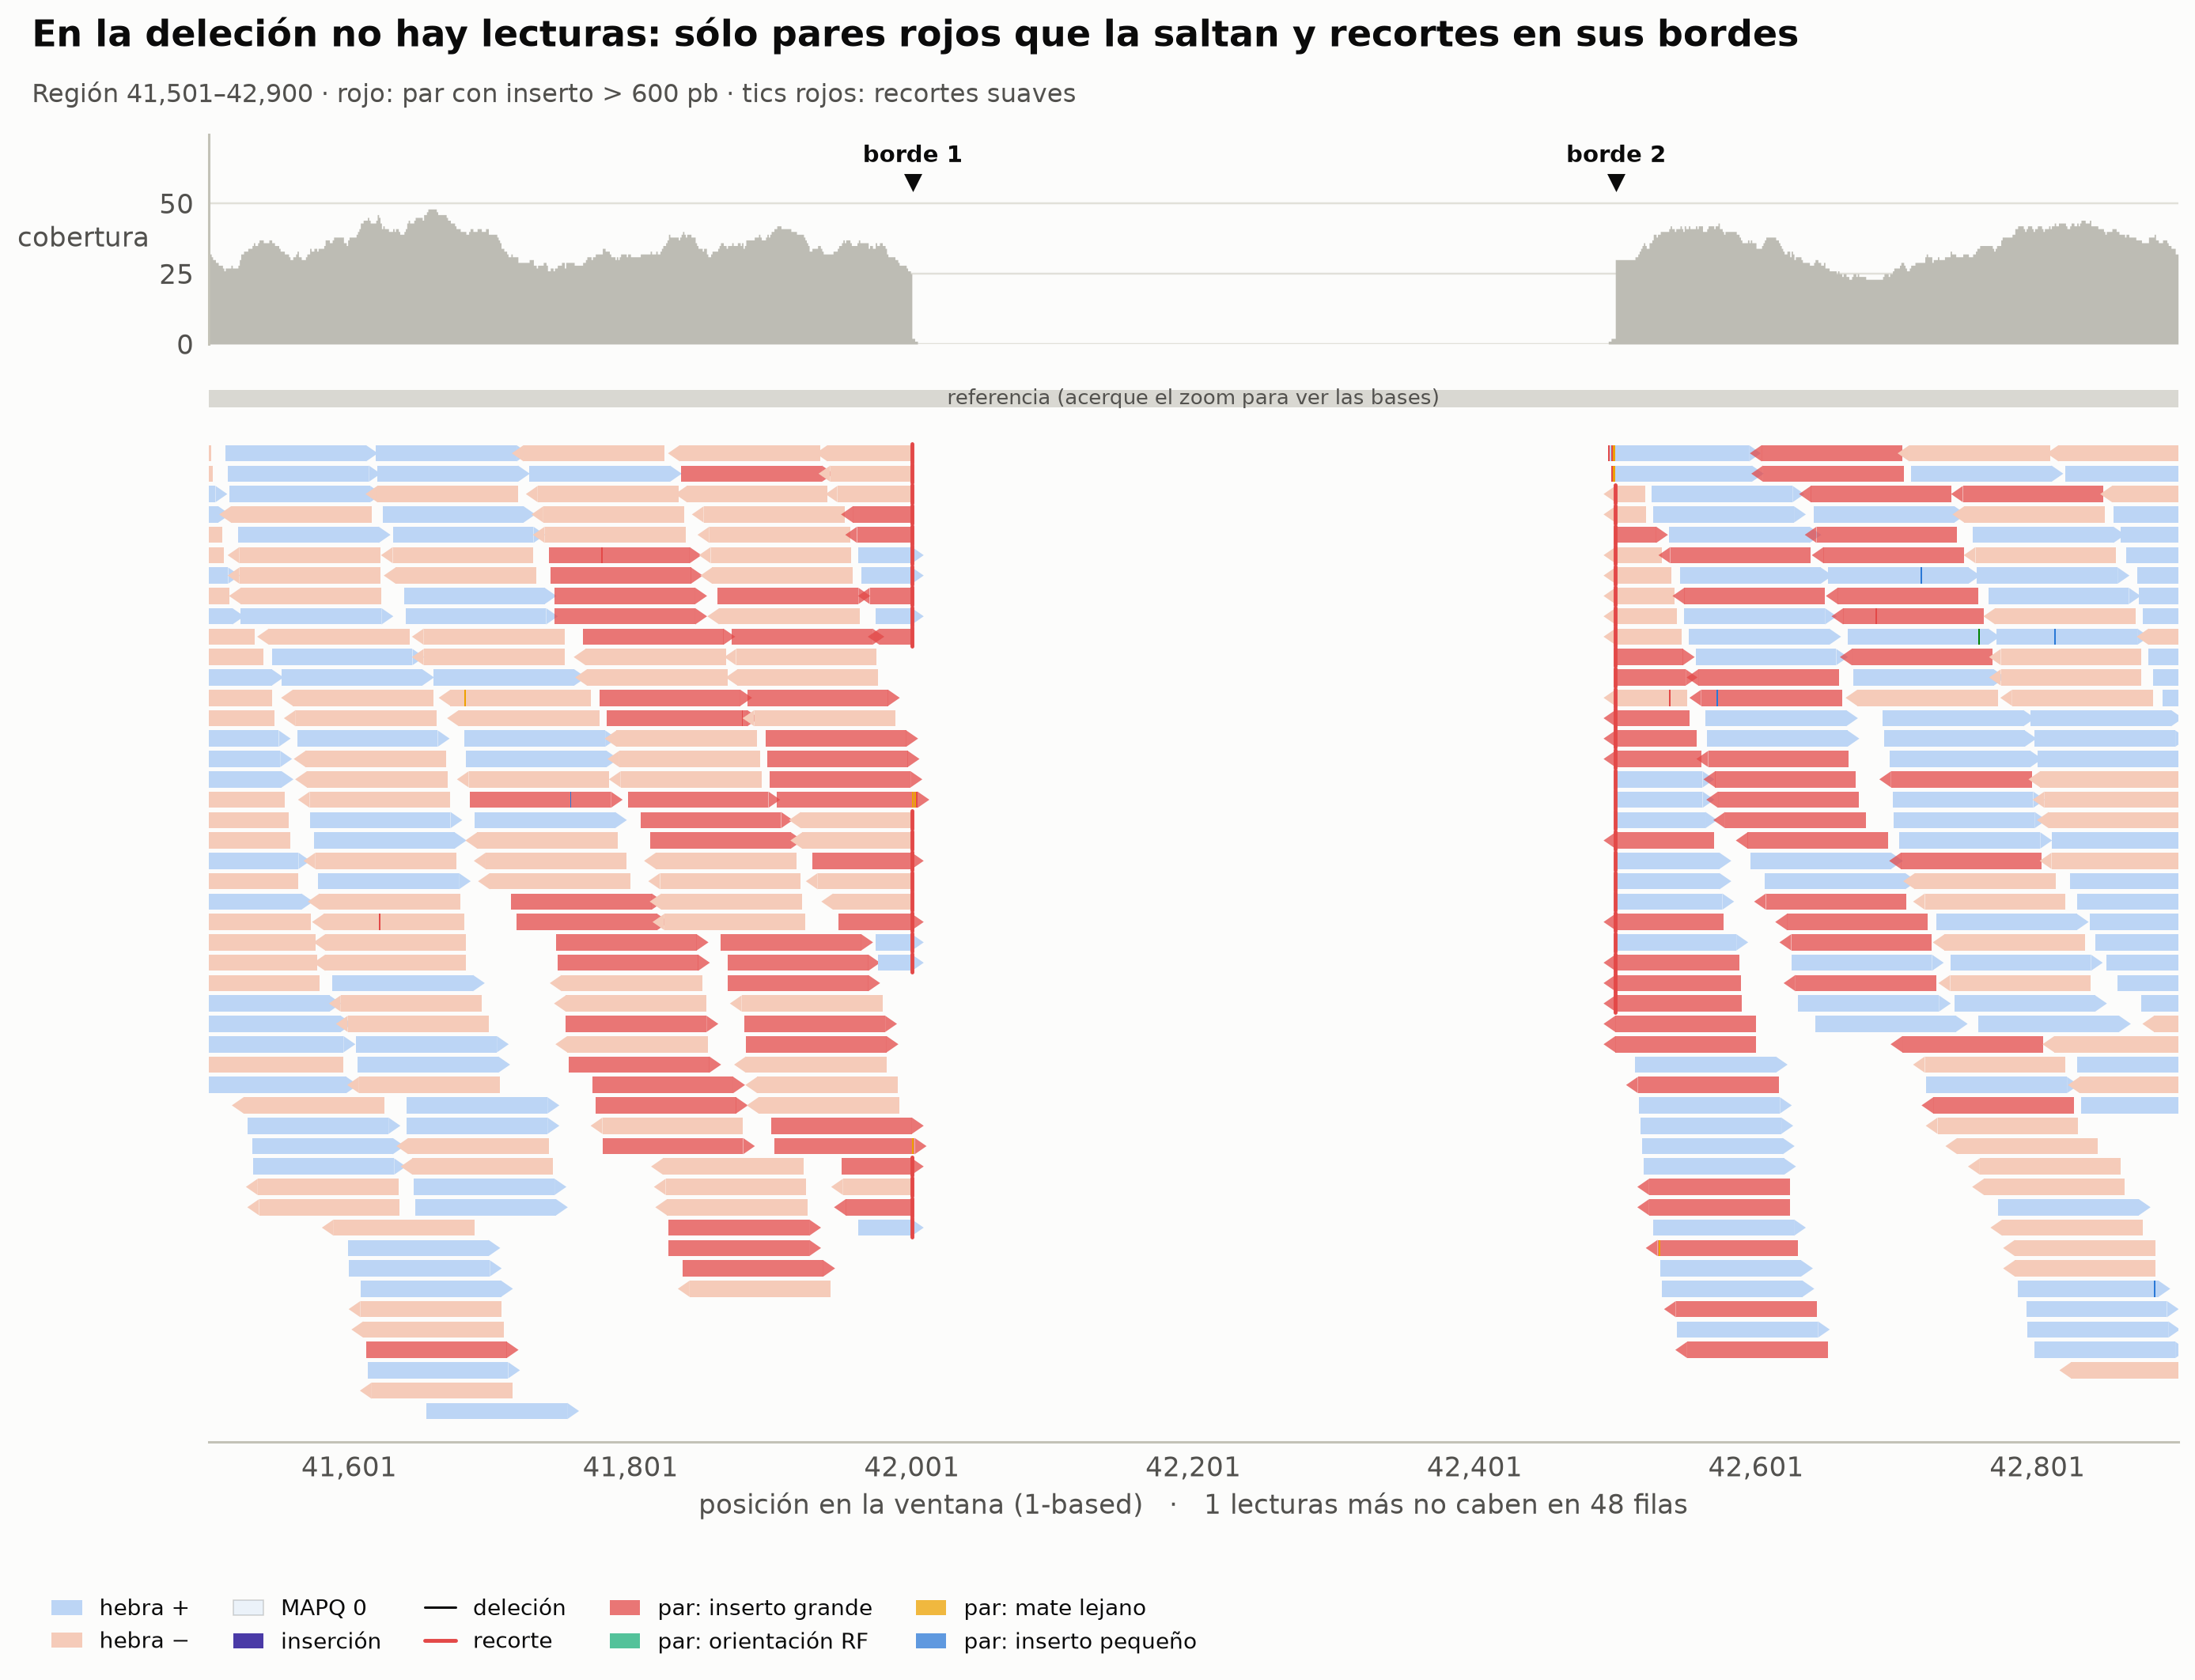

In [32]:
fig = igv_view(BIGDEL[0] - 500, BIGDEL[1] + 400,
               "En la deleción no hay lecturas: sólo pares rojos que la saltan y recortes en sus bordes",
               f"Región {BIGDEL[0] - 499:,}–{BIGDEL[1] + 400:,} · rojo: par con inserto > 600 pb · tics rojos: recortes suaves",
               color_pairs=True, max_rows=48, marks=[(BIGDEL[0], "borde 1"), (BIGDEL[1], "borde 2")])
plt.show()

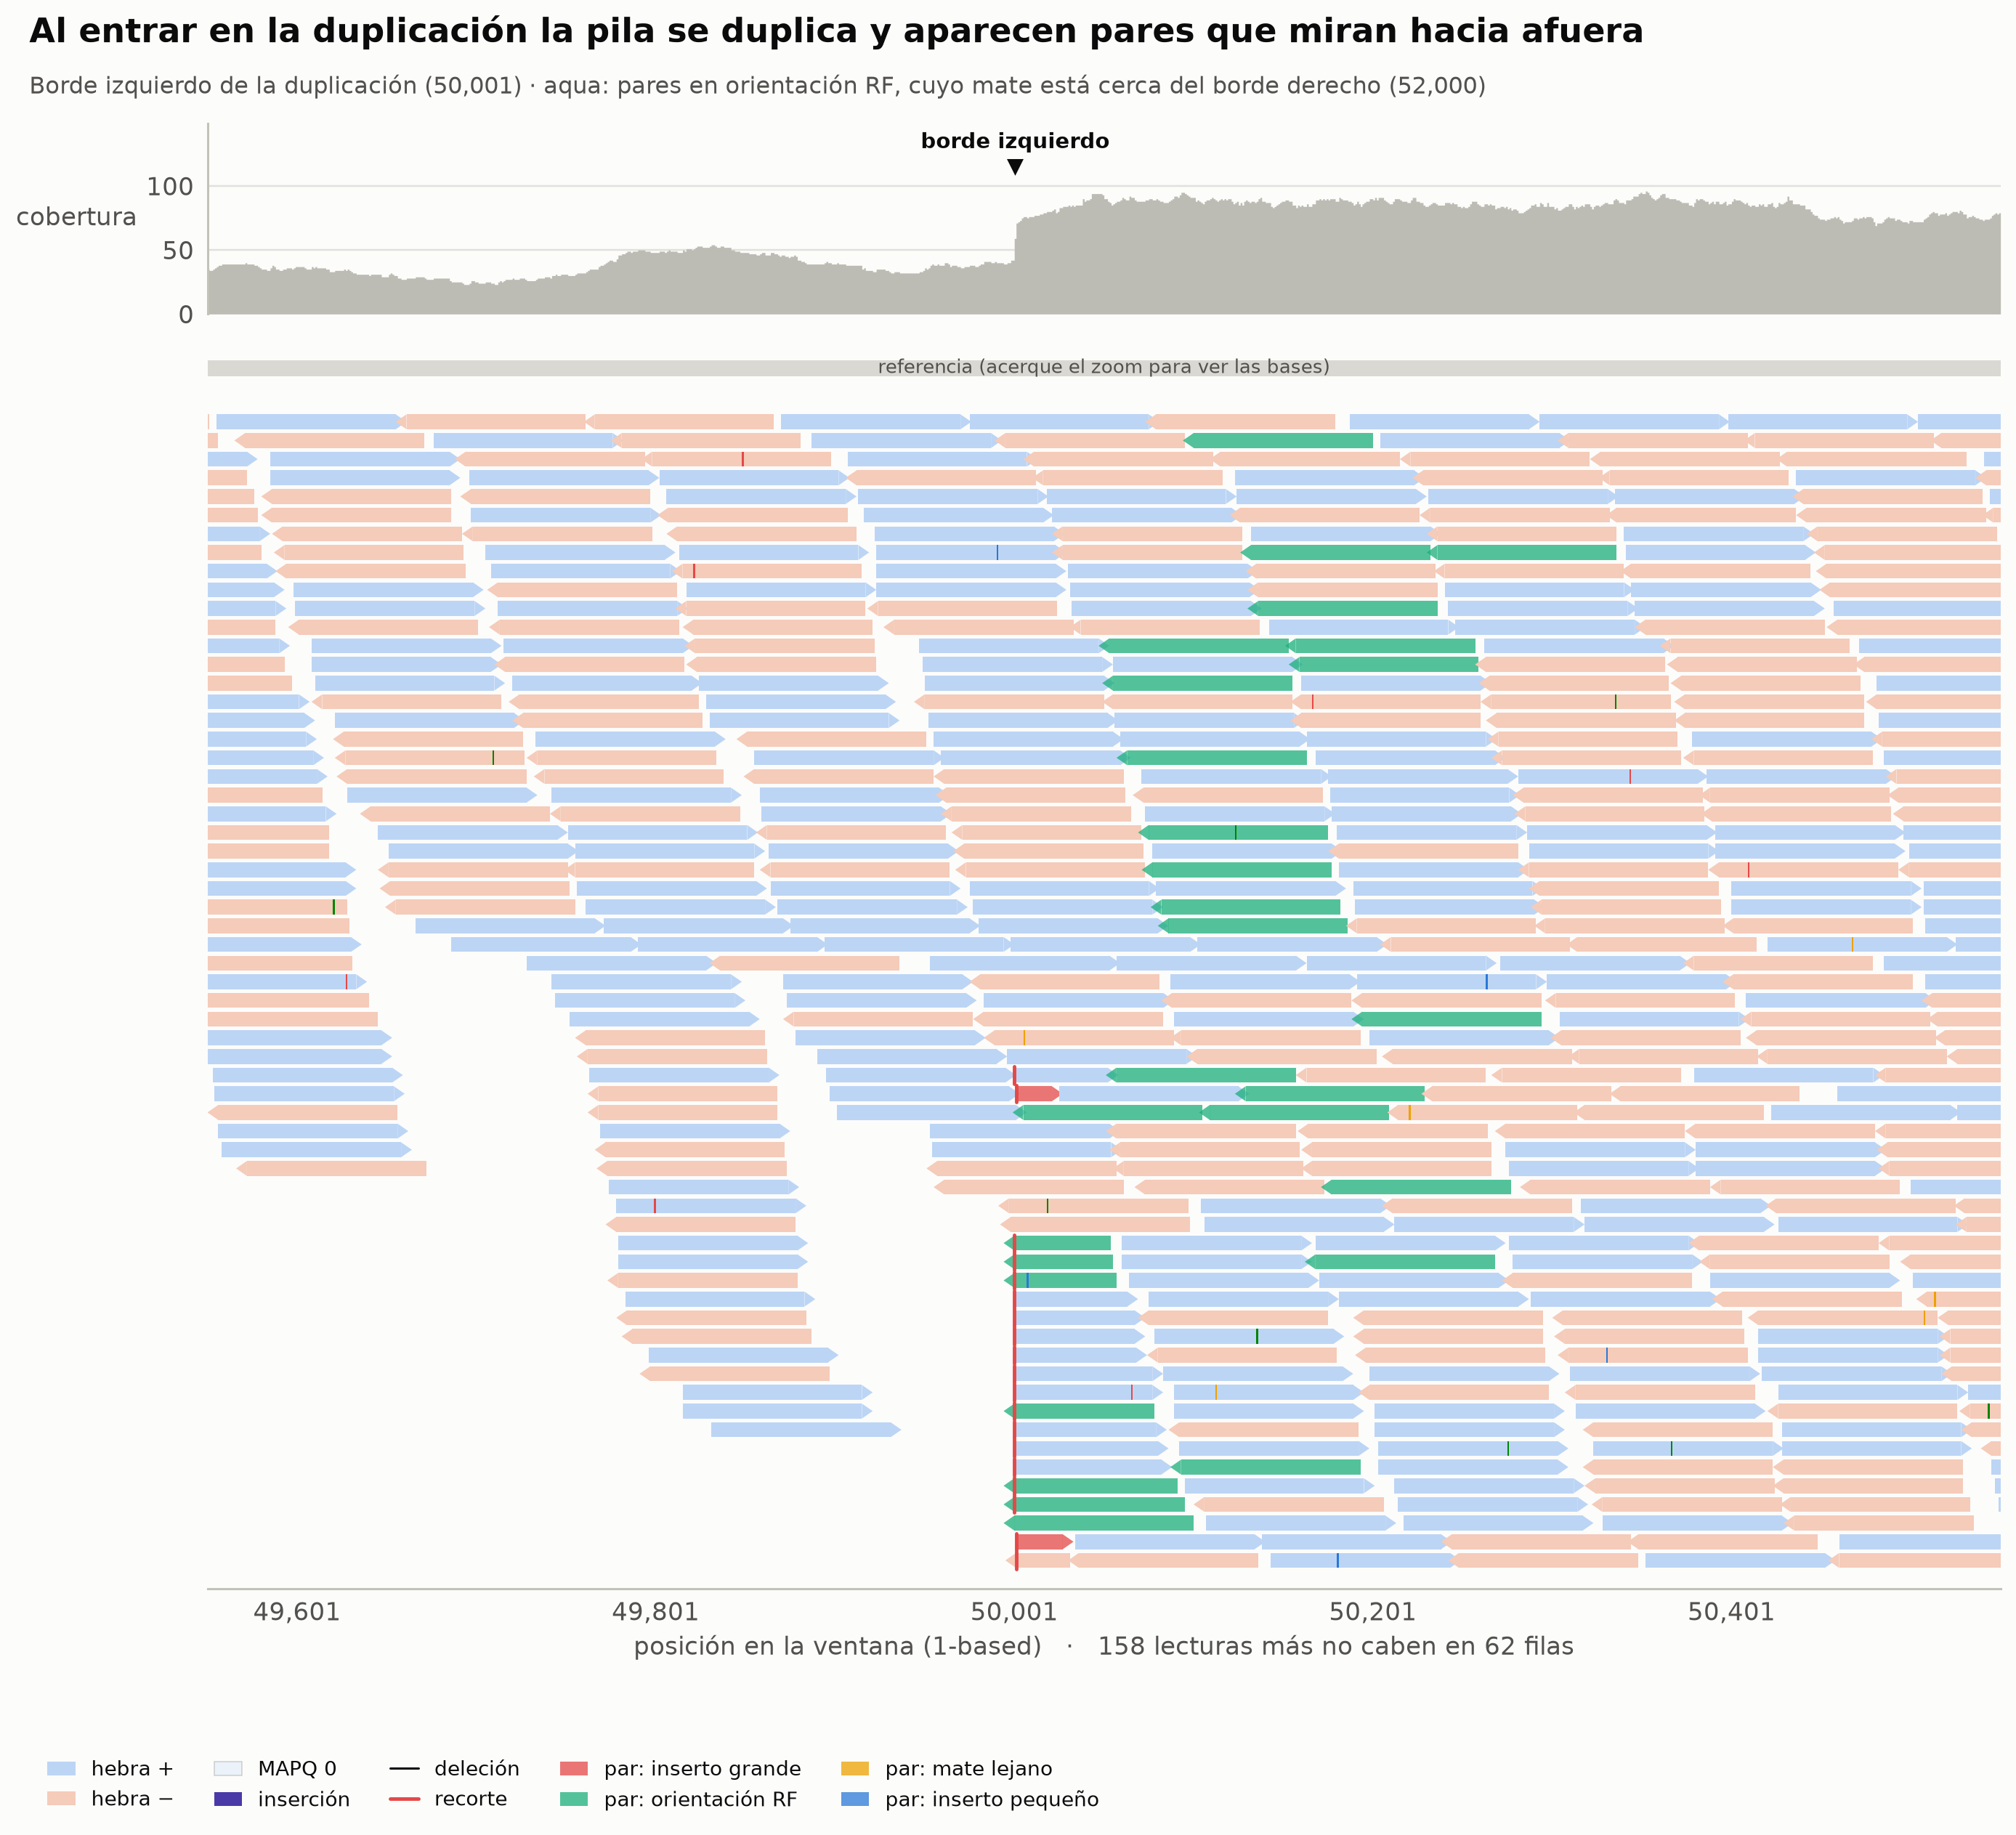

In [33]:
fig = igv_view(DUP[0] - 450, DUP[0] + 550,
               "Al entrar en la duplicación la pila se duplica y aparecen pares que miran hacia afuera",
               f"Borde izquierdo de la duplicación ({DUP[0] + 1:,}) · aqua: pares en orientación RF, cuyo mate está cerca "
               f"del borde derecho ({DUP[1]:,})", color_pairs=True, max_rows=62, marks=[(DUP[0], "borde izquierdo")])
plt.show()

> 🔎 **Qué observamos.** En la deleción, la pila de lecturas termina de golpe en ambos bordes; las lecturas que
> llegan al borde llevan un tic rojo (el resto de la lectura está al otro lado del hueco, como alineamiento
> suplementario) y los pares rojos cruzan por encima. En la duplicación, la pila pasa de ~40 a ~80 lecturas justo en el
> borde, y las lecturas aqua (hebra −, al principio de la región) tienen a su mate **a la derecha**, cerca del final
> de la región: la orientación RF de la unión en tándem.

### 🎛️ Tamaño de inserto a lo largo de la ventana

Cada punto es un par, colocado en la posición de su lectura izquierda y a la altura de su tamaño de inserto (escala
logarítmica). Pase el ratón por los puntos que se salen de la banda para ver el nombre del par, su CIGAR y la
posición del mate.

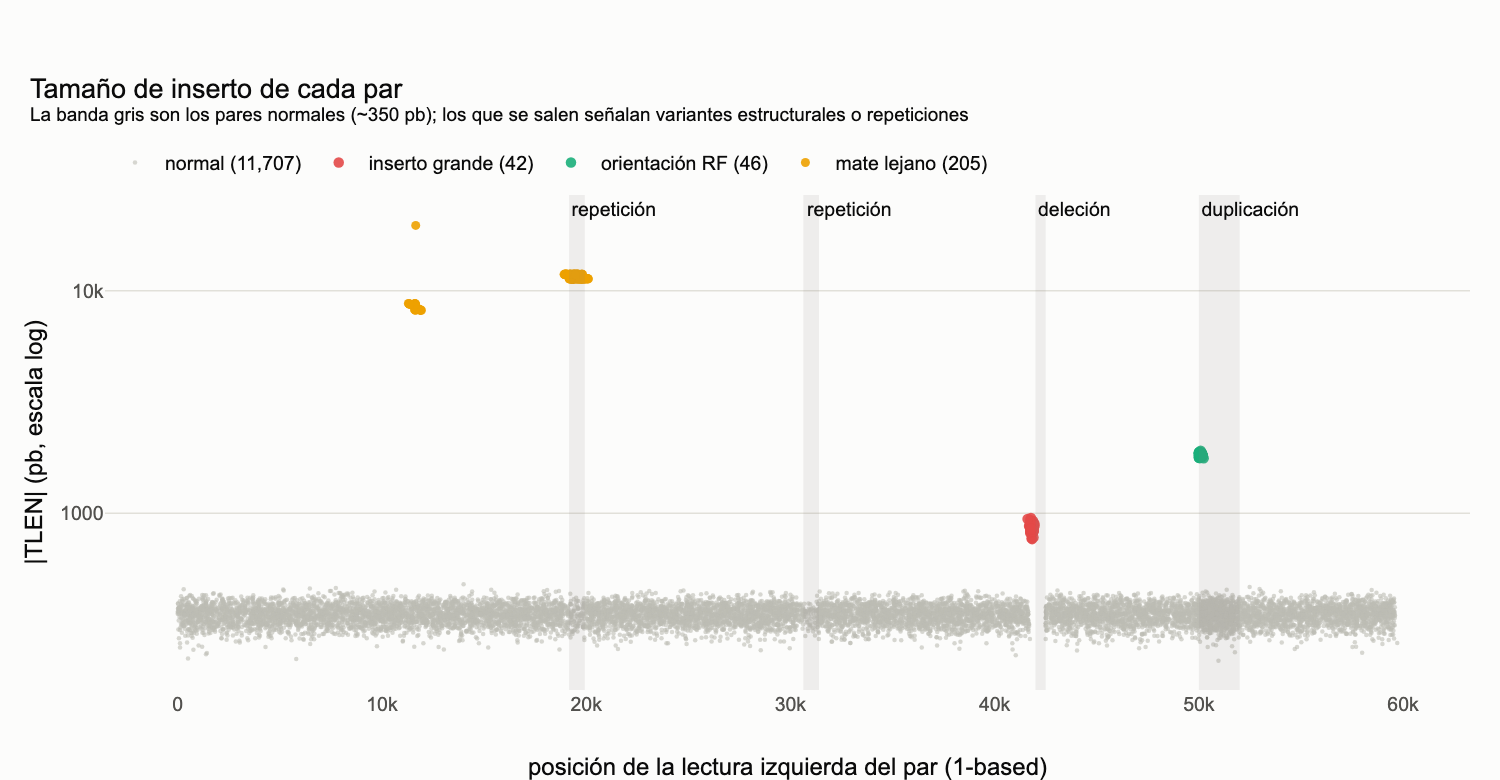

In [34]:
fig = go.Figure()
for lab, col, size in [("normal", "#bdbcb4", 3), ("inserto pequeño", ec.BLUE, 6), ("inserto grande", ec.RED, 7),
                       ("orientación RF", ec.AQUA, 7), ("mate lejano", ec.YELLOW, 6)]:
    g = pairs_df[pairs_df["pair"] == lab]
    g = g[g["tlen"] != 0]
    fig.add_trace(go.Scatter(x=g["pos"] + 1, y=g["tlen"].abs(), mode="markers", name=f"{lab} ({len(g):,})",
                             marker=dict(size=size, color=col, opacity=0.6 if lab == "normal" else 0.9),
                             hovertext=[f"<b>{r.qname}</b> · {lab}<br>lectura en {r.pos + 1:,} ({r.strand}) · "
                                        f"CIGAR {r.cigar_s}<br>mate en {r.mpos + 1:,} ({r.mstrand}) · |TLEN| = {abs(r.tlen):,}"
                                        for r in g.itertuples()], hoverinfo="text"))
for (a, b), lab in [(BIGDEL, "deleción"), (DUP, "duplicación"), (REPEAT[0], "repetición"), (REPEAT[1], "repetición")]:
    fig.add_vrect(x0=a, x1=b, fillcolor=ec.MUTED, opacity=0.12, line_width=0, annotation_text=lab,
                  annotation_position="top left")
fig.update_yaxes(type="log", dtick=1, title="|TLEN| (pb, escala log)")
fig.update_xaxes(title="posición de la lectura izquierda del par (1-based)")
fig.update_layout(height=520, title="Tamaño de inserto de cada par<br><sup>La banda gris son los pares normales "
                  "(~350 pb); los que se salen señalan variantes estructurales o repeticiones</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=70, r=20, b=60))
fig.show()

## 9. La cobertura como señal: profundidad por base y el algoritmo de `mosdepth`

Hasta ahora hemos usado la pista de cobertura "a ojo". En la Lección 6.3 la cobertura era un **promedio** para todo el
genoma ($\bar c = 30\times$, por ejemplo); para encontrar una deleción la necesitamos **posición a posición**, y
calcularla bien y rápido es menos trivial de lo que parece.

Piense en un contador de tráfico a lo largo de una carretera. La forma ingenua de saber cuántos coches pasaron por cada
kilómetro es seguir a cada coche y anotar una raya en cada kilómetro que recorre: el trabajo crece con el número de
coches **por** la longitud de su recorrido. La forma inteligente es anotar sólo dos cosas por coche, dónde **entró**
(+1) y dónde **salió** (−1), y después recorrer la carretera una sola vez llevando la cuenta acumulada: en cada punto,
los que han entrado menos los que han salido son los que están ahí. Es el mismo razonamiento del portero de una
discoteca, que sabe cuánta gente hay dentro sin contar cabezas.

En la práctica esto importa mucho. Un laboratorio clínico que secuencia el genoma de un paciente a $30\times$ con lecturas
de 150 pb tiene unos $6\times10^{8}$ alineamientos; contarlos base a base son unos $10^{11}$ incrementos por muestra.

### La definición formal

Una lectura no cubre siempre un intervalo continuo: una deleción (`D`) o un intrón (`N`) en su CIGAR la parten en
**bloques**. Sólo las bases alineadas (`M`, `=`, `X`) cuentan; las `I` y los recortes `S`/`H` no ocupan posiciones de la
referencia (ecuación 07-profundidad del libro):

$$
c(x) = \sum_{a\in\mathcal{A}}\;\sum_{[s,e)\in B(a)} \mathbb{1}\big[s\le x<e\big]
$$

| Símbolo | Significado |
|---|---|
| $c(x)$ | número de lecturas filtradas que cubren la posición $x$ con una base alineada |
| $\mathcal{A}$ | alineamientos que se cuentan (p. ej., primarios, no duplicados y con MAPQ ≥ 20); los filtros cambian mucho el resultado en repeticiones |
| $B(a)$ | bloques de referencia del alineamiento $a$: sus operaciones `M`, `=` o `X` |
| $[s,e)$ | bloque **semiabierto** de posiciones cubierto sin interrupción; una deleción o un intrón parten un alineamiento en varios bloques |
| $\mathbb{1}[\cdot]$ | indicador: 1 si la condición se cumple, 0 si no |

Calcular esa suma de forma directa cuesta $O\big(\sum_a |a|\big)$: proporcional a la profundidad. Pedersen y Quinlan
(2018) observaron en `mosdepth` que basta con anotar dónde **empieza** y dónde **termina** cada bloque en un **arreglo de
diferencias** $\delta$ del tamaño del cromosoma y reconstruir la profundidad con una suma acumulada (ecuación
07-mosdepth del libro):

$$
\delta(s) \mathrel{+}= 1,\quad \delta(e) \mathrel{-}= 1 \quad\text{para cada bloque }[s,e),\qquad
c(x) = \sum_{y\le x}\delta(y)
$$

| Símbolo | Significado |
|---|---|
| $\delta$ | arreglo de diferencias, de longitud $G + 1$ (una casilla extra para el final del último bloque) |
| $N$, $G$ | número de bloques y longitud del cromosoma; el coste pasa a ser $O(N + G)$, **sin importar la profundidad** |

### Ejemplo a mano (el del libro)

Catorce posiciones (0 a 13) y cuatro lecturas. La lectura 2 lleva una deleción y aporta **dos** bloques:

| lectura | bloques $[s,e)$ | anotaciones en $\delta$ |
|---|---|---|
| 1 | $[1,7)$ | $+1$ en 1, $-1$ en 7 |
| 2 | $[3,6)$ y $[8,12)$ (deleción en 6–7) | $+1$ en 3, $-1$ en 6, $+1$ en 8, $-1$ en 12 |
| 3 | $[5,11)$ | $+1$ en 5, $-1$ en 11 |
| 4 | $[9,14)$ | $+1$ en 9, $-1$ en 14 (fuera de la ventana) |

| posición $x$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| $\delta(x)$ | 0 | +1 | 0 | +1 | 0 | +1 | −1 | −1 | +1 | +1 | 0 | −1 | −1 | 0 |
| $c(x)=\sum_{y\le x}\delta(y)$ | 0 | 1 | 1 | 2 | 2 | 3 | 2 | 1 | 2 | 3 | 3 | 2 | 1 | 1 |

Compruebe una columna: en $x = 7$ están la lectura 1 (no: termina en 6), la 2 (no: está en su deleción) y la 3 (sí),
así que $c(7) = 1$, y la suma acumulada da $0+1+0+1+0+1-1-1 = 1$. ✔️ Si esto le recuerda a la función `max_depth` de la
sección 5, no es casualidad: aquel barrido de eventos $+1/-1$ ordenados es la versión "dispersa" del mismo truco.

In [35]:
def ref_blocks(pos, cigar):
    """Bloques [s, e) de referencia cubiertos por bases alineadas (M, =, X), en base 0 (equivalente a pysam.get_blocks()).
    D y N avanzan en la referencia sin cubrirla; I, S y H no la consumen."""
    blocks, j = [], pos
    for op, l in cigar:
        if op in "M=X":
            if blocks and blocks[-1][1] == j:        # dos M seguidas (p. ej. 30M2I40M): un solo bloque
                blocks[-1] = (blocks[-1][0], j + l)
            else:
                blocks.append((j, j + l))
            j += l
        elif op in "DN":
            j += l
    return blocks

def depth_naive(blocks_per_read, G):
    """Ecuación 07-profundidad al pie de la letra: un incremento por cada base de cada bloque. Coste O(Σ|a|)."""
    c = [0] * G
    for blocks in blocks_per_read:
        for s, e in blocks:
            for x in range(s, min(e, G)):
                c[x] += 1
    return np.array(c)

def depth_diff(blocks_per_read, G):
    """Ecuación 07-mosdepth: +1 al inicio y −1 al final de cada bloque, y una suma acumulada. Coste O(N + G)."""
    d = [0] * (G + 1)
    for blocks in blocks_per_read:
        for s, e in blocks:
            d[s] += 1
            d[min(e, G)] -= 1
    return np.cumsum(d[:-1])

# El ejemplo del libro: 14 posiciones, cuatro lecturas (la 2 con una deleción de 2 pb)
book_reads = {"lectura 1": [("M", 6)], "lectura 2": [("M", 3), ("D", 2), ("M", 4)],
              "lectura 3": [("M", 6)], "lectura 4": [("M", 5)]}
book_pos = {"lectura 1": 1, "lectura 2": 3, "lectura 3": 5, "lectura 4": 9}
book_blocks = [ref_blocks(book_pos[k], c) for k, c in book_reads.items()]
delta_book = np.zeros(15, int)
for blocks in book_blocks:
    for s, e in blocks:
        delta_book[s] += 1; delta_book[e] -= 1
print("bloques:", book_blocks)
print("δ =", delta_book[:-1].tolist())
print("c =", depth_diff(book_blocks, 14).tolist())
print("¿Igual al conteo ingenuo?", np.array_equal(depth_diff(book_blocks, 14), depth_naive(book_blocks, 14)))

bloques: [[(1, 7)], [(3, 6), (8, 12)], [(5, 11)], [(9, 14)]]
δ = [0, 1, 0, 1, 0, 1, -1, -1, 1, 1, 0, -1, -1, 0]
c = [0, 1, 1, 2, 2, 3, 2, 1, 2, 3, 3, 2, 1, 1]
¿Igual al conteo ingenuo? True


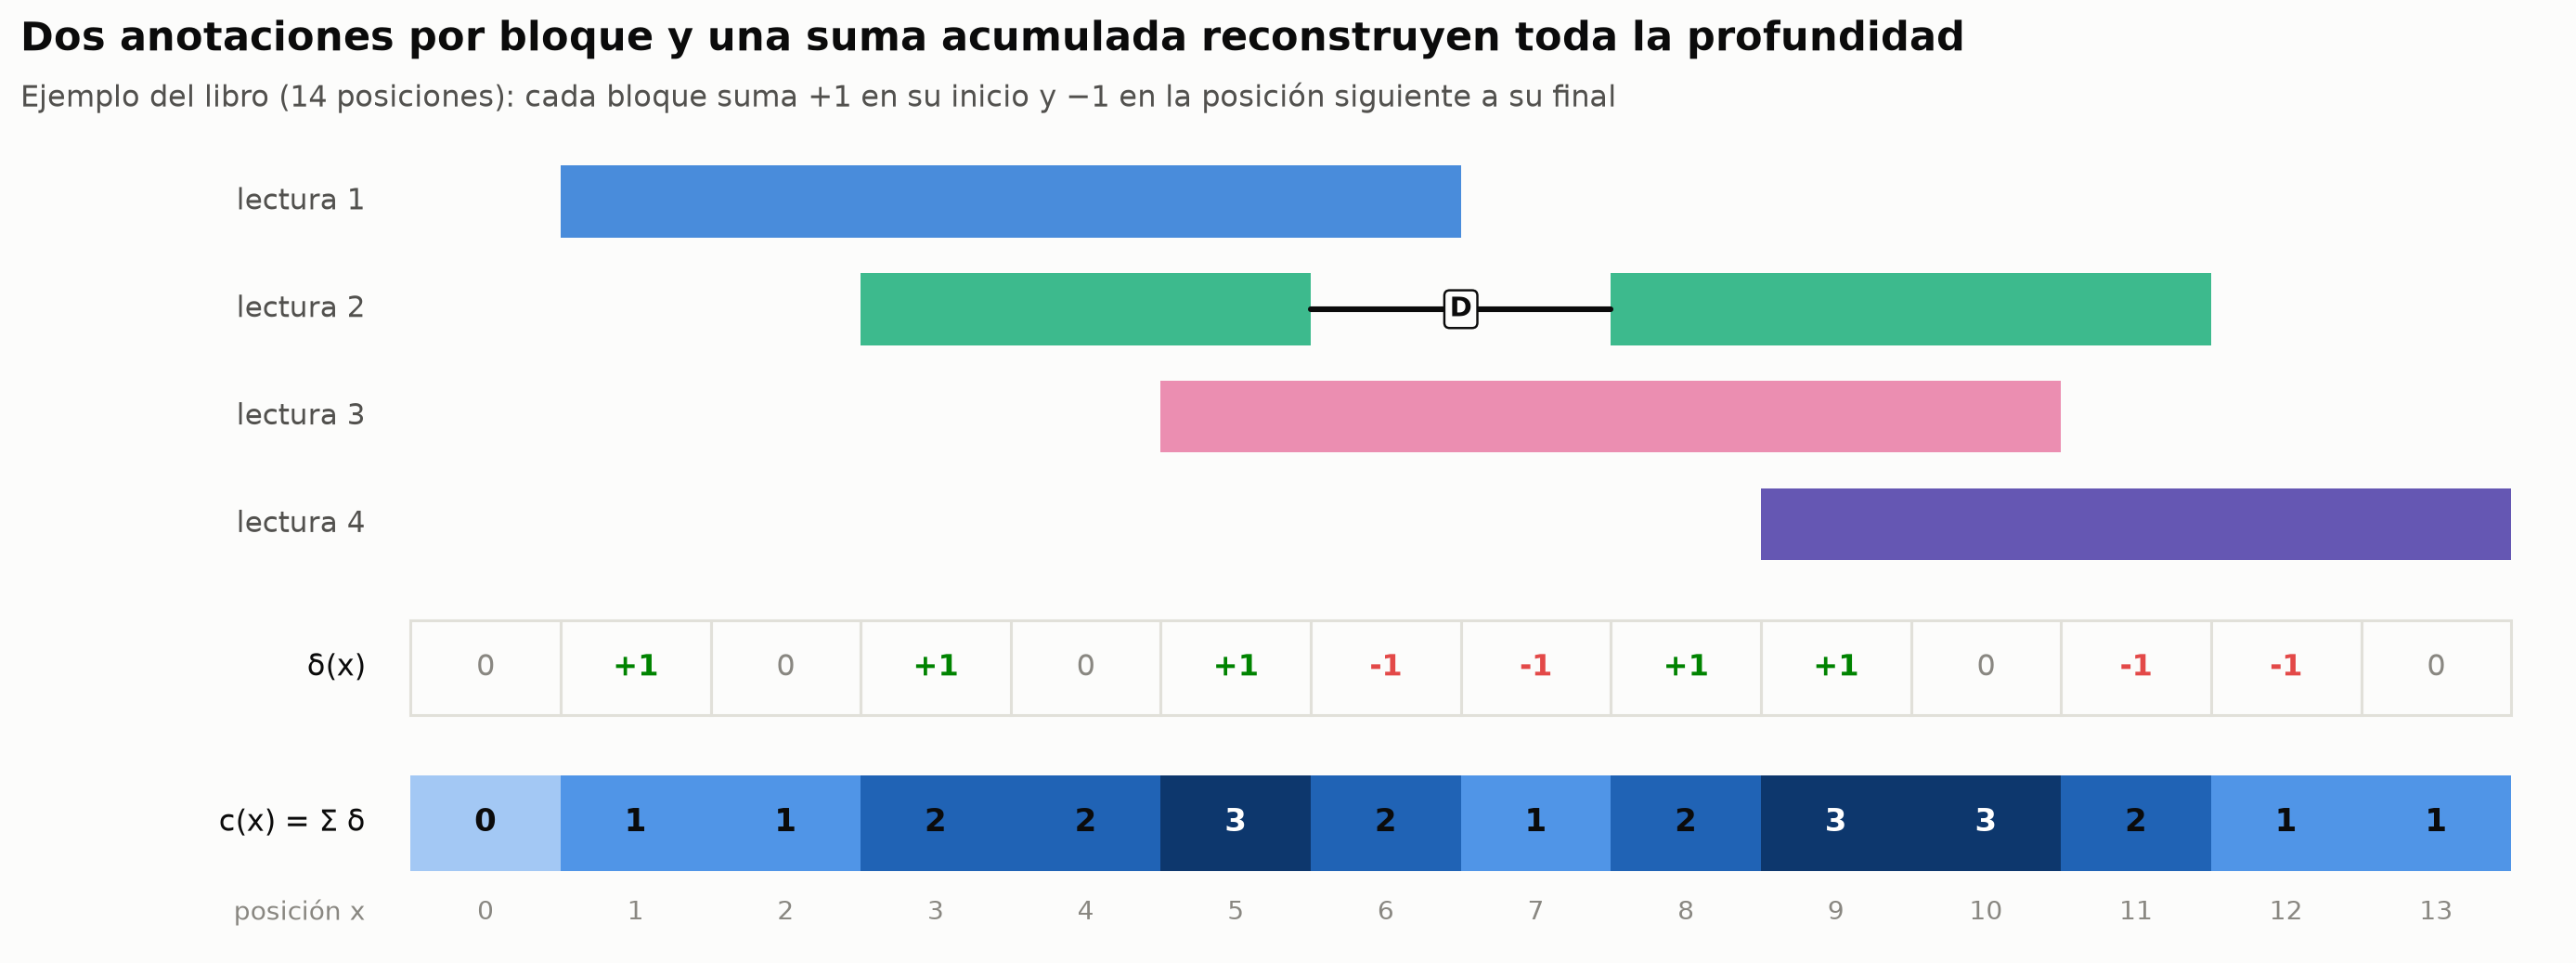

In [36]:
fig, ax = plt.subplots(figsize=(12.5, 4.6))
tones = [ec.BLUE, ec.AQUA, ec.MAGENTA, ec.VIOLET]
for k, (blocks, col) in enumerate(zip(book_blocks, tones)):
    y = 6.2 - 0.9 * k
    for s, e in blocks:
        ax.add_patch(Rectangle((s, y - 0.3), e - s, 0.6, color=col, alpha=0.85, lw=0))
    if len(blocks) > 1:
        ax.plot([blocks[0][1], blocks[1][0]], [y, y], color=ec.INK, lw=2)
        ax.text((blocks[0][1] + blocks[1][0]) / 2, y, "D", ha="center", va="center", fontsize=9.5, color=ec.INK,
                fontweight="bold", bbox=dict(boxstyle="round,pad=0.2", fc=ec.SURFACE, ec=ec.INK, lw=0.8))
    ax.text(-0.3, y, list(book_reads)[k], ha="right", va="center", fontsize=10, color=ec.INK_2)
cov_book = depth_diff(book_blocks, 14)
for x in range(14):
    dv = delta_book[x]
    ax.add_patch(Rectangle((x, 1.9), 1, 0.8, fill=False, ec=ec.GRID, lw=1))
    ax.text(x + 0.5, 2.3, f"{dv:+d}" if dv else "0", ha="center", va="center", fontsize=10.5,
            color=ec.GREEN if dv > 0 else ec.RED if dv < 0 else ec.MUTED, fontweight="bold" if dv else "normal")
    ax.add_patch(Rectangle((x, 0.6), 1, 0.8, color=ec.CMAP_SEQ(0.15 + 0.28 * cov_book[x]), lw=0))
    ax.text(x + 0.5, 1.0, str(cov_book[x]), ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if cov_book[x] >= 3 else ec.INK)
    ax.text(x + 0.5, 0.25, str(x), ha="center", va="center", fontsize=9, color=ec.MUTED)
ax.text(-0.3, 2.3, "δ(x)", ha="right", va="center", fontsize=10.5, color=ec.INK)
ax.text(-0.3, 1.0, "c(x) = Σ δ", ha="right", va="center", fontsize=10.5, color=ec.INK)
ax.text(-0.3, 0.25, "posición x", ha="right", va="center", fontsize=9, color=ec.MUTED)
ax.set_xlim(-2.6, 14.3); ax.set_ylim(0, 6.8); ax.axis("off")
ec.title(ax, "Dos anotaciones por bloque y una suma acumulada reconstruyen toda la profundidad",
         "Ejemplo del libro (14 posiciones): cada bloque suma +1 en su inicio y −1 en la posición siguiente a su final")
plt.show()

> 🔎 **Qué observamos.** La lectura 2 aporta **cuatro** anotaciones (dos bloques), porque su deleción interrumpe la
> cobertura: en las posiciones 6 y 7 la lectura "pasa" sin aportar base, y por eso `samtools depth` y `mosdepth` no la
> cuentan ahí. La fila $c(x)$ se obtiene de izquierda a derecha sumando la fila $\delta(x)$, sin volver a mirar las
> lecturas.

### Sobre nuestro BAM: los dos algoritmos, los mismos números

Aplicamos ahora ambas versiones a los alineamientos del experimento, primero con los filtros del libro (primarios, no
suplementarios, no duplicados, MAPQ ≥ 20) y después sin filtros, para compararlas con la matriz de conteos de la
sección 4 (y, por tanto, con `samtools depth`). Si pysam está disponible, repetimos el cálculo con la función del libro,
que lee el BAM y usa `get_blocks()` de htslib.

> 🤔 **Antes de ejecutar, prediga:** ¿en qué región de la ventana será más grande la diferencia entre la profundidad
> filtrada por MAPQ ≥ 20 y la profundidad sin filtros?

In [37]:
def depth_mosdepth_book(bam, crom, mapq=20):
    """La función del libro (profundidad.py): profundidad por base con el arreglo de diferencias, leyendo el BAM."""
    with pysam.AlignmentFile(bam) as f:
        G = f.get_reference_length(crom)
        d = np.zeros(G + 1, dtype=np.int32)
        for a in f.fetch(crom):
            if (a.is_unmapped or a.is_secondary or a.is_supplementary
                    or a.is_duplicate or a.mapping_quality < mapq):
                continue
            for s, e in a.get_blocks():         # bloques M/=/X
                d[s] += 1
                d[e] -= 1
    return np.cumsum(d[:-1])

keep = mapped[~mapped["supp"] & ((mapped["flag"] & 0x400) == 0) & (mapped["mapq"] >= 20)]
blocks_q20 = [ref_blocks(p, c) for p, c in zip(keep["pos"], keep["cigar"])]
blocks_all = [ref_blocks(p, c) for p, c in zip(mapped["pos"], mapped["cigar"])]

t0 = time.perf_counter(); c_naive = depth_naive(blocks_q20, REF_LEN); t_naive = time.perf_counter() - t0
t0 = time.perf_counter(); c_q20 = depth_diff(blocks_q20, REF_LEN); t_diff = time.perf_counter() - t0
c_all = depth_diff(blocks_all, REF_LEN)
print(f"Filtros del libro: {len(keep):,} alineamientos, {sum(len(b) for b in blocks_q20):,} bloques, "
      f"{sum(e - s for b in blocks_q20 for s, e in b):,} bases alineadas")
print(f"  conteo ingenuo: {t_naive:.2f} s · arreglo de diferencias: {t_diff:.3f} s · "
      f"¿idénticos? {np.array_equal(c_naive, c_q20)}")
print(f"Sin filtros (primarias + suplementarias, cualquier MAPQ): ¿igual a la matriz de conteos de la sección 4? "
      f"{np.array_equal(c_all, depth)}")
if pysam is not None:
    c_book = depth_mosdepth_book(BAM, CONTIG, mapq=20)
    print("Función del libro con pysam (MAPQ ≥ 20): ¿igual? ", np.array_equal(c_book, c_q20))

# mosdepth evita contar dos veces el tramo donde los dos extremos de un par se solapan
prop = pairs_df[pairs_df["proper"]]
overlap = np.clip(2 * READ_LEN - prop["tlen"].abs(), 0, None)
print(f"Pares cuyos extremos se solapan: {(overlap > 0).mean():.1%} · bases contadas dos veces: {overlap.sum():,} "
      f"({overlap.sum() / c_all.sum():.2%} de toda la profundidad)")
if shutil.which("mosdepth"):                    # opcional: el programa real, si está instalado
    subprocess.run(["mosdepth", "-n", "-Q", "20", "md73", BAM], check=True)
    print(open("md73.mosdepth.summary.txt").read())

Filtros del libro: 23,423 alineamientos, 23,451 bloques, 2,340,484 bases alineadas
  conteo ingenuo: 0.05 s · arreglo de diferencias: 0.004 s · ¿idénticos? True
Sin filtros (primarias + suplementarias, cualquier MAPQ): ¿igual a la matriz de conteos de la sección 4? True
Función del libro con pysam (MAPQ ≥ 20): ¿igual?  True
Pares cuyos extremos se solapan: 0.0% · bases contadas dos veces: 0 (0.00% de toda la profundidad)


Y ahora la prueba de escala: fijamos un cromosoma de 20 kb, lecturas de 100 pb, y subimos la profundidad de $5\times$ a
$80\times$. Las dos funciones están escritas en Python puro, con el mismo tipo de bucle, para que la comparación sea
justa: la única diferencia es el algoritmo.

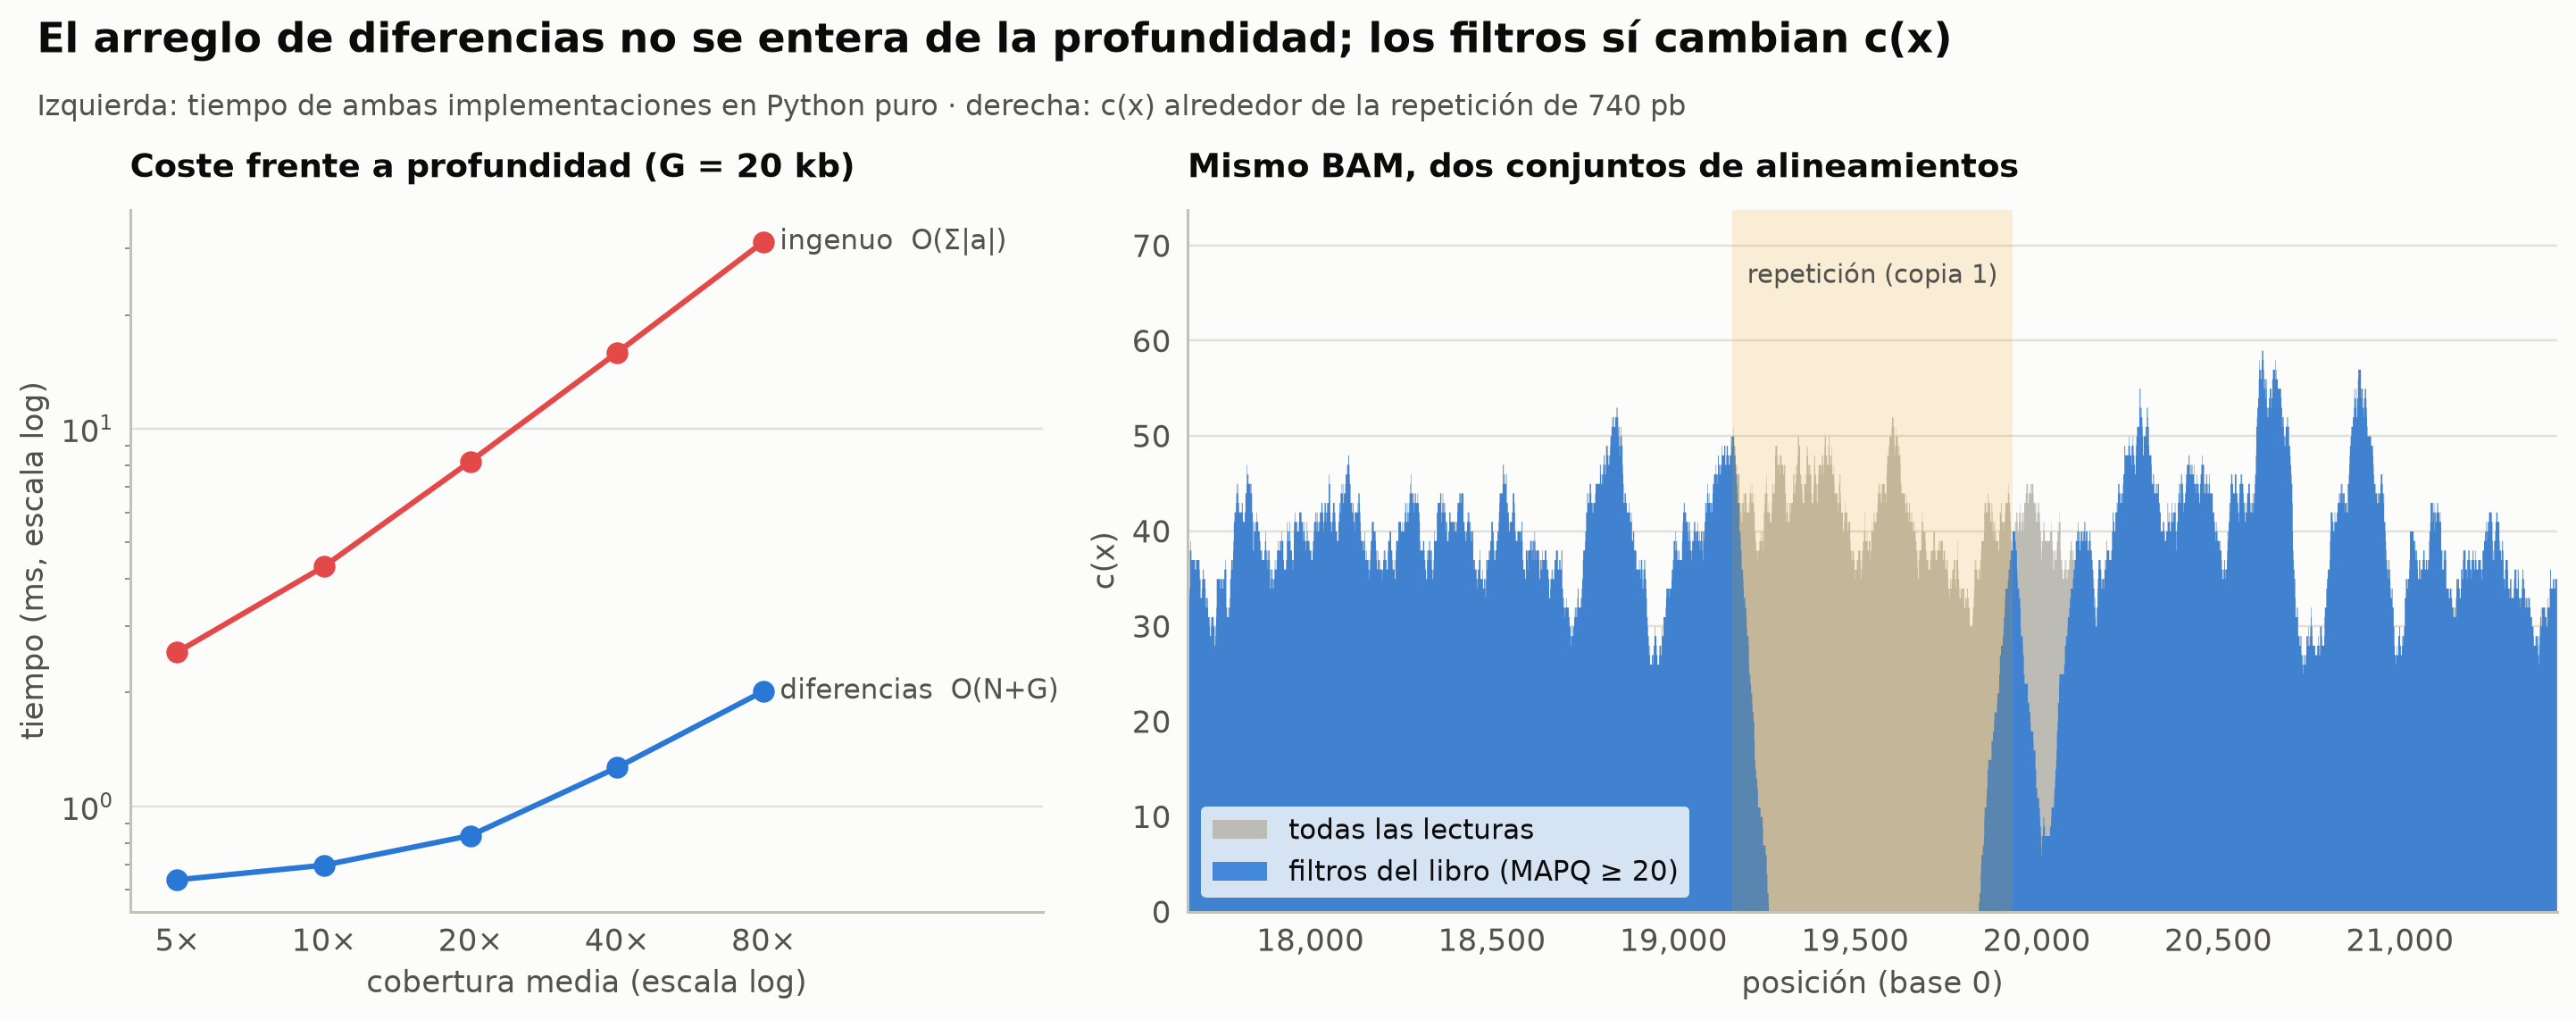

,cobertura,lecturas,ingenuo_s,diferencias_s
0,5,1000,0.0026,0.0006
1,10,2000,0.0043,0.0007
2,20,4000,0.0082,0.0008
3,40,8000,0.0159,0.0013
4,80,16000,0.0312,0.0020


In [38]:
G_B, L_B = 20_000, 100
bench = []
for cov in (5, 10, 20, 40, 80):
    n_r = cov * G_B // L_B
    st = rng.integers(0, G_B - L_B, n_r)
    bl = [[(int(s), int(s) + L_B)] for s in st]
    t0 = time.perf_counter(); a1 = depth_naive(bl, G_B); t1 = time.perf_counter() - t0
    t0 = time.perf_counter(); a2 = depth_diff(bl, G_B); t2 = time.perf_counter() - t0
    assert np.array_equal(a1, a2)
    bench.append(dict(cobertura=cov, lecturas=n_r, ingenuo_s=t1, diferencias_s=t2))
bench = pd.DataFrame(bench)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1, 1.5]))
ax = axes[0]
ax.plot(bench["cobertura"], bench["ingenuo_s"] * 1e3, "o-", color=ec.RED, lw=2)
ax.plot(bench["cobertura"], bench["diferencias_s"] * 1e3, "o-", color=ec.BLUE, lw=2)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(bench["cobertura"], [f"{c}×" for c in bench["cobertura"]])
ax.set_xlabel("cobertura media (escala log)"); ax.set_ylabel("tiempo (ms, escala log)")
ec.label_end(ax, bench["cobertura"].iloc[-1], bench["ingenuo_s"].iloc[-1] * 1e3, "ingenuo  O(Σ|a|)")
ec.label_end(ax, bench["cobertura"].iloc[-1], bench["diferencias_s"].iloc[-1] * 1e3, "diferencias  O(N+G)")
ax.set_xlim(4, 300)
ax.set_title("Coste frente a profundidad (G = 20 kb)", loc="left", fontsize=12)
ax = axes[1]
z0, z1 = REPEAT[0][0] - 1500, REPEAT[0][1] + 1500
xs = np.arange(z0, z1)
ax.fill_between(xs, c_all[z0:z1], step="post", color="#bdbcb4", lw=0, label="todas las lecturas")
ax.fill_between(xs, c_q20[z0:z1], step="post", color=ec.BLUE, lw=0, alpha=0.85, label="filtros del libro (MAPQ ≥ 20)")
ax.axvspan(*REPEAT[0], color=ec.YELLOW, alpha=0.15, lw=0)
ax.text(np.mean(REPEAT[0]), c_all[z0:z1].max() * 1.12, "repetición (copia 1)", ha="center", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(z0, z1); ax.set_ylim(0, c_all[z0:z1].max() * 1.25)
ax.set_xlabel("posición (base 0)"); ax.set_ylabel("c(x)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(loc="lower left", frameon=True)
ax.set_title("Mismo BAM, dos conjuntos de alineamientos", loc="left", fontsize=12)
ec.fig_title(fig, "El arreglo de diferencias no se entera de la profundidad; los filtros sí cambian c(x)",
             "Izquierda: tiempo de ambas implementaciones en Python puro · derecha: c(x) alrededor de la repetición de 740 pb")
plt.show()
bench.round(4)

> 🔎 **Qué observamos.** A la izquierda, el conteo ingenuo crece en línea recta con la cobertura (duplicar la
> profundidad duplica el trabajo), mientras que el arreglo de diferencias apenas se mueve: su coste lo dominan los $G$
> pasos de la suma acumulada, y cada lectura sólo añade dos anotaciones, así que crece mucho más despacio. A $80\times$
> la diferencia ya supera un orden de magnitud; en un genoma humano a $30\times$ es la diferencia entre horas y minutos. El precio es **memoria**: un
> entero de 32 bits por base, cerca de 1 GB para el cromosoma 1 humano. A la derecha, el mismo BAM da dos perfiles
> distintos según el conjunto $\mathcal{A}$: dentro de la repetición, las lecturas con MAPQ 0 desaparecen del perfil
> filtrado y queda un valle que **no** es una deleción. Y fíjese en la última línea de la celda anterior: en nuestra
> biblioteca, con insertos de ~350 pb y lecturas de 100 pb, casi ningún par se solapa, pero en bibliotecas de insertos
> cortos el solapamiento de los dos extremos puede inflar la profundidad y `mosdepth` lo descuenta.
>
> Otras herramientas cubren usos distintos: `samtools depth`, `bedtools genomecov` (Quinlan y Hall, 2010) y
> `bamCoverage` de deepTools (Ramírez et al., 2016), que produce pistas normalizadas en bigWig. En la línea de órdenes,
> el equivalente de nuestro cálculo es `mosdepth -t 4 -n --by 500 -Q 20 m1 m1.bam` (profundidad media en ventanas de
> 500 pb, sólo MAPQ ≥ 20).

**Ejercicio 9.1 — Bloques a mano.** Tres lecturas se alinean en una referencia de 20 posiciones (base 0) con
`POS`/CIGAR: (a) 2 / `3S5M2D4M`, (b) 5 / `4M2I6M`, (c) 8 / `6M3N3M4S`. Escriba sus bloques $[s,e)$, el arreglo $\delta$
y $c(x)$. ¿Qué operaciones no consumen referencia y cuáles la consumen sin cubrirla? Compruebe con `ref_blocks` y
`depth_diff`.

In [39]:
#@title 🔑 Solución — Ejercicio 9.1 { display-mode: "form" }
ex = {"a": (2, [("S", 3), ("M", 5), ("D", 2), ("M", 4)]),
      "b": (5, [("M", 4), ("I", 2), ("M", 6)]),
      "c": (8, [("M", 6), ("N", 3), ("M", 3), ("S", 4)])}
ex_blocks = {k: ref_blocks(p, c) for k, (p, c) in ex.items()}
for k, b in ex_blocks.items():
    print(f"lectura {k}: bloques {b}")
d_ex = np.zeros(21, int)
for b in ex_blocks.values():
    for s, e in b:
        d_ex[s] += 1; d_ex[e] -= 1
print("δ =", d_ex[:-1].tolist())
print("c =", depth_diff(list(ex_blocks.values()), 20).tolist())
print("S, H e I no consumen referencia (la I de la lectura b no rompe su bloque: 4M2I6M cubre [5,15));")
print("D y N la consumen sin cubrirla: parten el alineamiento en dos bloques.")

lectura a: bloques [(2, 7), (9, 13)]
lectura b: bloques [(5, 15)]
lectura c: bloques [(8, 14), (17, 20)]
δ = [0, 0, 1, 0, 0, 1, 0, -1, 1, 1, 0, 0, 0, -1, -1, -1, 0, 1, 0, 0]
c = [0, 0, 1, 1, 1, 2, 2, 1, 2, 3, 3, 3, 3, 2, 1, 0, 0, 1, 1, 1]
S, H e I no consumen referencia (la I de la lectura b no rompe su bloque: 4M2I6M cubre [5,15));
D y N la consumen sin cubrirla: parten el alineamiento en dos bloques.


## 10. Cobertura y número de copias: la pista $\ell_W$

Vuelva a la carretera, ahora vista desde un helicóptero. Por una autopista de **dos carriles** pasa una densidad de
coches más o menos uniforme. Si en un tramo cierran **un carril** por obras, la densidad cae a la mitad; si cortan el
tramo entero, no pasa ningún coche; si abren un **tercer carril**, la densidad sube un 50 %. Y hay un tramo en que la
autopista corre paralela a otra idéntica: desde el aire es imposible saber por cuál va cada coche, y el contador
automático, prudente, no cuenta ninguno. Un perfil de cobertura es esa vista aérea del genoma: las lecturas son los
coches, el **número de copias** son los carriles y las **repeticiones** son las autopistas gemelas.

**Un caso real.** En el diagnóstico genético de cáncer hereditario, una fracción de las variantes patogénicas de genes
como *BRCA1* no son cambios de una base sino **deleciones heterocigotas de uno o varios exones**, de cientos a miles de
pb. En un síndrome de microdeleción como el 22q11.2, el paciente ha perdido una de sus dos copias de unos 3 Mb. En
ambos casos la secuencia que queda es normal: la única huella en los datos de profundidad es que **esa región recibe la
mitad de lecturas**. Hay que convertir la pista de cobertura en una pista de número de copias.

### Las ecuaciones

Si las lecturas se muestrean uniformemente, la profundidad esperada es proporcional al número de copias. Para un
genoma diploide (ecuaciones 07-cn y 07-log2 del libro):

$$
\mathbb{E}\big[c(x)\big] = \bar c\,\frac{\mathrm{CN}(x)}{2}\,b(x),
\qquad\qquad
\ell_W = \log_2\frac{\bar c_W}{\operatorname{mediana}_V\,\bar c_V}
$$

| Símbolo | Significado |
|---|---|
| $\bar c$ | cobertura media del genoma (p. ej., $30\times$) |
| $\mathrm{CN}(x)$ | número de copias de la región en la muestra: 2 normal, 1 deleción heterocigota, 0 homocigota, 3 duplicación heterocigota |
| $b(x)$ | sesgo local multiplicativo (contenido de GC, mapeabilidad), idealmente 1 |
| $\bar c_W$ | profundidad media en la ventana $W$ |
| $\operatorname{mediana}_V \bar c_V$ | mediana de las profundidades medias de **todas** las ventanas $V$: la referencia "normal", robusta a las propias CNV |
| $\ell_W$ | razón logarítmica: $0$ normal, $-1$ deleción heterocigota, $\log_2 1.5 = 0.58$ duplicación, $-\infty$ deleción homocigota |

¿Por qué la **mediana** y no la media? Porque la mayoría de las ventanas son normales: la mediana ignora unas pocas
ventanas con deleciones o duplicaciones, mientras que la media se dejaría arrastrar por ellas. ¿Y por qué el
**logaritmo en base 2**? Porque convierte los cocientes en distancias simétricas: perder la mitad ($\times 1/2$) y
duplicar ($\times 2$) quedan a $-1$ y $+1$ del cero.

### Ejemplo a mano

Con $\bar c = 30$ y $b = 1$, una ventana normal tiene $\bar c_W = 30$ y $\ell_W = \log_2(30/30) = 0$.

* Deleción heterocigota (CN = 1): $\bar c_W = 30 \cdot \tfrac12 = 15$, $\ell_W = \log_2(15/30) = -1$.
* Duplicación heterocigota (CN = 3): $\bar c_W = 30 \cdot \tfrac32 = 45$, $\ell_W = \log_2 1.5 = 0.585$.
* Deleción homocigota (CN = 0): $\bar c_W = 0$, $\ell_W = \log_2 0 = -\infty$. En la práctica siempre se cuela alguna
  lectura mal mapeada o que toca el borde, y los programas ponen un **suelo** antes del logaritmo; aquí, como en el libro,
  $\max(\bar c_W, 0.25)$, que da como mucho $\log_2(0.25/30) \approx -6.9$.

Fíjese en la asimetría: una duplicación heterocigota ($+0.58$) está **más cerca** del cero que una deleción
heterocigota ($-1$). Las ganancias de una copia son más difíciles de ver que las pérdidas.

### Un perfil simulado con todas las trampas

Reproducimos el perfil del libro: 100 kb de un genoma diploide a $30\times$ con lecturas de 150 pb, con una **deleción
heterocigota** de 4 kb (30–34 kb), una **homocigota** de 1.5 kb (55–56.5 kb), una **duplicación heterocigota** de 6 kb
(72–78 kb) y una **repetición** de 2 kb (88–90 kb) cuya otra copia está en otro lugar del genoma. A esto le añadimos
lo que el libro deja implícito: una secuencia cuyo **contenido de GC** ondula a lo largo de la región, un sesgo
$b(x) = e^{2\,(\mathrm{GC}(x) - 0.5)}$ que imita el efecto de la PCR (las regiones ricas en GC reciben más lecturas),
y una **máscara de mapeabilidad** calculada sobre la propia secuencia: una lectura recibe MAPQ 0 si sus 150 bases
aparecen idénticas en otro lugar del genoma. Las lecturas se cuentan con el arreglo de diferencias de la sección 9.

In [40]:
rng_cn = np.random.default_rng(2018)
G_CN, L_CN, C_CN, W_CN = 100_000, 150, 30.0, 1000
EVENTS_CN = {"het": (30_000, 34_000, 1), "hom": (55_000, 56_500, 0), "dup": (72_000, 78_000, 3)}
REP_CN = (88_000, 90_000)

# 1) Secuencia con GC ondulante (+ 2 kb extra al final: la otra copia de la repetición, fuera de la vista)
xg = np.arange(G_CN + 2_000)
gc_true = 0.5 + 0.06 * np.sin(2 * np.pi * xg / 17_000) + 0.04 * np.sin(2 * np.pi * xg / 5_300 + 1)
is_gc = rng_cn.random(len(xg)) < gc_true
seq_cn = np.where(is_gc, rng_cn.choice(list("GC"), len(xg)), rng_cn.choice(list("AT"), len(xg)))
seq_cn[G_CN:] = seq_cn[REP_CN[0]:REP_CN[1]]
seq_cn = "".join(seq_cn)

# 2) Mapeabilidad: ¿el 150-mer que empieza en x es único en todo el genoma?
kmer_n = collections.Counter(seq_cn[p:p + L_CN] for p in range(len(seq_cn) - L_CN + 1))
unique_start = np.array([kmer_n[seq_cn[p:p + L_CN]] == 1 for p in range(G_CN)])

# 3) Número de copias y sesgo de GC → inicios de lectura de Poisson (ecuación 07-cn)
cn_true = np.full(G_CN, 2.0)
for a, b, cn in EVENTS_CN.values():
    cn_true[a:b] = cn
bias = np.exp(2 * (gc_true[:G_CN] - 0.5))
rate = C_CN / L_CN * cn_true / 2 * bias
starts = rng_cn.poisson(np.convolve(rate, np.ones(L_CN) / L_CN, mode="same"))
read_pos = np.repeat(np.arange(G_CN), starts)

# 4) Profundidad con el arreglo de diferencias (vectorizado con np.add.at)
def diff_depth(pos, L, G):
    d = np.zeros(G + L + 1, np.int64)
    np.add.at(d, pos, 1); np.add.at(d, pos + L, -1)
    return np.cumsum(d)[:G]
cov_all = diff_depth(read_pos, L_CN, G_CN)
cov_q = diff_depth(read_pos[unique_start[read_pos]], L_CN, G_CN)     # sólo lecturas con MAPQ ≥ 20

# 5) Ventanas de 1 kb: profundidad media, GC observado, mapeabilidad y ℓ_W
nwin = G_CN // W_CN
win = pd.DataFrame({"inicio": np.arange(nwin) * W_CN})
win["c_W"] = cov_q.reshape(nwin, W_CN).mean(1)
win["c_W_todas"] = cov_all.reshape(nwin, W_CN).mean(1)
win["GC"] = [sum(ch in "GC" for ch in seq_cn[s:s + W_CN]) / W_CN for s in win["inicio"]]
win["mapeable"] = unique_start.reshape(nwin, W_CN).mean(1)
med = np.median(win["c_W"])
win["l_W"] = np.log2(np.maximum(win["c_W"], 0.25) / med)
win["CN_real"] = cn_true.reshape(nwin, W_CN).mean(1)
print(f"{len(read_pos):,} lecturas · cobertura media: todas {cov_all.mean():.1f}×, MAPQ ≥ 20 {cov_q.mean():.1f}× · "
      f"mediana de las ventanas {med:.1f}×")
print(f"Dentro de la repetición: todas las lecturas {cov_all[REP_CN[0]:REP_CN[1]].mean():.1f}× · "
      f"MAPQ ≥ 20 {cov_q[REP_CN[0]:REP_CN[1]].mean():.1f}× · posiciones mapeables {unique_start[REP_CN[0]:REP_CN[1]].mean():.0%}")

19,907 lecturas · cobertura media: todas 29.8×, MAPQ ≥ 20 29.2× · mediana de las ventanas 29.5×
Dentro de la repetición: todas las lecturas 33.3× · MAPQ ≥ 20 2.3× · posiciones mapeables 7%


### Corregir el sesgo de GC y enmascarar lo no mapeable

El sesgo $b(x)$ hace que ventanas perfectamente normales se alejen del cero. Como el GC de cada ventana se conoce
(depende sólo de la referencia), podemos **medir** el sesgo: ajustamos $\ell_W$ frente al GC en las ventanas que
parecen normales ($|\ell_W| < 0.4$) y restamos la recta. Es la idea de las correcciones de GC de los métodos de
profundidad (con curvas más flexibles o medianas por intervalo de GC cuando hay miles de ventanas). La mapeabilidad no
se corrige: se **enmascara**. Una ventana con menos de la mitad de posiciones mapeables no informa del número de
copias, sólo de que ahí el mapeador no puede decidir.

In [41]:
normal_w = (win["l_W"].abs() < 0.4) & (win["mapeable"] > 0.9)
slope, intercept = np.polyfit(win.loc[normal_w, "GC"], win.loc[normal_w, "l_W"], 1)
win["l_W_gc"] = win["l_W"] - (intercept + slope * win["GC"])
win["enmascarada"] = win["mapeable"] < 0.5

def region_of(s):
    """Evento de la ventana [s, s + W): sólo si la contiene entera; 'borde' si la toca a medias."""
    for name, (a, b) in list({k: v[:2] for k, v in EVENTS_CN.items()}.items()) + [("repetición", REP_CN)]:
        if a <= s and s + W_CN <= b: return name
        if s < b and s + W_CN > a: return "borde (parcial)"
    return "normal"
win["región"] = win["inicio"].map(region_of)
theory = {"normal": "0", "het": "−1", "hom": "−∞ (suelo −6.9)", "dup": "+0.58", "repetición": "0 (¡no falta ADN!)",
          "borde (parcial)": "mezcla"}
summary = (win.groupby("región", sort=False)
              .agg(ventanas=("l_W", "size"), c_W=("c_W", "mean"), l_W=("l_W", "mean"), l_W_gc=("l_W_gc", "mean"))
              .assign(teoría=lambda d: d.index.map(theory)).round(2))
print(f"Pendiente del sesgo: {slope:.2f} unidades de log₂ por unidad de GC · "
      f"desviación típica de las ventanas normales: {win.loc[normal_w, 'l_W'].std():.3f} → "
      f"{win.loc[normal_w, 'l_W_gc'].std():.3f} tras corregir")
summary

Pendiente del sesgo: 2.37 unidades de log₂ por unidad de GC · desviación típica de las ventanas normales: 0.183 → 0.134 tras corregir


,ventanas,c_W,l_W,l_W_gc,teoría
región,,,,,
normal,86,29.86,0.00,-0.01,0
het,4,13.66,-1.11,-1.05,−1
hom,1,3.14,-3.23,-3.31,−∞ (suelo −6.9)
borde (parcial),1,13.05,-1.18,-1.28,mezcla
dup,6,46.52,0.65,0.55,+0.58
repetición,2,2.30,-3.69,-3.82,0 (¡no falta ADN!)


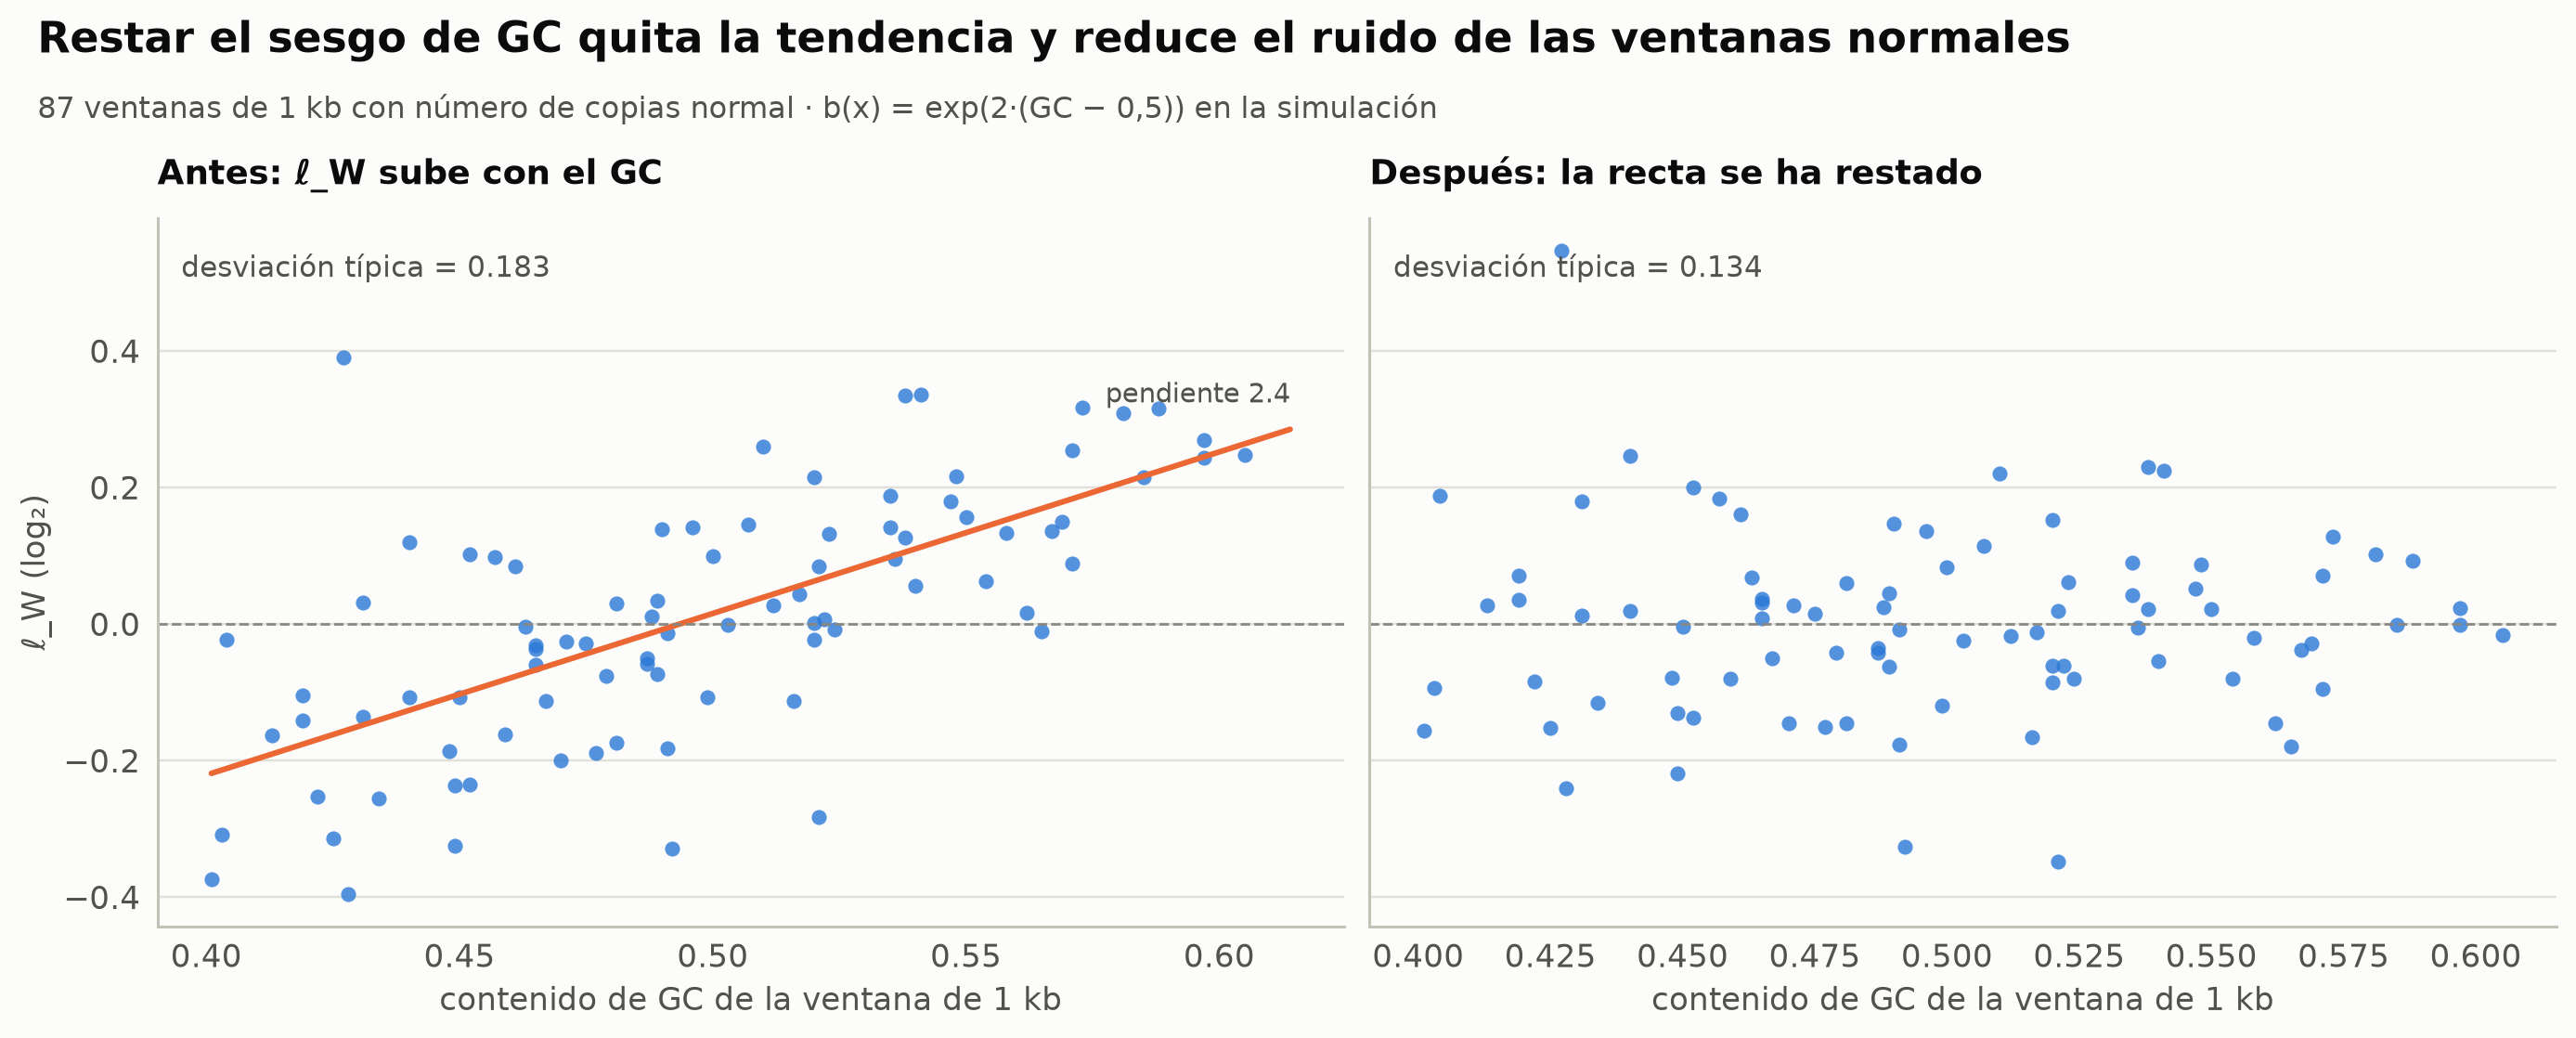

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
gx = np.linspace(win["GC"].min(), win["GC"].max(), 10)
for ax, col, ttl in [(axes[0], "l_W", "Antes: ℓ_W sube con el GC"), (axes[1], "l_W_gc", "Después: la recta se ha restado")]:
    ok = normal_w
    ax.scatter(win.loc[ok, "GC"], win.loc[ok, col], s=28, color=ec.BLUE, alpha=0.8, lw=0)
    if col == "l_W":
        ax.plot(gx, intercept + slope * gx, color=ec.ORANGE, lw=2)
        ax.text(gx[-1], intercept + slope * gx[-1] + 0.03, f"pendiente {slope:.1f}", ha="right", va="bottom",
                fontsize=9.5, color=ec.INK_2)
    ax.axhline(0, color=ec.MUTED, lw=0.9, ls="--")
    sd = win.loc[ok, col].std()
    ax.text(0.02, 0.95, f"desviación típica = {sd:.3f}", transform=ax.transAxes, fontsize=10, color=ec.INK_2, va="top")
    ax.set_xlabel("contenido de GC de la ventana de 1 kb")
    ax.set_title(ttl, loc="left", fontsize=12)
axes[0].set_ylabel("ℓ_W (log₂)")
ec.fig_title(fig, "Restar el sesgo de GC quita la tendencia y reduce el ruido de las ventanas normales",
             f"{int(normal_w.sum())} ventanas de 1 kb con número de copias normal · b(x) = exp(2·(GC − 0,5)) en la simulación")
plt.show()

> 🤔 **Antes de ejecutar, prediga:** en la pista interactiva que sigue, ¿a qué valor de $\ell_W$ caerá la repetición
> si **no** la enmascaramos? ¿Con qué evento podría confundirse?

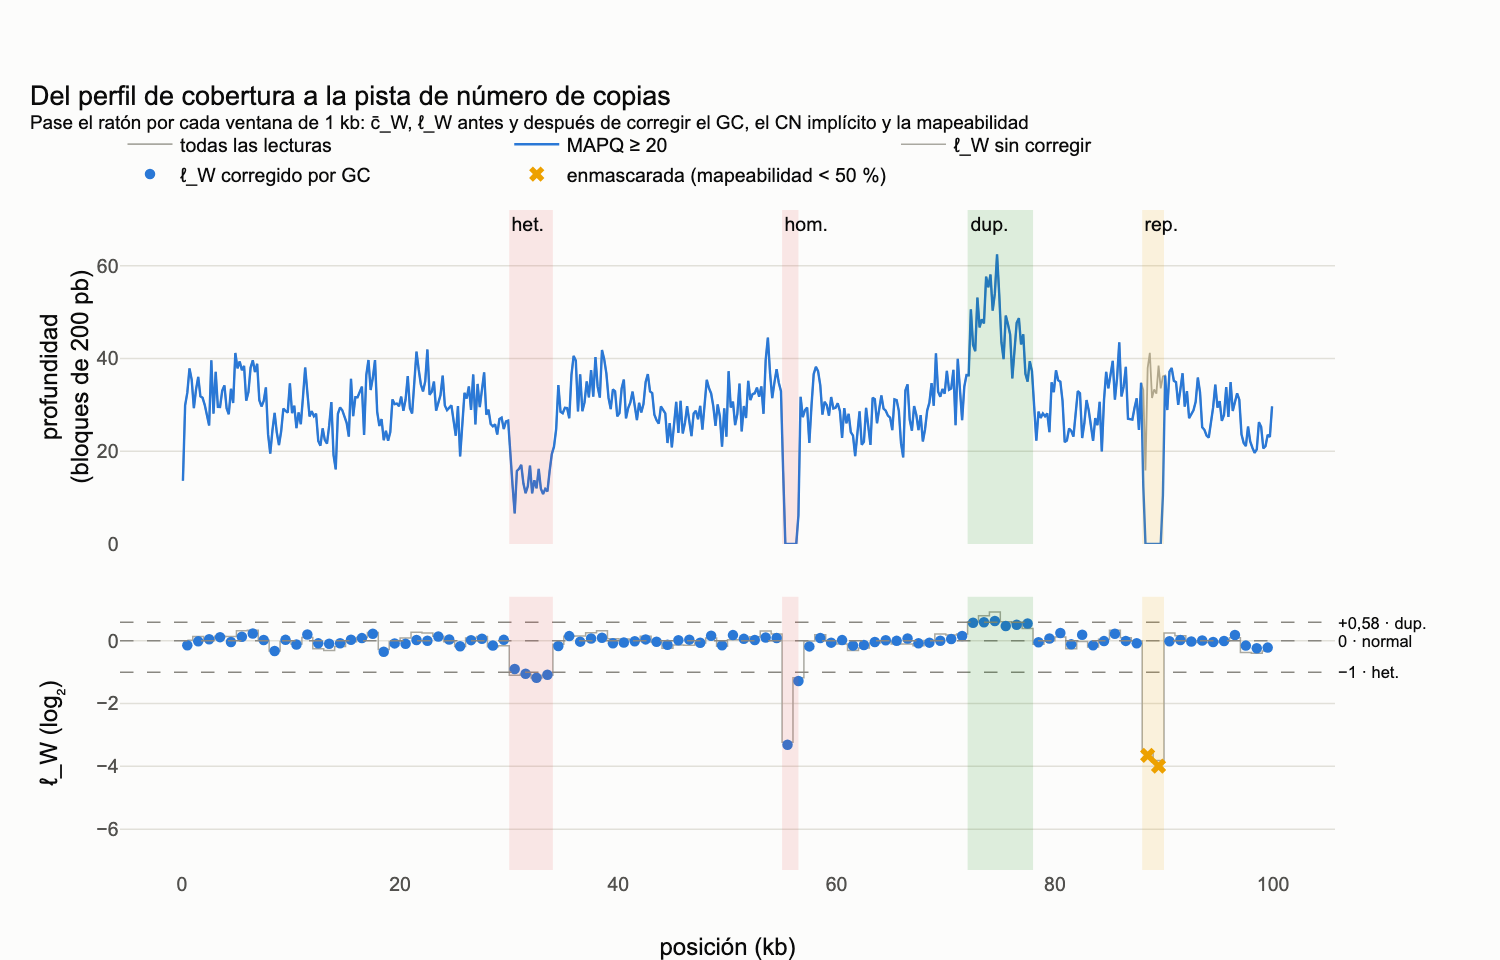

In [43]:
blk = 200
xb = (np.arange(G_CN // blk) * blk + blk / 2) / 1000
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08, row_heights=[0.55, 0.45])
fig.add_trace(go.Scatter(x=xb, y=cov_all.reshape(-1, blk).mean(1), name="todas las lecturas", mode="lines",
                         line=dict(color="#a9a8a0", width=1.2), hovertemplate="%{x:.1f} kb · %{y:.1f}×<extra>todas</extra>"),
              row=1, col=1)
fig.add_trace(go.Scatter(x=xb, y=cov_q.reshape(-1, blk).mean(1), name="MAPQ ≥ 20", mode="lines",
                         line=dict(color=ec.BLUE, width=1.6), hovertemplate="%{x:.1f} kb · %{y:.1f}×<extra>MAPQ ≥ 20</extra>"),
              row=1, col=1)
xw = (win["inicio"] + W_CN / 2) / 1000
hover = [f"<b>ventana {s // 1000}–{s // 1000 + 1} kb</b> ({r})<br>c̄_W = {c:.1f}× (mediana {med:.1f}×)<br>"
         f"ℓ_W = {l:+.2f} → CN ≈ 2·2^ℓ = {2 * 2 ** l:.2f}<br>ℓ_W corregido por GC = {lg:+.2f} → CN ≈ {2 * 2 ** lg:.2f}<br>"
         f"GC = {g:.1%} · mapeable {m:.0%}" + ("<br><b>enmascarada: no mapeable</b>" if msk else "")
         for s, r, c, l, lg, g, m, msk in zip(win["inicio"], win["región"], win["c_W"], win["l_W"], win["l_W_gc"],
                                              win["GC"], win["mapeable"], win["enmascarada"])]
fig.add_trace(go.Scatter(x=xw, y=win["l_W"], name="ℓ_W sin corregir", mode="lines", line=dict(color="#a9a8a0", width=1,
                         shape="hvh"), hoverinfo="skip"), row=2, col=1)
okm = ~win["enmascarada"]
fig.add_trace(go.Scatter(x=xw[okm], y=win.loc[okm, "l_W_gc"], name="ℓ_W corregido por GC", mode="markers",
                         marker=dict(size=7, color=ec.BLUE), hovertext=[h for h, k in zip(hover, okm) if k],
                         hoverinfo="text"), row=2, col=1)
fig.add_trace(go.Scatter(x=xw[~okm], y=win.loc[~okm, "l_W_gc"], name="enmascarada (mapeabilidad < 50 %)",
                         mode="markers", marker=dict(size=9, color=ec.YELLOW, symbol="x"),
                         hovertext=[h for h, k in zip(hover, okm) if not k], hoverinfo="text"), row=2, col=1)
for yv, lab in [(0, "0 · normal"), (-1, "−1 · het."), (np.log2(1.5), "+0,58 · dup.")]:
    fig.add_hline(y=yv, line=dict(color=ec.MUTED, dash="dash", width=1), row=2, col=1,
                  annotation_text=lab, annotation_position="right", annotation_font_size=11)
for (a, b), lab, col in [(EVENTS_CN["het"][:2], "het.", ec.RED), (EVENTS_CN["hom"][:2], "hom.", ec.RED),
                         (EVENTS_CN["dup"][:2], "dup.", ec.GREEN), (REP_CN, "rep.", ec.YELLOW)]:
    fig.add_vrect(x0=a / 1000, x1=b / 1000, fillcolor=col, opacity=0.12, line_width=0,
                  annotation_text=lab, annotation_position="top left", row=1, col=1)
    fig.add_vrect(x0=a / 1000, x1=b / 1000, fillcolor=col, opacity=0.12, line_width=0, row=2, col=1)
fig.update_yaxes(title="profundidad<br>(bloques de 200 pb)", range=[0, 72], row=1, col=1)
fig.update_yaxes(title="ℓ_W (log₂)", range=[-7.3, 1.4], row=2, col=1)
fig.update_xaxes(title="posición (kb)", row=2, col=1)
fig.update_layout(height=640, title="Del perfil de cobertura a la pista de número de copias<br><sup>Pase el ratón por "
                  "cada ventana de 1 kb: c̄_W, ℓ_W antes y después de corregir el GC, el CN implícito y la mapeabilidad</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=140, l=80, r=110, b=60))
fig.show()

> 🔎 **Qué observamos.** Arriba, la profundidad cae a la mitad en la deleción heterocigota, a cero en la homocigota y
> sube un 50 % en la duplicación; encima, todo ondula suavemente con el GC. Abajo, los puntos azules (ya corregidos)
> se agrupan cerca de los valores teóricos: la tabla anterior da los promedios, del orden de $-1$ para la deleción
> heterocigota y de $+0.6$ para la duplicación (el libro, con otra semilla aleatoria, obtiene $-1.14$ y $0.69$). La
> deleción homocigota se desploma hacia el suelo: no llega a $-\infty$ sólo porque algunas lecturas de los bordes se
> asoman dentro de la ventana. Y la **trampa**: con todas las lecturas la repetición tiene una cobertura normal; con el
> filtro MAPQ ≥ 20 cae casi a cero y, sin la máscara de mapeabilidad, sus ventanas se leerían como una **deleción
> homocigota**. Por eso un análisis de cobertura siempre debe acompañarse de una máscara de mapeabilidad.
>
> Un método real no se detiene aquí: después hay que **segmentar** la pista, es decir, decidir dónde empieza y termina
> cada tramo de número de copias constante. CNVnator (Abyzov et al., 2011), uno de los métodos clásicos de profundidad
> de lectura, corrige el sesgo de GC, segmenta el perfil con un algoritmo de *mean-shift* y alcanza, con cobertura
> alta, una resolución de los puntos de corte de menos de 200 pb en el 90 % de los casos. Sus autores subrayan que la
> profundidad es **complementaria** a los pares discordantes y a las lecturas partidas de la sección 8: cada señal ve
> variantes que las otras no ven.

✅ **Compruebe su comprensión.** En una muestra tumoral con un 60 % de células tumorales, el tumor tiene una deleción
heterocigota. ¿Qué $\ell_W$ espera? (Respuesta: la mezcla tiene $0.6\cdot 1 + 0.4 \cdot 2 = 1.4$ copias de media, así que
$\ell_W = \log_2(1.4/2) \approx -0.51$: la pureza tumoral acerca todas las señales al cero.)

**Ejercicio 10.1 — El clon haploide del LTEE.** El clon de *E. coli* del experimento de evolución a largo plazo de Lenski
que mapeamos contra REL606 es **haploide**: la ecuación 07-cn se escribe entonces
$\mathbb{E}[c(x)] = \bar c\,\mathrm{CN}(x)\,b(x)$ con CN = 1 normal. (a) ¿Qué $\ell_W$ esperaría para una deleción
(CN = 0) y para una duplicación (CN = 2)? ¿Existe en una bacteria el equivalente de la deleción "heterocigota"?
(b) Calcule $\ell_W$ en ventanas de 500 pb para nuestro experimento de 60 kb (la variable `depth`) y compare la
deleción de 500 pb y la duplicación con lo esperado. Recuerde que allí la duplicación está en **ambos** haplotipos.

In [44]:
#@title 🔑 Solución — Ejercicio 10.1 { display-mode: "form" }
print("(a) Haploide: pérdida → log2(0/1) = −∞; duplicación → log2(2/1) = +1. No hay 'heterocigota': la única forma de")
print("    ver la mitad de cobertura es una población mezclada (p. ej., un clon que aún no ha fijado la deleción).")
w500 = 500
cw = depth.reshape(-1, w500).mean(1)
l500 = np.log2(np.maximum(cw, 0.25) / np.median(cw))
i_del, i_dup = BIGDEL[0] // w500, slice(DUP[0] // w500, DUP[1] // w500)
print(f"(b) ventana de la deleción ({BIGDEL[0]:,}–{BIGDEL[1]:,}): c̄_W = {cw[i_del]:.2f}×, ℓ_W = {l500[i_del]:.2f} "
      f"(el suelo de 0,25 da log2(0,25/{np.median(cw):.0f}) = {np.log2(0.25 / np.median(cw)):.2f})")
print(f"    ventanas de la duplicación: ℓ_W medio = {l500[i_dup].mean():+.2f} (esperado +1: dos copias en cada haplotipo)")
print(f"    ventanas normales: desviación típica de ℓ_W = {np.delete(l500, np.r_[i_del, np.arange(i_dup.start, i_dup.stop)]).std():.3f}")

(a) Haploide: pérdida → log2(0/1) = −∞; duplicación → log2(2/1) = +1. No hay 'heterocigota': la única forma de
    ver la mitad de cobertura es una población mezclada (p. ej., un clon que aún no ha fijado la deleción).
(b) ventana de la deleción (42,000–42,500): c̄_W = 0.03×, ℓ_W = -7.29 (el suelo de 0,25 da log2(0,25/39) = -7.29)
    ventanas de la duplicación: ℓ_W medio = +1.03 (esperado +1: dos copias en cada haplotipo)
    ventanas normales: desviación típica de ℓ_W = 0.154


## 11. ¿Qué deleción es detectable?

Un laboratorio que ofrece genomas completos a $30\times$ quiere informar deleciones heterocigotas de uno o varios exones
en genes de cáncer hereditario. Antes de prometerlo tiene que responder una pregunta de diseño: **¿a partir de qué
tamaño** una deleción se ve en la profundidad, y a partir de cuál se pierde en el ruido? ¿Compensa secuenciar a
$60\times$?

La intuición es la de cualquier conteo. Si por una calle pasan, de media, 4 coches por minuto y cierran un carril,
esperaría ver 2; pero en un minuto concreto pueden pasar 2 coches aunque no haya obras, porque el azar de un conteo de
4 es de unos $\pm 2$. En una hora, en cambio, la diferencia entre 240 y 120 coches es inconfundible. La **señal** (la
diferencia de medias) crece en proporción al tiempo que miramos; el **ruido** (la desviación típica), sólo con su raíz
cuadrada. En el genoma, "mirar más tiempo" es usar una ventana más ancha, o secuenciar a más cobertura.

### La derivación, paso a paso

**1. El conteo.** En una ventana de $W$ bases con cobertura $\bar c$ y lecturas de longitud $L$, el número de lecturas
que **empiezan** en la ventana es aproximadamente de Poisson con media

$$
\lambda = \frac{\bar c\,W}{L},
$$

porque $\bar c\,G/L$ lecturas se reparten por $G$ bases, $\bar c/L$ por base. Su desviación típica es $\sqrt\lambda$.

**2. La diferencia en desviaciones típicas.** Una deleción heterocigota reduce la media a $\lambda/2$; una homocigota,
a 0. Medimos la diferencia en desviaciones típicas de la hipótesis nula (ecuación 07-z del libro):

$$
z_{\text{het}} = \frac{\lambda-\lambda/2}{\sqrt\lambda}=\frac{\sqrt{\lambda}}{2},
\qquad
z_{\text{hom}} = \frac{\lambda}{\sqrt\lambda}=\sqrt\lambda .
$$

**3. Despejar la ventana.** Exigimos $z \ge z^\star$: $\sqrt{\lambda}/2 \ge z^\star \Rightarrow \lambda \ge 4z^{\star2}
\Rightarrow \bar c W/L \ge 4 z^{\star 2}$, y lo mismo sin el 4 para la homocigota (ecuación 07-wmin):

$$
W_{\min}^{\text{het}} = \frac{4\,z^{\star 2}\,L}{\bar c},\qquad
W_{\min}^{\text{hom}} = \frac{z^{\star 2}\,L}{\bar c}.
$$

| Símbolo | Significado |
|---|---|
| $W$ | tamaño de la ventana (y de la deleción que queremos ver) en pb |
| $\bar c$, $L$ | cobertura media y longitud de lectura |
| $\lambda$ | número esperado de lecturas que empiezan en la ventana: $\bar c\,W/L$ |
| $z_{\text{het}}$, $z_{\text{hom}}$ | separación entre la ventana normal y la deleción, en desviaciones típicas de Poisson |
| $z^\star$ | umbral de significación en desviaciones típicas; con millones de ventanas en el genoma, $z^\star \approx 5$ controla los falsos positivos |
| $W_{\min}$ | tamaño mínimo de una deleción detectable por profundidad |

### Ejemplo a mano (el del libro)

Con $\bar c = 30$, $L = 150$ y $z^\star = 5$:

$$
W^{\text{het}}_{\min} = \frac{4\cdot 25\cdot 150}{30} = 500 \text{ pb},\qquad
W^{\text{hom}}_{\min} = \frac{25\cdot 150}{30} = 125 \text{ pb}.
$$

Compruebe con el paso 1: una ventana de 500 pb recibe $\lambda = 30\cdot 500/150 = 100$ inicios de lectura; la deleción
heterocigota deja 50; la diferencia, 50, es exactamente $5\sqrt{100}$. A $10\times$ los valores se **triplican**
(1500 y 375 pb); a $60\times$ se reducen a la **mitad** (250 y 62 pb). Una duplicación heterocigota, que cambia la media
de $\lambda$ a $1.5\lambda$, produce la misma diferencia absoluta ($\lambda/2$) que una deleción heterocigota y requiere,
por tanto, ventanas similares. Por debajo de unos cientos de bases la profundidad no basta y hay que recurrir a las
lecturas partidas y a los pares discordantes de la sección 8.

In [45]:
def w_min(c_bar, L=150, z_star=5.0, kind="het"):
    """Ecuación 07-wmin: tamaño mínimo de deleción detectable sólo por profundidad (modelo de Poisson)."""
    return (4 if kind == "het" else 1) * z_star ** 2 * L / c_bar

tab_w = pd.DataFrame([dict(cobertura=f"{c}×", **{"λ con W = 500 pb": c * 500 / 150,
                           "W_min het (pb)": round(w_min(c)), "W_min hom (pb)": int(w_min(c, kind="hom")),
                           "W_min het, z*=3 (pb)": round(w_min(c, z_star=3))}) for c in (10, 30, 60)])
tab_w

,cobertura,λ con W = 500 pb,W_min het (pb),W_min hom (pb),"W_min het, z*=3 (pb)"
0,10×,33.333333,1500,375,540
1,30×,100.000000,500,125,180
2,60×,200.000000,250,62,90


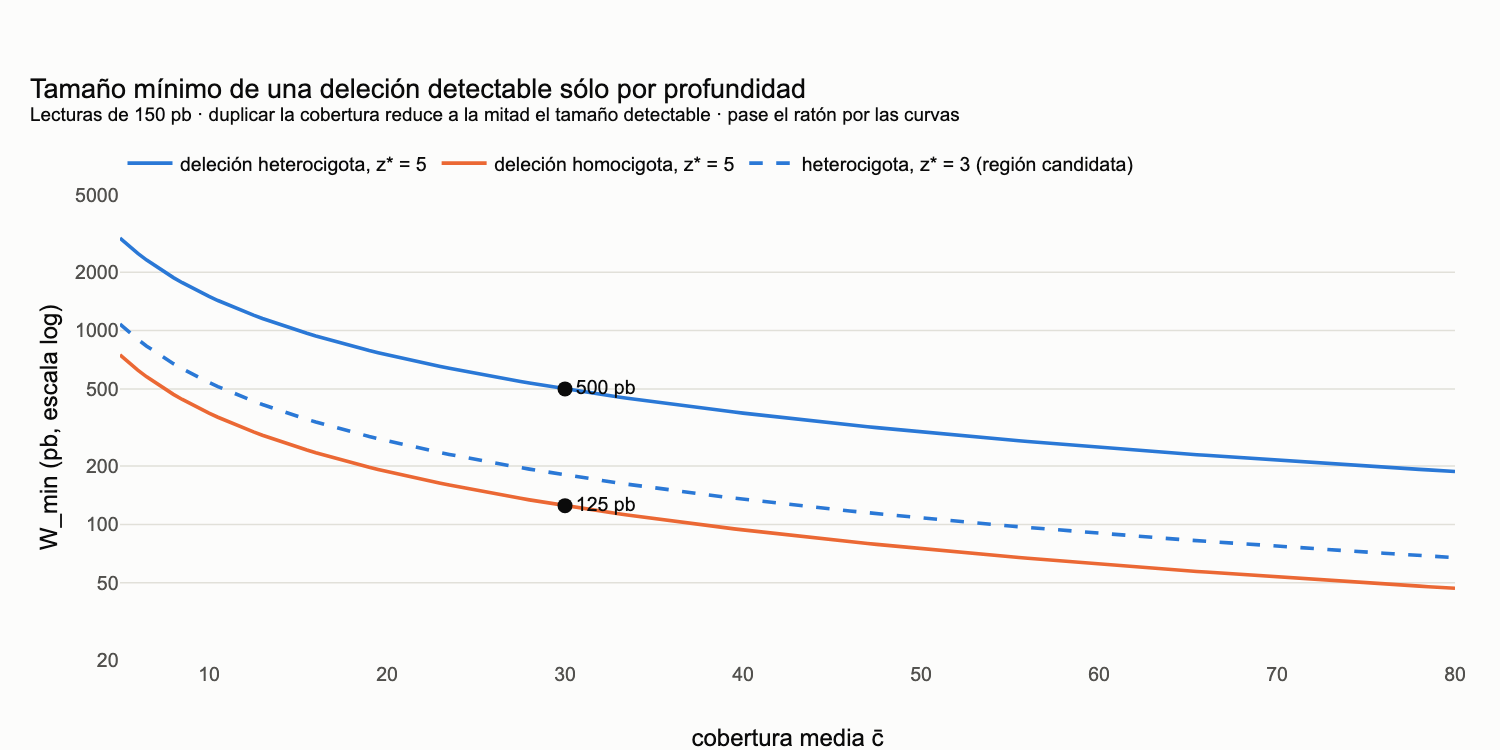

In [46]:
cgrid = np.linspace(5, 80, 151)
fig = go.Figure()
for kind, z, name, col, dash in [("het", 5, "deleción heterocigota, z* = 5", ec.BLUE, "solid"),
                                 ("hom", 5, "deleción homocigota, z* = 5", ec.ORANGE, "solid"),
                                 ("het", 3, "heterocigota, z* = 3 (región candidata)", ec.BLUE, "dash")]:
    wv = w_min(cgrid, z_star=z, kind=kind)
    lam = cgrid * wv / 150
    fig.add_trace(go.Scatter(x=cgrid, y=wv, mode="lines", name=name, line=dict(color=col, width=2.4, dash=dash),
                             customdata=np.c_[lam, lam / 2 if kind == "het" else 0 * lam],
                             hovertemplate=f"<b>{name}</b><br>cobertura %{{x:.0f}}× → W_min = %{{y:.0f}} pb<br>"
                                           "λ = c̄·W/L = %{customdata[0]:.0f} inicios esperados<br>"
                                           "con la deleción: %{customdata[1]:.0f}<extra></extra>"))
fig.add_trace(go.Scatter(x=[30, 30], y=[500, 125], mode="markers+text", text=["500 pb", "125 pb"],
                         textposition="middle right", marker=dict(size=10, color=ec.INK), showlegend=False,
                         hovertext=["30×, L = 150, z* = 5: 4·25·150/30 = 500 pb (λ = 100 → 50)",
                                    "30×, L = 150, z* = 5: 25·150/30 = 125 pb (λ = 25 → 0)"], hoverinfo="text"))
fig.update_xaxes(title="cobertura media c̄", range=[5, 80])
fig.update_yaxes(title="W_min (pb, escala log)", type="log", range=[np.log10(20), np.log10(5000)],
                 tickvals=[20, 50, 100, 200, 500, 1000, 2000, 5000])
fig.update_layout(height=500, title="Tamaño mínimo de una deleción detectable sólo por profundidad<br><sup>Lecturas de "
                  "150 pb · duplicar la cobertura reduce a la mitad el tamaño detectable · pase el ratón por las curvas</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=80, r=30, b=60))
fig.show()

### ¿Lo confirma una simulación?

Una fórmula así hay que ponerla a prueba. Simulamos muchas ventanas: en cada una sorteamos el número de lecturas que
empiezan dentro, de Poisson con media $\lambda/2$ si hay una deleción heterocigota y $\lambda$ si no la hay, calculamos
$z = (\lambda - n)/\sqrt{\lambda}$ y declaramos "deleción" si $z \ge z^\star = 5$. La fracción de deleciones detectadas es la
**potencia**; la fracción de ventanas normales señaladas, la tasa de **falsos positivos**.

> 🤔 **Antes de ejecutar, prediga:** a $30\times$, con una deleción heterocigota de exactamente $W_{\min} = 500$ pb,
> ¿qué fracción de las deleciones detectaremos: casi todas, la mitad o casi ninguna?

In [47]:
from scipy.stats import poisson
rng_det = np.random.default_rng(846)
Z_STAR, L_DET, N_SIM = 5.0, 150, 20_000
W_grid = np.unique(np.round(np.geomspace(50, 4000, 36)).astype(int))
power = {}
for c in (10, 30, 60):
    lam = c * W_grid / L_DET
    n_het = rng_det.poisson(lam / 2, (N_SIM, len(W_grid)))
    power[c] = ((lam - n_het) / np.sqrt(lam) >= Z_STAR).mean(0)
lam100 = 100.0                                       # ventana normal de 500 pb a 30×
n_null = rng_det.poisson(lam100, 2_000_000)
fp = np.mean((lam100 - n_null) / np.sqrt(lam100) >= Z_STAR)
fp_exact = poisson.cdf(lam100 - Z_STAR * np.sqrt(lam100), lam100)      # P(n ≤ 50 | λ = 100)
w90 = 4 * (Z_STAR + norm.ppf(0.9)) ** 2 * L_DET / 30
for c in (10, 30, 60):
    i = np.argmin(np.abs(W_grid - w_min(c)))
    print(f"{c}×: W_min het = {w_min(c):.0f} pb → potencia simulada en W = {W_grid[i]} pb: {power[c][i]:.0%}")
print(f"Falsos positivos por ventana normal (30×, 500 pb): simulados {fp:.1e} en 2 millones de ventanas · "
      f"exacto P(n ≤ 50 | λ = 100) = {fp_exact:.1e}")
print(f"Para detectar el 90 % a 30× hace falta z esperado = z* + 1,28 → W ≈ {w90:.0f} pb")

10×: W_min het = 1500 pb → potencia simulada en W = 1469 pb: 48%
30×: W_min het = 500 pb → potencia simulada en W = 476 pb: 44%
60×: W_min het = 250 pb → potencia simulada en W = 255 pb: 54%
Falsos positivos por ventana normal (30×, 500 pb): simulados 0.0e+00 en 2 millones de ventanas · exacto P(n ≤ 50 | λ = 100) = 2.4e-08
Para detectar el 90 % a 30× hace falta z esperado = z* + 1,28 → W ≈ 789 pb


### El techo de la sobredispersión

Los datos reales no son de Poisson. Como vimos en la Lección 6.3, los recuentos por ventana suelen ser **binomiales
negativos**, con varianza $\lambda + \lambda^2/r$: el sesgo residual de GC, de mapeabilidad y de la PCR añade una
variabilidad que **crece con la señal**. Con esa varianza en el denominador, la ecuación 07-z se convierte en

$$
z_{\text{het}} = \frac{\lambda/2}{\sqrt{\lambda+\lambda^{2}/r}} \;\xrightarrow{\;\lambda\to\infty\;}\; \frac{\sqrt r}{2}.
$$

| Símbolo | Significado |
|---|---|
| $r$ | parámetro de dispersión de la binomial negativa: cuanto menor, más sobredispersión ($r \to \infty$ recupera Poisson) |

La señal ya no crece indefinidamente con la ventana ni con la cobertura: tiene un **techo** fijado por la
sobredispersión. Con $r = 50$, $z_{\text{het}}$ nunca supera $\sqrt{50}/2 = 3.54$, por mucho que se secuencie.

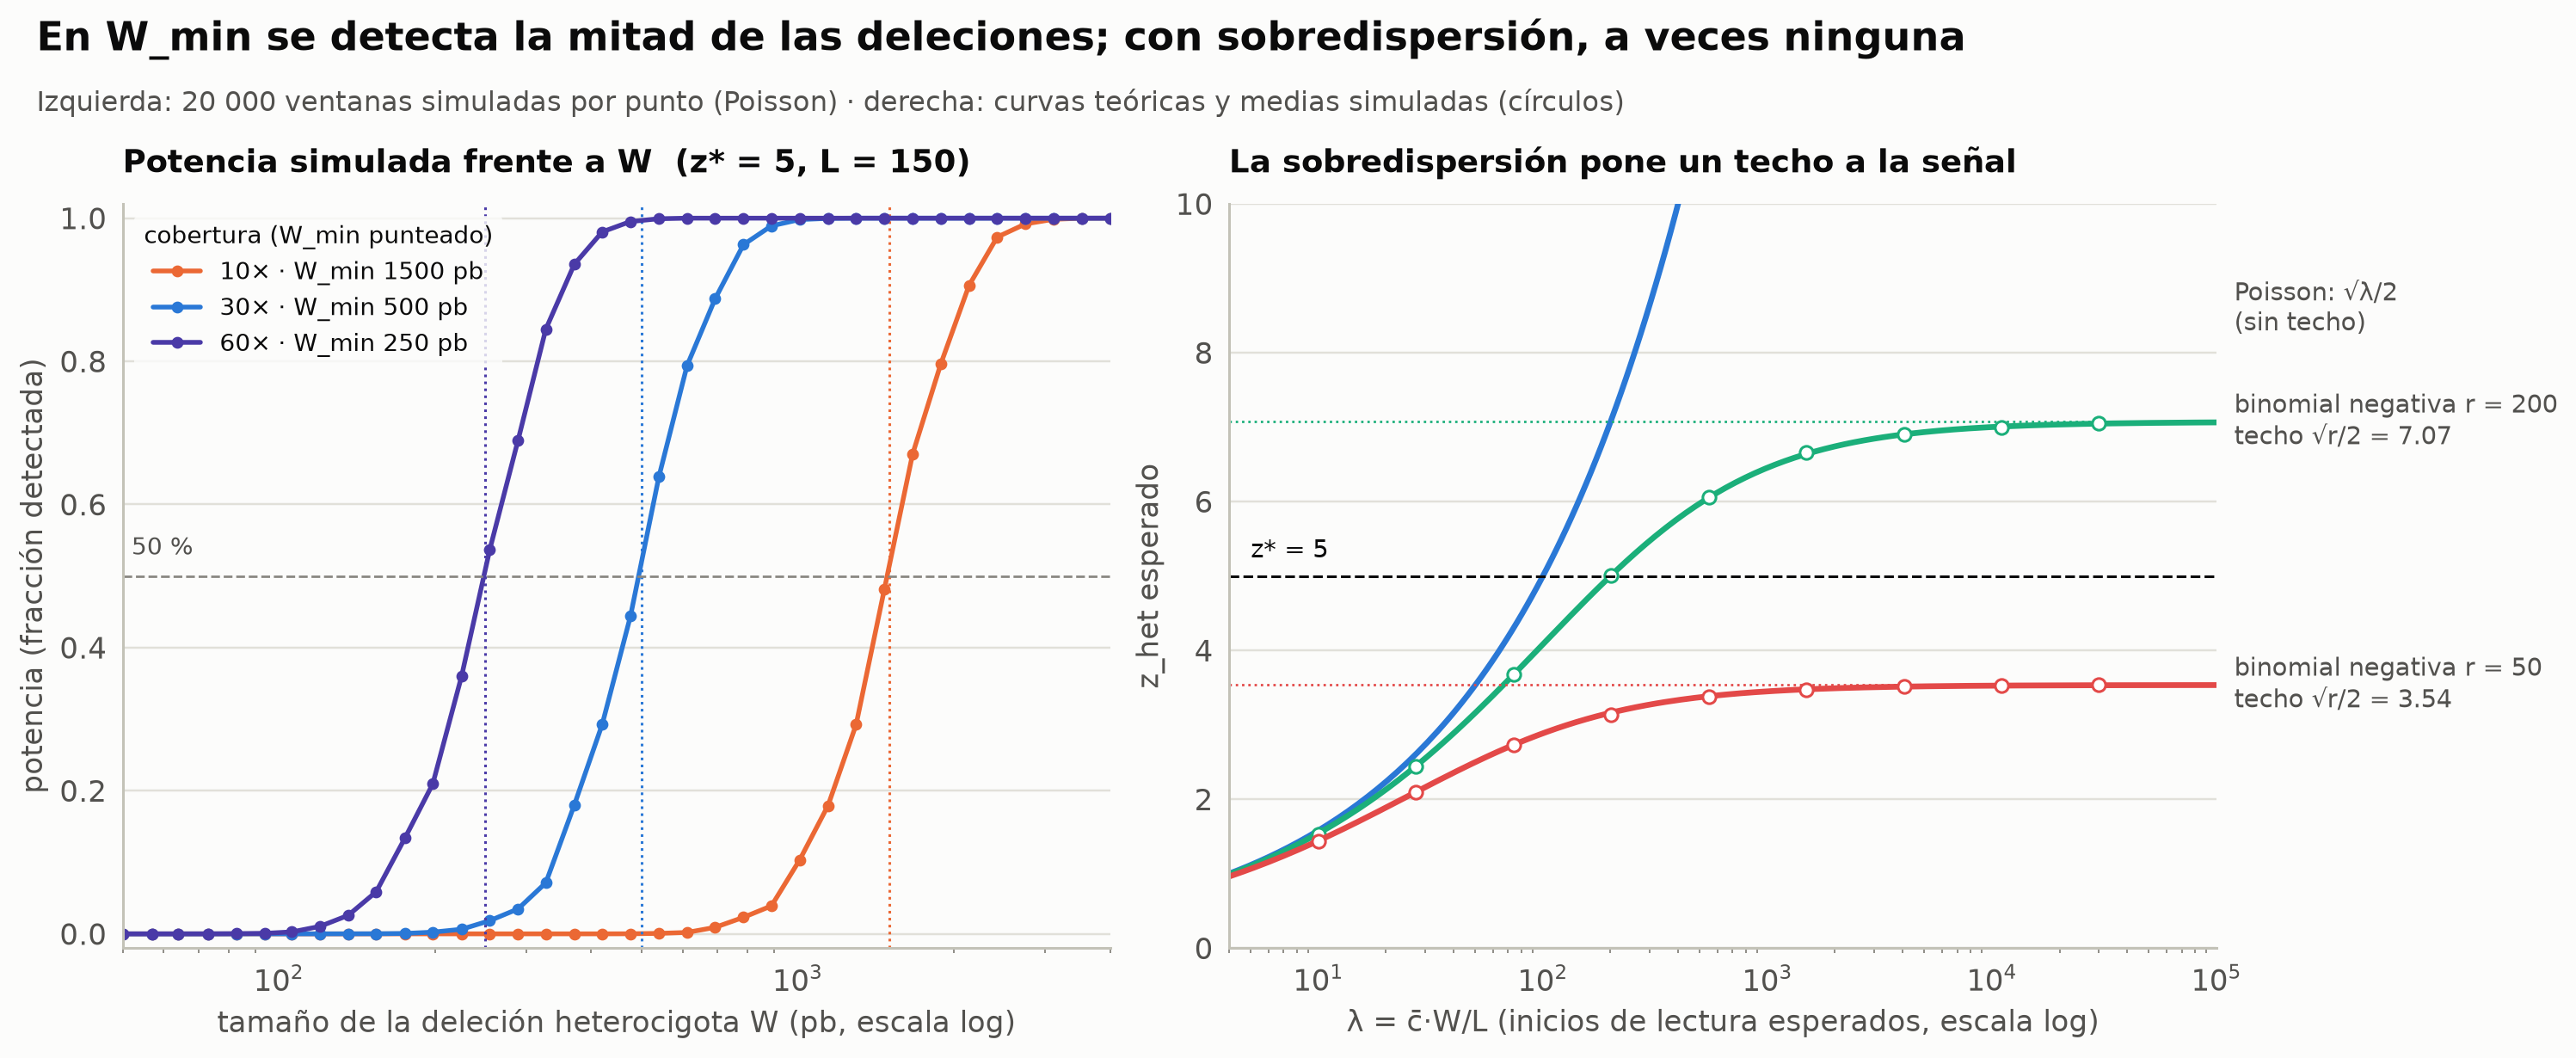

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
for c, col in zip((10, 30, 60), (ec.ORANGE, ec.BLUE, ec.VIOLET)):
    ax.plot(W_grid, power[c], "o-", color=col, ms=3.5, lw=1.8, label=f"{c}× · W_min {w_min(c):.0f} pb")
    ax.axvline(w_min(c), color=col, lw=1, ls=":")
ax.legend(loc="upper left", frameon=True, fontsize=9, title="cobertura (W_min punteado)", title_fontsize=9)
ax.axhline(0.5, color=ec.MUTED, lw=0.9, ls="--")
ax.text(52, 0.53, "50 %", fontsize=9, color=ec.INK_2)
ax.set_xscale("log"); ax.set_xlim(50, 4000); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("tamaño de la deleción heterocigota W (pb, escala log)"); ax.set_ylabel("potencia (fracción detectada)")
ax.set_title("Potencia simulada frente a W  (z* = 5, L = 150)", loc="left", fontsize=12)
ax = axes[1]
lam_g = np.geomspace(4, 1e5, 200)
ax.plot(lam_g, np.sqrt(lam_g) / 2, color=ec.BLUE, lw=2.2)
for r, col in [(200, ec.AQUA), (50, ec.RED)]:
    ax.plot(lam_g, (lam_g / 2) / np.sqrt(lam_g + lam_g ** 2 / r), color=col, lw=2.2)
    ax.axhline(np.sqrt(r) / 2, color=col, lw=0.9, ls=":")
    lam_s = np.geomspace(10, 3e4, 9)
    zsim = [np.mean((l - rng_det.negative_binomial(r, r / (r + l / 2), 4000)) / np.sqrt(l + l ** 2 / r)) for l in lam_s]
    ax.plot(lam_s, zsim, "o", color=col, ms=5, mfc="white")
    ax.text(1.2e5, np.sqrt(r) / 2, f"binomial negativa r = {r}\ntecho √r/2 = {np.sqrt(r) / 2:.2f}", va="center",
            fontsize=9.5, color=ec.INK_2)
ax.axhline(Z_STAR, color=ec.INK, lw=1, ls="--")
ax.text(5, Z_STAR + 0.25, "z* = 5", fontsize=9.5, color=ec.INK)
ax.text(1.2e5, 8.6, "Poisson: √λ/2\n(sin techo)", va="center", fontsize=9.5, color=ec.INK_2)
ax.set_xscale("log"); ax.set_xlim(4, 1e5); ax.set_ylim(0, 10)
ax.set_xlabel("λ = c̄·W/L (inicios de lectura esperados, escala log)"); ax.set_ylabel("z_het esperado")
ax.set_title("La sobredispersión pone un techo a la señal", loc="left", fontsize=12)
ec.fig_title(fig, "En W_min se detecta la mitad de las deleciones; con sobredispersión, a veces ninguna",
             "Izquierda: 20 000 ventanas simuladas por punto (Poisson) · derecha: curvas teóricas y medias simuladas (círculos)")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, las curvas de potencia cruzan el 50 % prácticamente en las líneas punteadas de
> $W_{\min}$: 1500, 500 y 250 pb. No es un defecto de la fórmula, es su lectura correcta. $W_{\min}$ es el tamaño en el
> que el $z$ **esperado** iguala a $z^\star$; como el $z$ observado fluctúa alrededor de su media, la mitad de las
> veces queda por encima y la otra mitad por debajo. Para detectar el 90 % hace falta que el $z$ esperado supere
> $z^\star$ en 1.28 desviaciones, unos 790 pb a $30\times$. Por el lado de los falsos positivos, $z^\star = 5$ cumple
> su promesa: la probabilidad exacta de una señal falsa en una ventana normal es de unos $2\times10^{-8}$ (algo menor
> que los $3\times10^{-7}$ de la normal, porque la cola izquierda de Poisson es más corta), y en dos millones de ventanas
> simuladas no aparece ninguna.
> Secuenciar a $60\times$ en lugar de a $30\times$ desplaza toda la curva a la mitad del tamaño, justo lo que predice
> $W_{\min} \propto 1/\bar c$.
>
> A la derecha, la señal de Poisson (azul) crece sin límite con $\lambda$, pero las de la binomial negativa se
> aplanan contra su techo $\sqrt r/2$; los círculos simulados caen sobre las curvas. Con $r = 50$ el techo, 3.54, queda
> **por debajo** de $z^\star = 5$: esa deleción heterocigota no se detectaría con ninguna cobertura ni ninguna ventana.
> Esta es la razón matemática por la que los métodos de profundidad dedican tanto esfuerzo a corregir los sesgos de
> GC y de mapeabilidad (sección 10): **reducir la varianza sistemática rinde más que añadir lecturas**. Y el modelo de
> Poisson es optimista: supone un muestreo perfecto, así que los $W_{\min}$ reales son mayores.

**Ejercicio 11.1 — Diseño de un estudio.** (a) Con lecturas de 100 pb a $60\times$, ¿cuál es el $W_{\min}$ heterocigoto para
confirmar una región candidata ($z^\star = 3$)? (b) Con $\bar c = 30$, $L = 150$ y recuentos binomiales negativos con
$r = 200$, ¿qué $\lambda$ y qué ventana hacen falta para que $z_{\text{het}} = 5$? Compárelo con los 500 pb de Poisson y
compruebe su respuesta con una simulación.

In [49]:
#@title 🔑 Solución — Ejercicio 11.1 { display-mode: "form" }
print(f"(a) W_min = 4·3²·100/60 = {w_min(60, L=100, z_star=3):.0f} pb")
# (b) (λ/2)/√(λ + λ²/r) = z*  →  λ²/4 = z*²(λ + λ²/r)  →  λ (1/4 − z*²/r) = z*²
r, z = 200, 5.0
lam_b = z ** 2 / (0.25 - z ** 2 / r)
W_b = lam_b * 150 / 30
print(f"(b) λ = z*² / (1/4 − z*²/r) = {lam_b:.0f} → W = λ·L/c̄ = {W_b:.0f} pb (el doble que con Poisson)")
n_b = np.random.default_rng(11).negative_binomial(r, r / (r + lam_b / 2), 200_000)
print(f"    simulación: z medio = {np.mean((lam_b - n_b) / np.sqrt(lam_b + lam_b ** 2 / r)):.2f} "
      f"(esperado {z}); potencia a z* = 5: {np.mean((lam_b - n_b) / np.sqrt(lam_b + lam_b ** 2 / r) >= z):.0%}")
print("    Nota: si z*²/r ≥ 1/4 (r ≤ 100 con z* = 5) no hay solución: el techo √r/2 no alcanza z*.")

(a) W_min = 4·3²·100/60 = 60 pb
(b) λ = z*² / (1/4 − z*²/r) = 200 → W = λ·L/c̄ = 1000 pb (el doble que con Poisson)
    simulación: z medio = 5.00 (esperado 5.0); potencia a z* = 5: 53%
    Nota: si z*²/r ≥ 1/4 (r ≤ 100 con z* = 5) no hay solución: el techo √r/2 no alcanza z*.


## 12. Formatos de cobertura: `samtools depth`, bedGraph y bigWig

La pista de cobertura que dibuja IGV se puede exportar para compararla entre muestras, cargarla en otro navegador
o buscar regiones con poca profundidad. Hay tres formatos habituales:

| Formato | Contenido | Coordenadas | Tamaño |
|---|---|---|---|
| Tabla de `samtools depth -a` | una línea por base: `cromosoma  posición  profundidad` | **1-based** | enorme: $G$ líneas |
| **bedGraph** | una línea por **tramo** de profundidad constante: `cromosoma  inicio  fin  valor` | **0-based, semiabierto** $[\text{inicio}, \text{fin})$ | tantas líneas como cambios de profundidad |
| **bigWig** | versión **binaria, comprimida e indexada** del bedGraph, con resúmenes a varias escalas | igual que bedGraph | pequeño; permite leer sólo la región visible |

El bedGraph es una **codificación por tramos** (*run-length encoding*): en vez de repetir "40, 40, 40, 40…" se
escribe "de 1 200 a 1 204 vale 40". **Ejemplo a mano:** las profundidades `[3, 3, 3, 5, 5, 0, 0, 4]` en las
posiciones 0–7 se convierten en cuatro líneas:

```
chr  0  3  3
chr  3  5  5
chr  5  7  0
chr  7  8  4
```

Ojo con las coordenadas: la línea `chr 0 3 3` cubre las bases 1, 2 y 3 en la numeración 1-based de `samtools depth`.
Confundir ambos sistemas es el error de "uno de más o uno de menos" más común en bioinformática.

El bigWig (Kent et al., 2010) es lo que se sube a un navegador cuando el genoma es grande: el navegador pide sólo
los bloques de la región visible y, si está alejado, usa los resúmenes precalculados. Se crea a partir de un bedGraph
con `bedGraphToBigWig` (UCSC) o con la biblioteca `pyBigWig`. Herramientas como `bedtools genomecov -bg`
(Quinlan y Hall, 2010) o `mosdepth` (Pedersen y Quinlan, 2018) calculan estas pistas directamente desde el BAM.

In [50]:
def to_bedgraph(values, chrom, path=None):
    """Tramos de valor constante [inicio, fin) en coordenadas 0-based."""
    change = np.flatnonzero(np.diff(values)) + 1
    starts = np.r_[0, change]; ends = np.r_[change, len(values)]
    bg = pd.DataFrame({"chrom": chrom, "start": starts, "end": ends, "value": values[starts]})
    if path:
        bg.to_csv(path, sep="\t", header=False, index=False)
    return bg

print(to_bedgraph(np.array([3, 3, 3, 5, 5, 0, 0, 4]), "chr").to_string(index=False, header=False))

# Equivalente a `samtools depth -a`: una línea por base, 1-based
depth_tab = pd.DataFrame({"chrom": CONTIG, "pos": np.arange(1, REF_LEN + 1), "depth": depth})
depth_tab.to_csv("ecoli_sim.depth.tsv", sep="\t", header=False, index=False)
bg = to_bedgraph(depth, CONTIG, "ecoli_sim.bedgraph")
binned = depth.reshape(-1, 100).mean(1).round(1)          # resumen en ventanas de 100 pb
bgb = pd.DataFrame({"chrom": CONTIG, "start": np.arange(0, REF_LEN, 100), "end": np.arange(100, REF_LEN + 1, 100),
                    "value": binned})
bgb.to_csv("ecoli_sim.100pb.bedgraph", sep="\t", header=False, index=False)

if pysam is not None:
    sd = pysam.depth("-a", "-Q", "0", "-q", "0", BAM)
    sd = np.array([int(l.split("\t")[2]) for l in sd.strip().splitlines()])
    print("¿Coincide con samtools depth?", np.array_equal(sd, depth))
sizes = {f: os.path.getsize(f) for f in ("ecoli_sim.depth.tsv", "ecoli_sim.bedgraph", "ecoli_sim.100pb.bedgraph")}
print({f: f"{v / 1e3:.0f} KB" for f, v in sizes.items()}, f"· líneas del bedGraph: {len(bg):,} de {REF_LEN:,} bases")
bg.iloc[[0, 1, 2]]

chr 0 3 3
chr 3 5 5
chr 5 7 0
chr 7 8 4
¿Coincide con samtools depth? True
{'ecoli_sim.depth.tsv': '1608 KB', 'ecoli_sim.bedgraph': '923 KB', 'ecoli_sim.100pb.bedgraph': '21 KB'} · líneas del bedGraph: 28,280 de 60,000 bases


,chrom,start,end,value
0,NC_000913.3_260kb,0,4,1
1,NC_000913.3_260kb,4,8,2
2,NC_000913.3_260kb,8,11,3


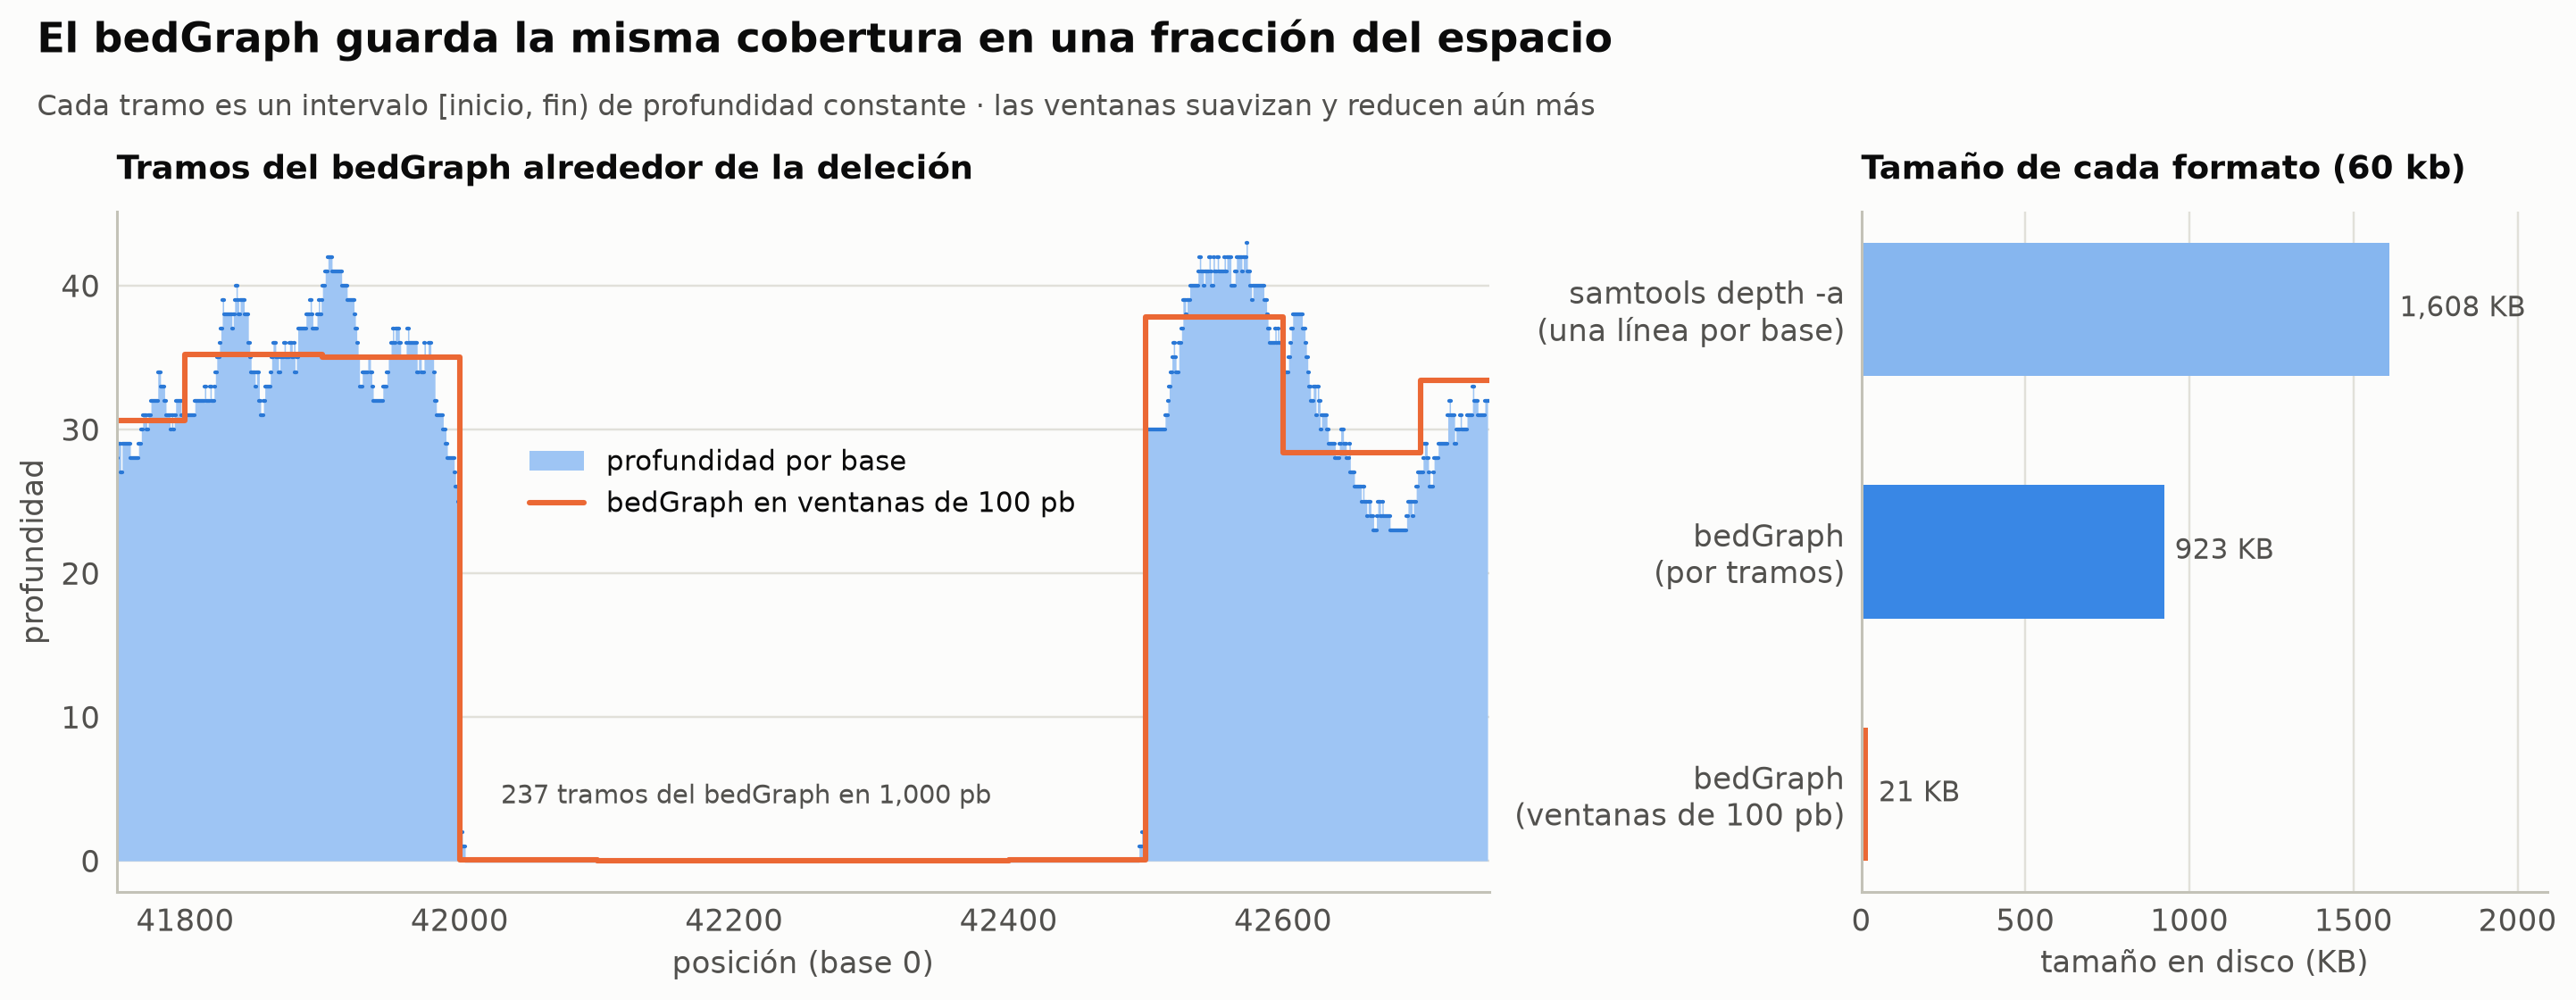

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw=dict(width_ratios=[2, 1]))
ax = axes[0]
z0, z1 = BIGDEL[0] - 250, BIGDEL[1] + 250
seg = bg[(bg["end"] > z0) & (bg["start"] < z1)]
ax.fill_between(np.arange(z0, z1), depth[z0:z1], step="post", color=ec.SEQ_BLUE[2], lw=0, label="profundidad por base")
for r in seg.itertuples():
    ax.plot([r.start, r.end], [r.value, r.value], color=ec.BLUE, lw=1.4)
sel_b = bgb[(bgb["end"] > z0) & (bgb["start"] < z1)]
ax.step(np.r_[sel_b["start"], sel_b["end"].iloc[-1]], np.r_[sel_b["value"], sel_b["value"].iloc[-1]], where="post", color=ec.ORANGE, lw=2, label="bedGraph en ventanas de 100 pb")
ax.set_xlim(z0, z1); ax.set_xlabel("posición (base 0)"); ax.set_ylabel("profundidad")
ax.legend(loc="center", bbox_to_anchor=(0.5, 0.6))
ax.text(z0 + 280, 4, f"{len(seg)} tramos del bedGraph en {z1 - z0:,} pb", fontsize=9.5, color=ec.INK_2)
ax.set_title("Tramos del bedGraph alrededor de la deleción", loc="left", fontsize=12)
ax = axes[1]
labs = ["samtools depth -a\n(una línea por base)", "bedGraph\n(por tramos)", "bedGraph\n(ventanas de 100 pb)"]
vals = [v / 1e3 for v in sizes.values()]
ax.barh(labs[::-1], vals[::-1], color=[ec.SEQ_BLUE[3], ec.SEQ_BLUE[6], ec.ORANGE][::-1], height=0.55)
for y, v in enumerate(vals[::-1]):
    ax.text(v + max(vals) * 0.02, y, f"{v:,.0f} KB", va="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, max(vals) * 1.3); ax.set_xlabel("tamaño en disco (KB)")
ax.yaxis.grid(False); ax.xaxis.grid(True, color=ec.GRID)
ax.set_title("Tamaño de cada formato (60 kb)", loc="left", fontsize=12)
ec.fig_title(fig, "El bedGraph guarda la misma cobertura en una fracción del espacio",
             "Cada tramo es un intervalo [inicio, fin) de profundidad constante · las ventanas suavizan y reducen aún más")
plt.show()

> 🔎 **Qué observamos.** Cada escalón de la línea azul es una línea del bedGraph: la profundidad cambia cada pocas
> bases (cada vez que empieza o termina una lectura), así que el ahorro frente a la tabla por base es moderado; dentro
> de la deleción, en cambio, un solo tramo de valor 0 cubre 500 pb. Las ventanas de 100 pb (naranja) pierden detalle
> pero reducen el archivo unas cien veces: es lo que se usa para mirar cromosomas enteros o comparar número de copias
> entre muestras. Para un genoma humano, la tabla por base ocupa decenas de GB; un bigWig, unos cientos de MB.

## 13. IGV de verdad, dentro del notebook

Todo lo que dibujamos a mano lo hace **IGV** (Robinson et al., 2011; Thorvaldsdóttir et al., 2013) de forma
interactiva y sobre genomas completos. Hay tres maneras de usarlo:

1. **IGV de escritorio** (Java; igv.org): descargue `ecoli_260kb.fa`, `ecoli_260kb.fa.fai`, `ecoli_sim.bam`,
   `ecoli_sim.bam.bai` y `ecoli_sim.bedgraph` desde el panel de archivos de Colab, abra la referencia con
   *Genomes → Load Genome from File* y el resto con *File → Load from File*.
2. **igv-webapp** (igv.org/app): la misma interfaz en el navegador, sin instalar nada.
3. **igv-notebook**: un paquete de Python que incrusta **igv.js** en la celda del notebook y lee los archivos locales
   del entorno de Colab. Es lo que hace la celda siguiente, que además marca las variantes implantadas como
   **regiones de interés** (ROI).

La celda sólo se ejecuta en Colab: en un Jupyter local igv-notebook también funciona, pero en la vista estática del
curso (GitHub) no se ve nada, porque igv.js necesita un navegador con JavaScript activo. Las figuras de las
secciones 6 y 8 son, en la práctica, nuestras "capturas".

Qué probar una vez abierto:

* Escriba `NC_000913.3_260kb:7,990-8,200` en la caja de búsqueda y compare con nuestra figura de la sección 6.
* Clic derecho sobre las lecturas → *Color alignments by → read strand* y vaya a la posición 15 001: el artefacto se
  delata solo.
* Clic derecho → *Group alignments by → pair orientation* y *Color by → insert size and pair orientation* en
  `NC_000913.3_260kb:41,500-52,500`.
* *View as pairs* y *Show soft-clipped bases* (Preferencias → Alignments) en los bordes de la deleción.
* Aleje el zoom sobre la repetición (19 163–19 932): las lecturas con MAPQ 0 aparecen transparentes, como en nuestra
  figura.

In [52]:
IGV_FILES = ["ecoli_260kb.fa", "ecoli_260kb.fa.fai", BAM, BAM + ".bai", "ecoli_sim.bedgraph"]
if IN_COLAB:
    try:
        import igv_notebook
    except ImportError:
        %pip install -q igv-notebook
        import igv_notebook
    from google.colab import output
    output.enable_custom_widget_manager()
    igv_notebook.init()
    browser = igv_notebook.Browser({
        "reference": {"id": CONTIG, "name": "E. coli K-12 (260–320 kb)",
                      "fastaPath": "ecoli_260kb.fa", "indexPath": "ecoli_260kb.fa.fai"},
        "locus": f"{CONTIG}:7,960-8,220",
    })
    browser.load_track({"name": "cobertura (bedGraph)", "path": "ecoli_sim.bedgraph", "format": "bedgraph",
                        "type": "wig", "color": ec.BLUE})
    browser.load_track({"name": "lecturas simuladas", "path": BAM, "indexPath": BAM + ".bai",
                        "format": "bam", "type": "alignment", "colorBy": "strand", "showSoftClips": True})
    browser.load_roi([{"chr": CONTIG, "start": int(p), "end": int(p) + 1, "name": n} for n, p in
                      [("SNP 1", SNP1), ("SNP 2", SNP2), ("inserción", INS_POS), ("artefacto", ART_POS)]]
                     + [{"chr": CONTIG, "start": a, "end": b, "name": n} for n, (a, b) in
                        [("deleción 500 pb", BIGDEL), ("duplicación 2 kb", DUP), ("deleción 3 pb", DEL3)]])
else:
    print("IGV embebido sólo se abre en Colab (o en un Jupyter local con igv-notebook instalado).")
    print("Archivos listos para abrir en IGV de escritorio o en igv.org/app:")
    for f in IGV_FILES:
        print(f"  {f:<24} {os.path.getsize(f) / 1e3:8.1f} KB")

IGV embebido sólo se abre en Colab (o en un Jupyter local con igv-notebook instalado).
Archivos listos para abrir en IGV de escritorio o en igv.org/app:
  ecoli_260kb.fa               61.1 KB
  ecoli_260kb.fa.fai            0.0 KB
  ecoli_sim.bam               805.4 KB
  ecoli_sim.bam.bai             0.2 KB
  ecoli_sim.bedgraph          923.2 KB


## 14. Buenas prácticas de inspección manual de variantes

La revisión visual de variantes candidatas es un paso rutinario en genómica clínica y del cáncer. Robinson et al.
(2017) describen cómo hacerla en IGV y Barnell et al. (2019) proponen un procedimiento estándar con etiquetas para
cada tipo de artefacto. Esta es una lista de verificación condensada:

| # | Pregunta | Señal de alarma |
|---|---|---|
| 1 | ¿Hay **profundidad** suficiente? | menos de ~10 lecturas: la AF es muy imprecisa |
| 2 | ¿La **AF** es coherente con el tipo de muestra? | 0.1 en una muestra germinal diploide |
| 3 | ¿Aparece en **ambas hebras**? | todas las alternativas en un solo color de hebra (Fisher $p$ pequeño) |
| 4 | ¿Aparece en **cualquier posición** de la lectura? | sólo en los últimos ciclos o sólo junto a recortes |
| 5 | ¿Las lecturas están **bien mapeadas**? | MAPQ bajo, región repetida, pares con mate lejano |
| 6 | ¿La **calidad de base** del alelo es buena? | bases alternativas con Q < 20 |
| 7 | ¿Las lecturas alternativas tienen **otros desajustes**? | muchas discordancias en las mismas lecturas: quizá vienen de otro locus (paralogo) |
| 8 | ¿Hay **indels o SV cerca**? | desajustes agrupados junto a un indel suelen ser un alineamiento defectuoso |
| 9 | ¿Son **duplicados** de PCR? | todas las alternativas empiezan y terminan en las mismas coordenadas |
| 10 | ¿Aparece en el **control** (normal, otras muestras)? | presente en muchas muestras: artefacto sistemático o polimorfismo |

Automatizamos las seis primeras para las candidatas que encontramos en la sección 7, más la inserción, y construimos
una "ficha" de semáforo: verde, amarillo o rojo para cada criterio.

In [53]:
def review(p, kind="snv"):
    ev = evidence(p, kind)
    alt = "ins" if kind == "ins" else ("del" if alt_allele[p] == "del" else alt_allele[p])
    a = ev[ev["allele"] == alt]
    t = strand_table(ev, alt)
    return dict(depth=len(ev), n_alt=len(a), af=len(a) / max(len(ev), 1),
                strand_p=fisher_exact(t.values)[1], min_strand=int(t["alt"].min()),
                cycle_alt=a["cycle"].median(), cycle_ref=ev.loc[ev["allele"] == "ref", "cycle"].median(),
                mapq=a["mapq"].mean(), bq=a["bq"].mean() if kind == "snv" and alt != "del" else np.nan)

cands = [(f"{p + 1:,} {ref[p]}>{alt_allele[p]}", p, "snv") for p in cand if alt_allele[p] != "del"]
cands.insert(1, (f"{DEL3[0] + 1:,} del TAT", DEL3[0], "snv"))
cands += [(f"{p + 1:,} ins {s}", p, "ins") for p, (s, n) in ins_cand]
card = pd.DataFrame({lab: review(p, k) for lab, p, k in cands}).T

def status(col, v, row):
    if col == "depth": return "good" if v >= 15 else ("warning" if v >= 8 else "critical")
    if col == "af": return "good" if v >= 0.3 else ("warning" if v >= 0.15 else "critical")
    if col == "strand": return "critical" if row["min_strand"] == 0 and row["n_alt"] >= 4 else ("warning" if row["strand_p"] < 0.05 else "good")
    if col == "cycle": return "good" if np.isnan(row["cycle_ref"]) or abs(row["cycle_alt"] - row["cycle_ref"]) < 30 else "warning"
    if col == "mapq": return "good" if v >= 30 else ("warning" if v >= 10 else "critical")
    if col == "bq": return "good" if np.isnan(v) or v >= 25 else ("warning" if v >= 15 else "critical")

checks = [("depth", "profundidad", lambda r: f"{r['depth']:.0f}"), ("af", "AF", lambda r: f"{r['af']:.2f}"),
          ("strand", "hebras (Fisher)", lambda r: f"p = {r['strand_p']:.2g}"),
          ("cycle", "ciclo alt vs ref", lambda r: f"{r['cycle_alt']:.0f} vs " + ("—" if np.isnan(r["cycle_ref"]) else f"{r['cycle_ref']:.0f}")),
          ("mapq", "MAPQ alt", lambda r: f"{r['mapq']:.0f}"),
          ("bq", "calidad base alt", lambda r: "—" if np.isnan(r["bq"]) else f"{r['bq']:.0f}")]
card.round(3)

,depth,n_alt,af,strand_p,min_strand,cycle_alt,cycle_ref,mapq,bq
"8,001 G>A",35.0,35.0,1.000,1.000,16.0,52.0,NaN,60.0,33.800
"8,181 del TAT",33.0,28.0,0.848,0.656,13.0,57.0,NaN,60.0,NaN
"8,092 A>G",40.0,20.0,0.500,0.341,9.0,30.0,52.0,60.0,36.300
"15,001 G>T",29.0,6.0,0.207,0.017,0.0,70.5,23.0,60.0,34.667
"8,121 ins ATTA",36.0,18.0,0.500,1.000,8.0,41.5,41.5,60.0,NaN


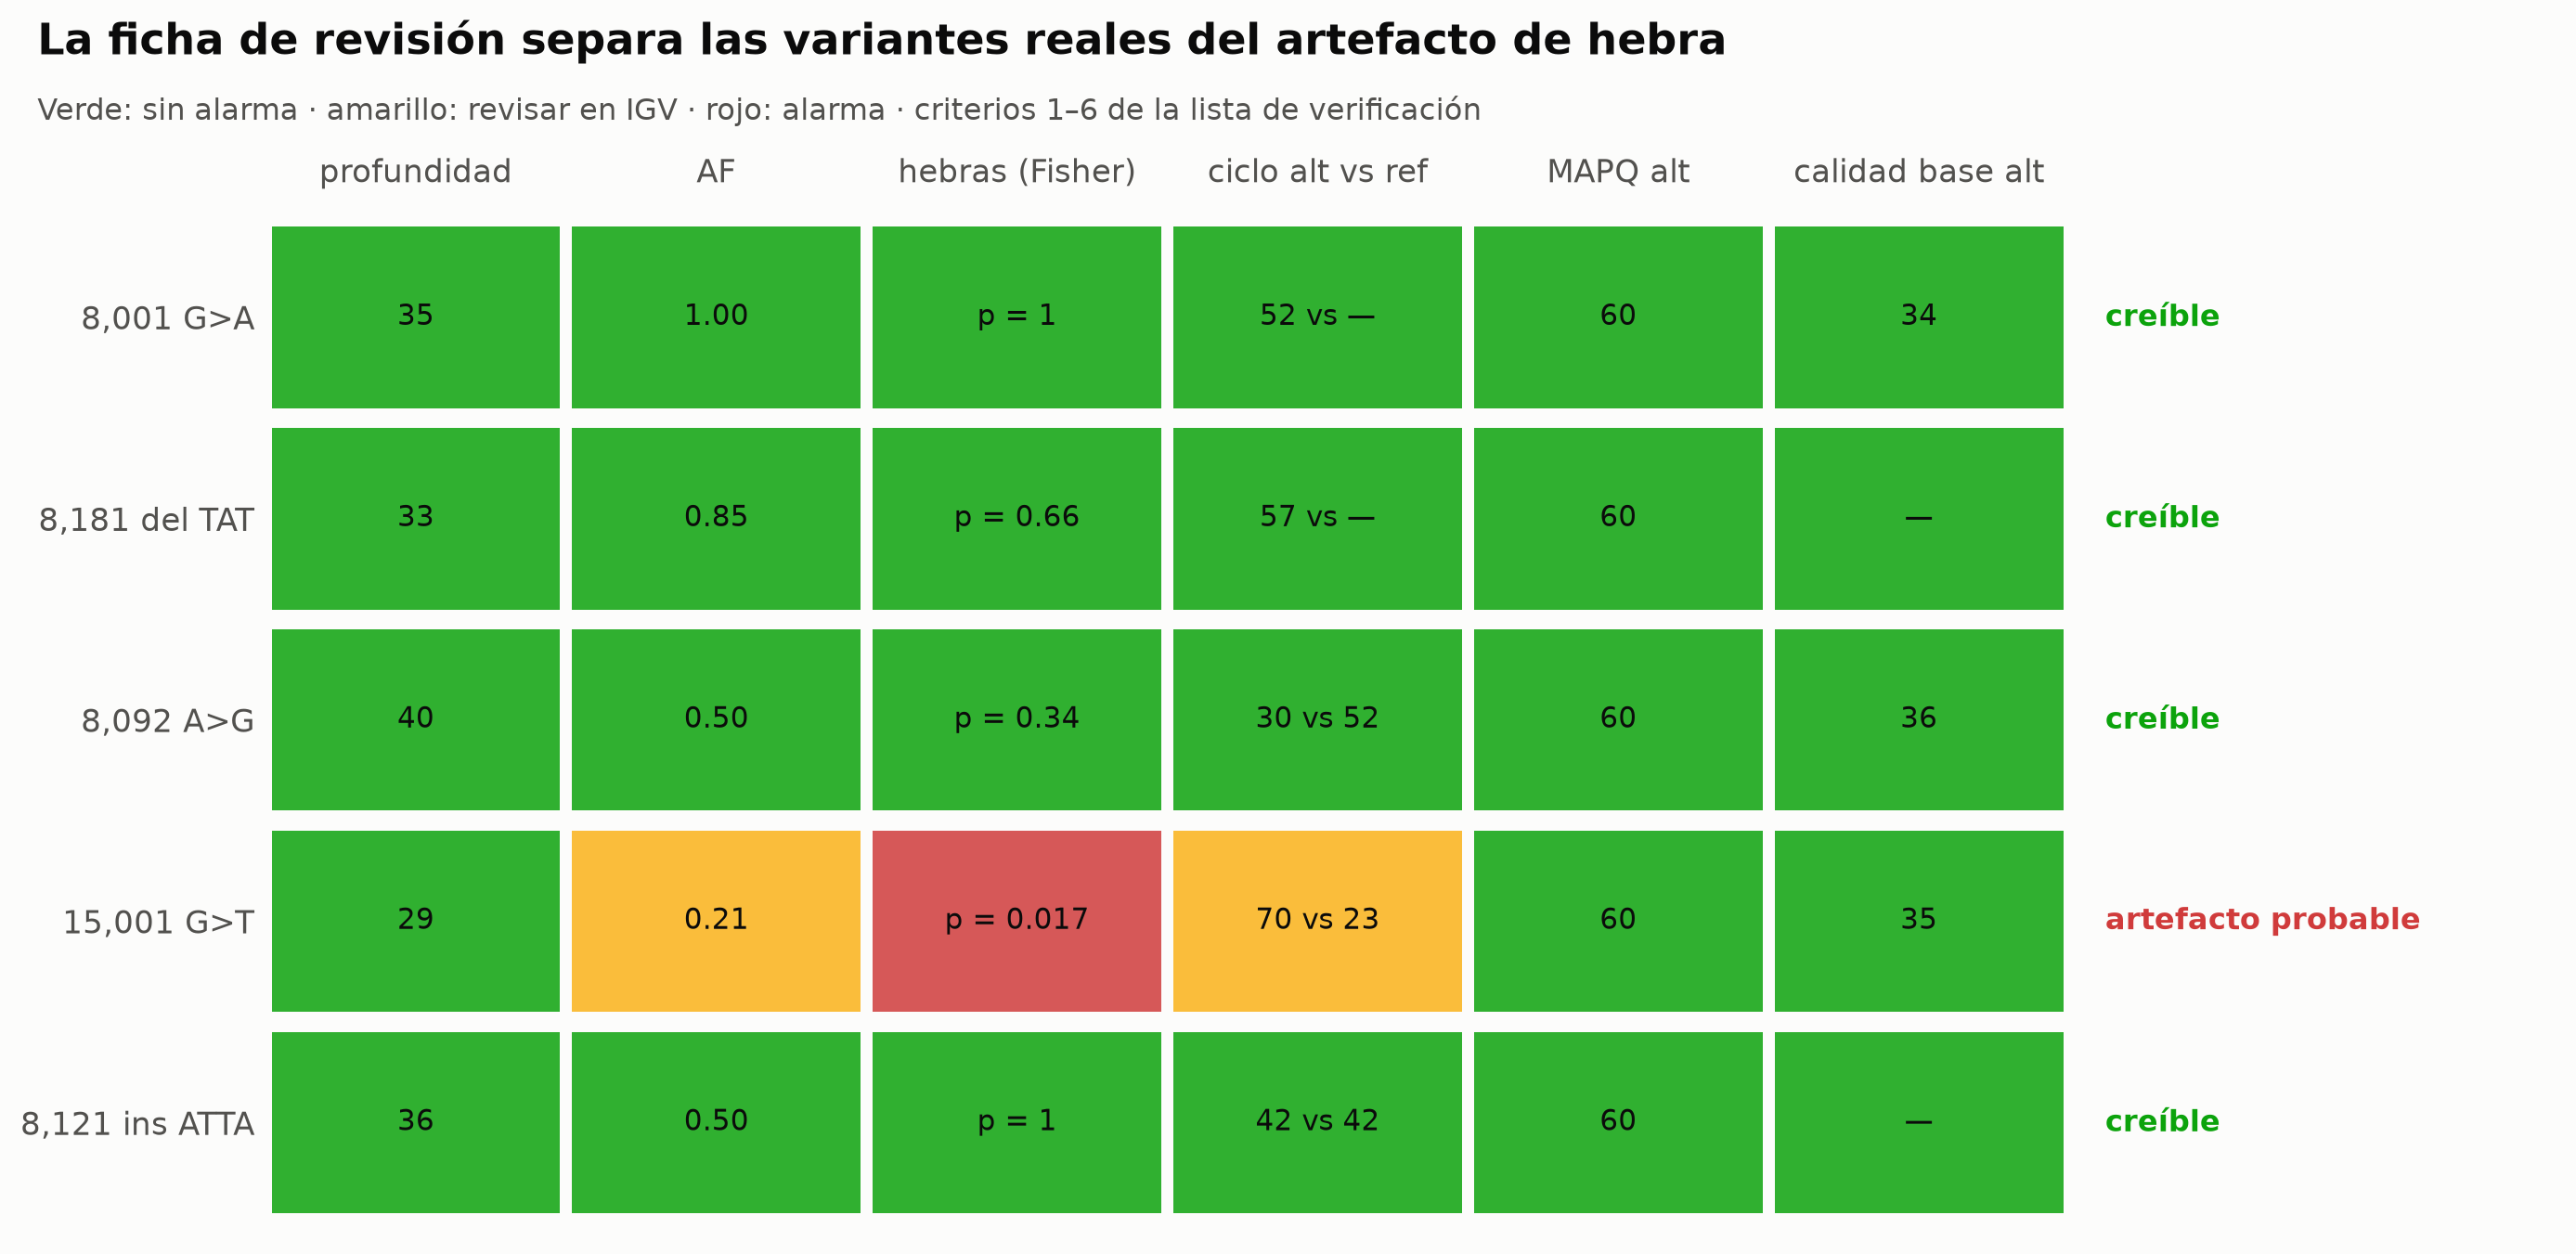

In [54]:
from matplotlib.colors import to_rgba
fig, ax = plt.subplots(figsize=(12.5, 0.75 * len(card) + 1.6))
code = {"good": 0, "warning": 1, "critical": 2}
for i, (lab, row) in enumerate(card.iterrows()):
    worst = "good"
    for j, (col, name, fmt) in enumerate(checks):
        v = row["depth"] if col == "depth" else row["af"] if col == "af" else row["mapq"] if col == "mapq" else row["bq"]
        st = status(col, v, row)
        worst = max(worst, st, key=lambda s: code[s])
        ax.add_patch(Rectangle((j, i), 0.96, 0.9, fc=to_rgba(ec.STATUS[st], 0.85), lw=0))
        ax.text(j + 0.48, i + 0.45, fmt(row), ha="center", va="center", fontsize=10, color=ec.INK)
    verdict = {"good": "creíble", "warning": "revisar", "critical": "artefacto probable"}[worst]
    ax.text(len(checks) + 0.1, i + 0.45, verdict, va="center", fontsize=10.5, fontweight="bold",
            color=ec.STATUS[worst] if worst != "warning" else ec.INK_2)
ax.set_xlim(0, len(checks) + 1.6); ax.set_ylim(len(card), -0.1)
ax.set_xticks(np.arange(len(checks)) + 0.48, [c[1] for c in checks]); ax.xaxis.tick_top()
ax.set_yticks(np.arange(len(card)) + 0.45, card.index)
ax.grid(False); [s.set_visible(False) for s in ax.spines.values()]
ec.fig_title(fig, "La ficha de revisión separa las variantes reales del artefacto de hebra",
         "Verde: sin alarma · amarillo: revisar en IGV · rojo: alarma · criterios 1–6 de la lista de verificación")
plt.show()

> 🔎 **Qué observamos.** Los SNPs, la deleción corta y la inserción pasan todos los criterios automáticos. La
> posición 15 001 falla en el criterio de hebra (ninguna alternativa en la hebra +) y en el de ciclo (las
> alternativas aparecen tarde en la lectura): exactamente el tipo de caso que hay que ir a ver en IGV antes de
> reportarlo. Una ficha así **no sustituye** a la mirada: los criterios 7–10 (desajustes extra, cercanía a indels o
> SV, duplicados, presencia en controles) requieren contexto. Pero ordena el trabajo y deja constancia de por qué se
> aceptó o rechazó cada variante.

> 💡 **Consejos prácticos para mirar en IGV.** Mire siempre con el mismo "protocolo": ventana de unos 100 pb
> centrada en la variante, lecturas coloreadas por hebra, ordenadas por base en la posición (*Sort alignments by
> base*), con los recortes visibles; después aleje el zoom a varios kb para ver cobertura y pares anómalos. Anote la
> decisión en una tabla (variante, decisión, motivo), como proponen Barnell et al. (2019).

## 15. Ejercicios

**Ejercicio 1 — Leer un pileup a mano.** Esta es una línea de `samtools mpileup`:

```
chr1  1500  C  13  ..,,T.t,$^]T.-2AG,,*
```

(a) ¿Cuántas lecturas dicen C, cuántas T y cuántas tienen la base borrada? (b) ¿Cuántas lecturas terminan y
cuántas empiezan en esta posición? (c) ¿Qué indel sigue a esta posición y en cuántas lecturas? (d) Calcule la AF de
la T y diga si hay sesgo de hebra evidente. Compruebe su respuesta con código.

**Ejercicio 2 — Empaquetado y profundidad.** Para la ventana 49 600–50 600 (que contiene el borde de la
duplicación), calcule el número de filas del empaquetado voraz con margen 2 y la profundidad máxima con el mismo
margen. ¿Coinciden? Repita con margen 0 y con margen 20. ¿Por qué aumentan las filas con el margen?

**Ejercicio 3 — Filtrar por MAPQ.** Reconstruya la matriz de conteos usando sólo alineamientos con MAPQ ≥ 1 y
dibuje la profundidad entre 18 500 y 32 000. ¿Qué ocurre dentro de las dos copias de la repetición? ¿Qué pasaría con
una variante verdadera situada en una de las copias?

**Ejercicio 4 — Una deleción heterocigota.** Sin simular de nuevo, razone y luego compruebe con una simulación
pequeña (reutilice el código de la sección 2 con 3 000 pares sobre los primeros 20 kb): si la deleción de 500 pb sólo
estuviera en el haplotipo A, ¿a cuánto caería la profundidad dentro de ella? ¿Cambiaría el tamaño estimado a partir
de los pares discordantes? ¿Y el número de pares discordantes?

In [55]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
import re
line = "..,,T.t,$^]T.-2AG,,*"
clean = re.sub(r"\^.", "", line).replace("$", "")                    # quitar marcas de inicio y fin
indels = re.findall(r"[+-](\d+)", clean)
for m in re.finditer(r"([+-])(\d+)", clean):                            # quitar las secuencias de los indels
    clean = clean.replace(m.group(0) + clean[m.end():m.end() + int(m.group(2))], "", 1)
n_ref = clean.count(".") + clean.count(",")
n_t = clean.count("T") + clean.count("t")
n_del = clean.count("*")
print(f"(a) C (ref): {n_ref} · T: {n_t} · borradas: {n_del} · total = {n_ref + n_t + n_del} (la línea dice 13)")
print(f"(b) terminan: {line.count('$')} · empiezan: {line.count('^')}")
print(f"(c) indels tras esta posición: {len(indels)} → una deleción de 2 pb (AG) en una lectura de hebra +")
print(f"(d) AF(T) = {n_t}/{n_ref + n_t + n_del} = {n_t / (n_ref + n_t + n_del):.2f}; "
      f"T en hebra +: {clean.count('T')}, en hebra −: {clean.count('t')} → sin sesgo evidente")

(a) C (ref): 9 · T: 3 · borradas: 1 · total = 13 (la línea dice 13)
(b) terminan: 1 · empiezan: 1
(c) indels tras esta posición: 1 → una deleción de 2 pb (AG) en una lectura de hebra +
(d) AF(T) = 3/13 = 0.23; T en hebra +: 2, en hebra −: 1 → sin sesgo evidente


In [56]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
w = mapped[(mapped["pos"] < 50_600) & (mapped["end"] > 49_600)]
for g in (0, 2, 20):
    rows_g = pack_rows(w["pos"], w["end"], gap=g)
    print(f"margen {g:>2}: filas = {rows_g.max() + 1} · D_max = {max_depth(w['pos'].to_numpy(), w['end'].to_numpy(), gap=g)}")
print("Coinciden siempre: con margen g cada lectura 'ocupa' g bases más, y más lecturas se solapan a la vez.")

margen  0: filas = 96 · D_max = 96
margen  2: filas = 96 · D_max = 96
margen 20: filas = 112 · D_max = 112
Coinciden siempre: con margen g cada lectura 'ocupa' g bases más, y más lecturas se solapan a la vez.


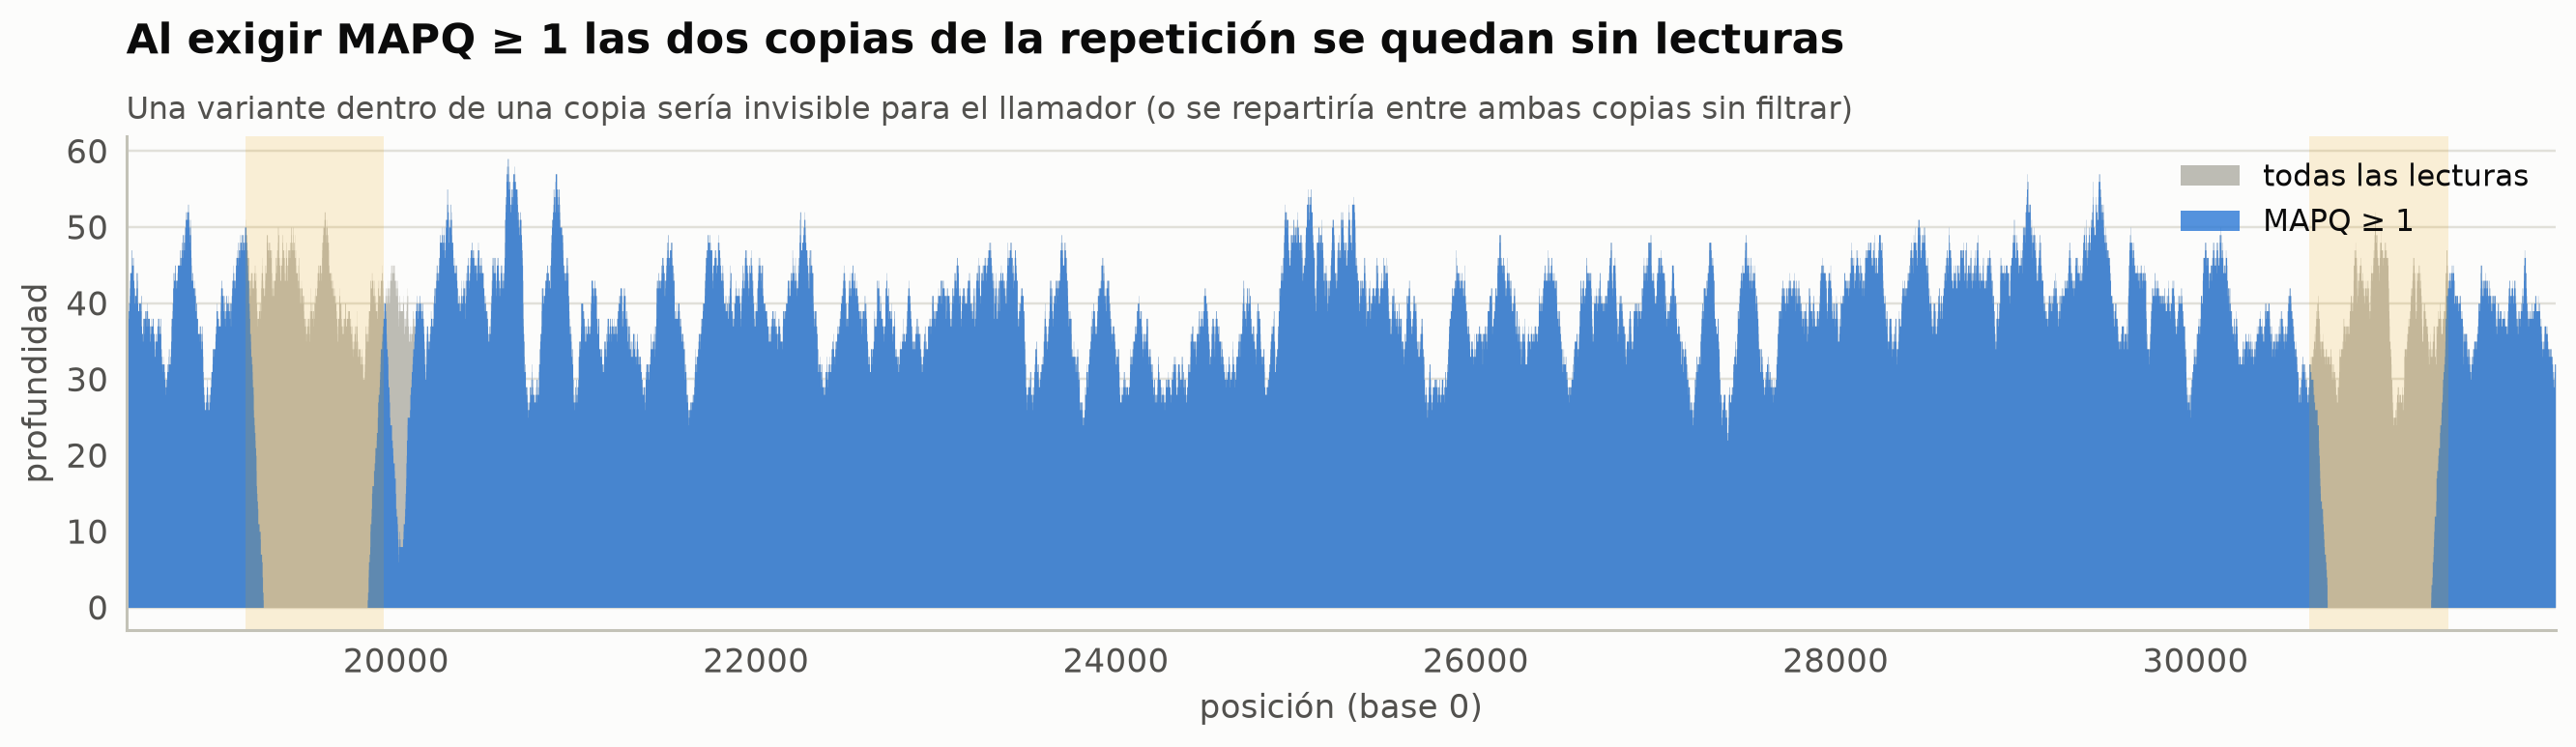

In [57]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
c_q, _ = build_pileup(mapped[mapped["mapq"] >= 1])
d_q = c_q.sum(0)[:, :4].sum(1)
fig, ax = plt.subplots(figsize=(12, 3.4))
xs = np.arange(18_500, 32_000)
ax.fill_between(xs, depth[xs], step="post", color="#bdbcb4", lw=0, label="todas las lecturas")
ax.fill_between(xs, d_q[xs], step="post", color=ec.BLUE, lw=0, alpha=0.8, label="MAPQ ≥ 1")
for a, b in REPEAT:
    ax.axvspan(a, b, color=ec.YELLOW, alpha=0.15, lw=0)
ax.set_xlim(xs[0], xs[-1]); ax.set_xlabel("posición (base 0)"); ax.set_ylabel("profundidad")
ax.legend(loc="upper right")
ec.title(ax, "Al exigir MAPQ ≥ 1 las dos copias de la repetición se quedan sin lecturas",
         "Una variante dentro de una copia sería invisible para el llamador (o se repartiría entre ambas copias sin filtrar)")
plt.show()

In [58]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
print("Razonamiento: con la deleción sólo en un haplotipo, la mitad de las moléculas conserva esas 500 pb →")
print("la profundidad dentro cae a ~la mitad de la de fuera. El tamaño estimado por pares no cambia (cada par discordante")
print("sigue cruzando 500 pb), pero hay la mitad de pares discordantes y de lecturas partidas.")
sub = ref[:20_000]
hapA_s = sub[:12_000] + sub[12_500:]; hapB_s = sub
d_het = np.zeros(20_000); n_disc = []
rng_e = np.random.default_rng(4)
for i in range(3_000):
    hap = hapA_s if i % 2 == 0 else hapB_s
    flen = int(max(150, round(rng_e.normal(INSERT_MEAN, INSERT_SD))))
    s = int(rng_e.integers(0, len(hap) - flen))
    # proyectar el fragmento a coordenadas de referencia
    a, b = s, s + flen
    if hap is hapA_s:
        a, b = (a if a < 12_000 else a + 500), (b if b <= 12_000 else b + 500)
        if s < 12_000 < s + flen:
            n_disc.append(b - a)
    for x0 in (a, b - READ_LEN):
        seg = np.arange(x0, x0 + READ_LEN)
        seg = seg[(seg < 20_000)]
        d_het[seg] += 1
print(f"Profundidad dentro: {d_het[12_000:12_500].mean():.1f}× · fuera: {np.median(d_het):.1f}× · "
      f"pares que cruzan: {len(n_disc)} con TLEN medio {np.mean(n_disc):.0f} pb → Ŵ ≈ {np.mean(n_disc) - INSERT_MEAN:.0f} pb")

Razonamiento: con la deleción sólo en un haplotipo, la mitad de las moléculas conserva esas 500 pb →
la profundidad dentro cae a ~la mitad de la de fuera. El tamaño estimado por pares no cambia (cada par discordante
sigue cruzando 500 pb), pero hay la mitad de pares discordantes y de lecturas partidas.
Profundidad dentro: 16.4× · fuera: 30.0× · pares que cruzan: 25 con TLEN medio 857 pb → Ŵ ≈ 507 pb


## 📌 Resumen

* El **pileup** es la columna de alelos que las lecturas alineadas aportan a cada posición; `samtools mpileup` lo
  escribe con un código compacto (`.` `,` letras, `^` + MAPQ, `$`, `+nSEQ`, `-nSEQ`, `*`).
* Para visualizar hace falta un **BAM ordenado e indexado** (y la referencia con su `.fai`).
* El **empaquetado voraz** coloca cada lectura en la primera fila libre y usa exactamente $D_{\max}$ filas: la altura
  de la pila es la profundidad.
* Una vista estilo IGV muestra sólo lo que difiere de la referencia: bases de color, inserciones moradas, deleciones
  como líneas, recortes, lecturas transparentes con MAPQ 0 y pares coloreados por inserto y orientación.
* La **frecuencia alélica** $n_{\text{alt}}/D$ separa homocigotos (≈ 1), heterocigotos (≈ 0.5) y errores (≈ 1/D);
  la binomial cuantifica cuánto puede variar por azar.
* Los **artefactos** se delatan por sesgo de **hebra**, de **posición en la lectura**, MAPQ o calidad de base bajas.
* Las **variantes estructurales** se reconocen por la combinación de **profundidad** (caída o subida), **pares
  discordantes** (inserto grande en deleciones, orientación RF en duplicaciones en tándem) y **lecturas partidas**
  (puntos de ruptura exactos). Las repeticiones imitan algunas de estas señales sin ser variantes.
* La **profundidad por base** $c(x)$ cuenta sólo bases alineadas (bloques `M`/`=`/`X`) de los alineamientos que
  superan los filtros; el **arreglo de diferencias** de `mosdepth` ($+1$ al inicio y $-1$ al final de cada bloque, y una
  suma acumulada) la calcula en $O(N + G)$, sin importar la profundidad.
* La pista $\ell_W = \log_2(\bar c_W / \operatorname{mediana}_V \bar c_V)$ lee el número de copias: $0$ normal, $-1$
  deleción heterocigota, $+0.58$ duplicación heterocigota, $-\infty$ homocigota; antes hay que **corregir el GC** y
  **enmascarar** lo no mapeable, o una repetición se confunde con una deleción.
* Con Poisson, $z_{\text{het}} = \sqrt\lambda/2$ y $W_{\min}^{\text{het}} = 4z^{\star2}L/\bar c$: 500 pb (het.) y
  125 pb (hom.) a $30\times$ con $z^\star = 5$; en $W_{\min}$ se detecta la mitad de las deleciones. Con sobredispersión
  binomial negativa la señal tiene un techo $\sqrt r/2$: reducir sesgos rinde más que añadir lecturas.
* La cobertura se exporta como tabla por base (`samtools depth`, 1-based), **bedGraph** (tramos, 0-based semiabiertos)
  o **bigWig** (binario indexado).
* IGV (escritorio, web o `igv-notebook`) es la herramienta estándar para la **inspección manual**, que conviene hacer
  con una lista de verificación y dejando constancia de cada decisión.

## 📚 Para profundizar

* Robinson, J. T., Thorvaldsdóttir, H., Winckler, W., Guttman, M., Lander, E. S., Getz, G. & Mesirov, J. P. (2011).
  Integrative genomics viewer. *Nature Biotechnology* 29(1): 24–26.
* Thorvaldsdóttir, H., Robinson, J. T. & Mesirov, J. P. (2013). Integrative Genomics Viewer (IGV): high-performance
  genomics data visualization and exploration. *Briefings in Bioinformatics* 14(2): 178–192.
* Robinson, J. T., Thorvaldsdóttir, H., Wenger, A. M., Zehir, A. & Mesirov, J. P. (2017). Variant review with the
  Integrative Genomics Viewer. *Cancer Research* 77(21): e31–e34.
* Barnell, E. K. et al. (2019). Standard operating procedure for somatic variant refinement of sequencing data with
  paired tumor and normal samples. *Genetics in Medicine* 21(4): 972–981.
* Li, H., Handsaker, B., Wysoker, A., Fennell, T., Ruan, J., Homer, N., Marth, G., Abecasis, G., Durbin, R. & 1000
  Genome Project Data Processing Subgroup (2009). The Sequence Alignment/Map format and SAMtools. *Bioinformatics*
  25(16): 2078–2079.
* Li, H. (2018). Minimap2: pairwise alignment for nucleotide sequences. *Bioinformatics* 34(18): 3094–3100.
* Quinlan, A. R. & Hall, I. M. (2010). BEDTools: a flexible suite of utilities for comparing genomic features.
  *Bioinformatics* 26(6): 841–842.
* Li, H., Ruan, J. & Durbin, R. (2008). Mapping short DNA sequencing reads and calling variants using mapping quality
  scores. *Genome Research* 18(11): 1851–1858.
* Abyzov, A., Urban, A. E., Snyder, M. & Gerstein, M. (2011). CNVnator: an approach to discover, genotype, and
  characterize typical and atypical CNVs from family and population genome sequencing. *Genome Research* 21(6): 974–984.
* Ramírez, F., Ryan, D. P., Grüning, B., Bhardwaj, V., Kilpert, F., Richter, A. S., Heyne, S., Dündar, F. & Manke, T.
  (2016). deepTools2: a next generation web server for deep-sequencing data analysis. *Nucleic Acids Research* 44(W1):
  W160–W165.
* Kent, W. J., Zweig, A. S., Barber, G., Hinrichs, A. S. & Karolchik, D. (2010). BigWig and BigBed: enabling browsing
  of large distributed datasets. *Bioinformatics* 26(17): 2204–2207.
* Pedersen, B. S. & Quinlan, A. R. (2018). Mosdepth: quick coverage calculation for genomes and exomes.
  *Bioinformatics* 34(5): 867–868.
* Costello, M. et al. (2013). Discovery and characterization of artifactual mutations in deep coverage targeted
  capture sequencing data due to oxidative DNA damage during sample preparation. *Nucleic Acids Research* 41(6): e67.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)